# Semantic Memory System Knowledge Graph
>

In [ ]:
#| default_exp memory

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| default_exp memory
#| export
import json
from pyld import jsonld
import httpx
from rdflib import Graph, Dataset, URIRef, Literal, Namespace
from rdflib.namespace import RDF, RDFS, OWL
from datetime import datetime
from enum import Enum
from typing import List, Literal, Optional, Dict, Any
from pydantic import BaseModel, Field
from fastcore.basics import patch
from dataclasses import dataclass, field
from claudette import Chat, toolloop, models
import time
import copy
from pathlib import Path
import types
import pickle
from contextlib import contextmanager, nullcontext

In [ ]:
from cogitarelink.vocabtools import *

## Design Principles

### Core Philosophy

The `SemanticMemory` module is designed to provide a semantically rich, self-organizing knowledge store that leverages the full power of JSON-LD 1.1 for intelligent data representation and LLM integration. It follows these key principles:

### Knowledge as a Connected Graph

- **Everything is a Graph**: All knowledge is stored in a connected graph structure, making relationships first-class citizens
- **Named Graphs for Provenance**: Information sources are tracked through named graphs, enabling trust and attribution
- **Cross-Graph Navigation**: Knowledge can be traversed across graph boundaries while maintaining context

### Vocabulary-Aware Processing

- **Automatic Vocabulary Detection**: The system recognizes and adapts to different vocabularies automatically
- **Vocabulary Harmonization**: Conflicting vocabularies are handled gracefully through intelligent strategies
- **Context Preservation**: Original context information is preserved to maintain semantic precision

### LLM Context Integration

- **Context Window Optimization**: Knowledge is formatted to maximize information density in LLM context windows
- **Tool-Based Navigation**: LLMs can use tools to navigate, query, and manipulate the semantic graph
- **Progressive Loading**: Complex knowledge structures can be loaded incrementally as needed
- **Adaptive Serialization**: JSON-LD is serialized based on LLM needs and context window constraints

### Containers for Intelligent Organization

- **Strategic Information Grouping**: JSON-LD 1.1 containers enable natural organization of related entities
- **Multi-dimensional Access**: Data can be accessed by ID, type, language, or custom indices
- **Efficient Pattern Matching**: Container structures facilitate efficient matching of complex patterns

### LLM-Optimized Knowledge Representation

- **Semantic Compression**: Complex structures are compressed while preserving semantic meaning
- **Vocabulary-Aware Formatting**: Data is presented using the most appropriate vocabulary for the task
- **Relationship Highlighting**: Critical relationships are made explicit for LLM reasoning
- **Context-Sensitive Views**: Different views of the same knowledge can be generated based on task needs

### Agent-LLM Collaboration

- **Follow-Your-Nose Navigation**: LLMs can explore the knowledge graph step by step via tool calls
- **In-Context Reasoning**: Semantic structures enable in-context reasoning about complex relationships
- **Tool-Augmented Retrieval**: LLMs can use tools to retrieve and manipulate semantic data
- **Memory Persistence**: Knowledge can flow between context windows through semantic memory

By adhering to these principles, the `SemanticMemory` module serves as an intelligent bridge between raw data and LLM reasoning, enabling efficient knowledge transfer to and from LLM context windows while preserving semantic richness and enabling sophisticated knowledge navigation through tool use.

## JSON-LD 1.1 context enhancements.

## New Add Functions to deal with JSON-LD 1.1

Fixes and updates

## Add function updates
When a semantic agent uses the `add` function, it's typically:
1. Storing knowledge for later retrieval
2. Building up a knowledge graph incrementally
3. Potentially needing to reference what was just added

The semantic memory object should indeed provide:
- A clear index structure for looking up entities
- Metadata about what's stored in the system
- Efficient access patterns for different query types

In this context, the return value of `add` serves two primary purposes:
1. Confirmation that entities were successfully added
2. References to those entities for potential immediate use

Looking at it this way, the `add` function should return something that enables the agent to:
1. Understand what was added (entity types, ids, etc.)
2. Easily reference what was just added in subsequent operations
3. Have a clear understanding of the structure regardless of whether one or multiple entities were added

A consistent return type (always a list) provides the simplest mental model, but we could also make it more informative by returning a structured response like:

```python
{
    "added": [entity_ids],
    "count": len(entity_ids),
    "types": {entity_id: entity_type},
    "graphs": {entity_id: graph_id}
}
```

This would give the agent rich metadata about what was added while maintaining consistency.

**AI Prompt**

Yeah, I'm sort of wondering if we want a vocabulary tracker. Let's not write any code but deeply think through what would need to change and what that would mean for complexity. Let's do a thorough analysis based on the semantic memory that's in your context and the functions we've just written.

**AI Response**

# Deep Analysis of Vocabulary Tracking in SemanticMemory

Looking at the current implementation and our new functions, let me analyze what a vocabulary tracker would mean for the system's complexity and architecture.

## Current Vocabulary Handling Flow

Examining the code, vocabularies currently flow through:

1. **Detection**: Using `detect_vocabularies_in_context` from contexts
2. **Registration**: In `_register_context` with vocabulary metadata
3. **Entity Processing**: During `_process_entity` and `_process_graph`
4. **Indexing**: Through `_track_vocabulary_usage` into `indices["by_vocabulary"]`
5. **Querying**: Via `query_by_vocabulary` and related methods
6. **Output**: In the metadata returned from `add`

## Key Architecture Considerations

### 1. Crossing Multiple Abstraction Layers

Vocabulary information passes through several distinct components:
- Context processing
- Entity normalization
- JSON-LD expansion
- Indexing
- Graph processing

This creates multiple places where vocabulary tracking could break down.

### 2. State Transformation

Vocabularies are represented differently across these layers:
- As URIs in context objects
- As vocabulary names after detection
- As indexed sets in the indices
- As metadata in result structures

### 3. Integration Points

Each method has its own vocabulary handling concerns:
- `_register_context`: Associates vocabularies with contexts
- `_process_entity`: Extracts vocabularies during expansion
- `add`: Collects vocabulary information for results
- `prepare_for_llm`: Uses vocabulary information for formatting

## Complexity Analysis of Vocabulary Tracking

Adding robust vocabulary tracking would involve:

### 1. Additional State Management

- Need to track vocabulary information across method boundaries
- Need consistent representation of vocabulary state
- Need to track transformations to vocabulary information

### 2. Cross-Cutting Concern

- Vocabulary tracking would touch many methods
- Hard to localize the tracking logic
- Would create dependencies between components

### 3. Performance Implications

- Additional tracking data would increase memory usage
- Tracking logic would add overhead to core operations
- Storing detailed tracking information could be expensive

### 4. Maintenance Burden

- Any change to vocabulary handling would need to update tracking
- Tracking logic could obscure the main functionality
- More code paths to test and maintain

## Alternative Approaches

1. **Minimal Diagnostic Approach**: Add focused debugging at known trouble spots rather than comprehensive tracking

2. **Functional Testing Approach**: Create test cases that verify vocabulary flow at boundaries rather than tracking internally

3. **Explicit Vocabulary Context**: Make vocabulary handling more explicit in the API rather than tracking it implicitly

4. **Event-Based System**: Use a lightweight event system for vocabulary changes that can be turned on/off

5. **Simplified Model**: Redesign how vocabularies are handled to make tracking unnecessary

## Recommendation

Based on this analysis, adding a full vocabulary tracker would significantly increase complexity. A more targeted approach focused on specific trouble spots would maintain the system's clarity while solving immediate issues.

Would you like me to elaborate on any of these aspects, or suggest a specific targeted approach?

**AI Prompt**

OK, so let's think this through from the point of view of RDF datasets, which are graph-based, and also consider importing of Turtle and non-JSON-LD structured data.

**AI Response**

# RDF Datasets and Non-JSON-LD Data Integration

Looking at this through the lens of RDF datasets and non-JSON-LD data integration, we need to consider some additional dimensions:

## RDF Dataset Perspective

RDF datasets fundamentally organize information as:
- Named graphs containing triples
- Each graph has its own context and provenance
- Cross-graph relationships are explicit

This maps to our SemanticMemory structure, but introduces new considerations:

### Graph-Based Organization

1. **Graph-First Processing**: In pure RDF systems, the graph is the primary unit of organization, not the entity
2. **Context Per Graph**: Each named graph might use different vocabularies
3. **Quad-Based Storage**: RDF datasets use quads (subject, predicate, object, graph) as the atomic unit

### Vocabulary Handling in RDF

1. **Namespace Declarations**: RDF formats like Turtle use explicit prefix declarations
2. **Vocabulary Mixing**: Different parts of a graph can use different vocabularies without scoped contexts
3. **Implicit Semantics**: Some vocabularies (like RDF, RDFS, OWL) have implicit semantics that affect interpretation

## Non-JSON-LD Import Considerations

When importing from formats like Turtle, N-Triples, or RDF/XML:

### Format Conversion Challenges

1. **Context Creation**: We'd need to synthesize JSON-LD contexts from prefix declarations
2. **Default Vocabulary**: Need to determine a default vocabulary for compaction
3. **Blank Node Handling**: Different approaches to blank nodes across formats

### Vocabulary Detection Differences

1. **Explicit vs. Implicit**: JSON-LD uses explicit contexts, while other formats use prefixes
2. **URI Patterns**: May need to infer vocabularies from URI patterns, not just declarations
3. **Mixed Vocabulary Inference**: Need to determine dominant vocabularies for context creation

## Architectural Implications

Considering these aspects, our architecture would need:

### 1. Format-Agnostic Core

- Abstract vocabulary handling from specific format details
- Normalize vocabulary information regardless of source format
- Maintain graph structure throughout processing

### 2. Graph-Centric Processing

- Process and track vocabularies at the graph level first
- Associate vocabularies with specific graphs
- Handle cross-graph vocabulary differences explicitly

### 3. Vocabulary Resolution Strategy

- Define clear rules for resolving vocabulary conflicts
- Prioritize vocabularies based on usage patterns
- Handle vocabulary mixing within a single graph

### 4. Import/Export Pipeline

- Convert between formats while preserving vocabulary information
- Generate appropriate contexts during format conversion
- Maintain vocabulary associations during transformations

## Practical Implementation Approach

Given these considerations, we might:

1. **Enhance Graph Structure**: Make the named graph the primary organizational unit for vocabulary tracking

2. **Add Graph-Level Vocabulary Association**: Track which vocabularies are used in which graphs

3. **Implement Format-Specific Adapters**: Create adapters for Turtle, N-Triples, etc. that handle vocabulary extraction

4. **Create Vocabulary Resolution Rules**: Define clear rules for resolving vocabulary conflicts

This approach would maintain the entity-centric model for API usability while enhancing the underlying graph-based structure for vocabulary handling.

Would you like me to delve deeper into any specific aspect of this approach?

## Context Manager Implimentation

In [ ]:
#| export
class ContextProcessor:
    "Manages JSON-LD contexts with enhanced JSON-LD 1.1 support"
    def __init__(self, parent=None):
        self.parent = parent
        self.registry = {}  # Store registered contexts
        self.cache = {}     # Quick lookup cache

In [ ]:
#| export
@patch
def check_protection_conflicts(self:ContextProcessor, context1, context2):
    """Check if merging contexts would violate protection rules
    
    Args:
        context1: First context (could be protected)
        context2: Second context (might conflict with protected terms)
        
    Returns:
        Boolean indicating if there's a protection conflict
    """
    # Get protected terms from first context
    protected = self.protected_terms(context1)
    if not protected:
        return False  # No protected terms, no conflicts
    
    # Check if any protected terms would be overridden
    for term in protected:
        if isinstance(context2, dict) and term in context2:
            # Term exists in both contexts - check if definitions differ
            if context1.get(term) != context2.get(term):
                self._debug(f"Protection conflict: term '{term}' is protected in context1", level=1)
                return True
    
    return False  # No conflicts found

In [ ]:
#| export
@patch
def process_context_array(self:ContextProcessor, context_array):
    """Process an array of contexts while respecting @protected terms
    
    Args:
        context_array: Array of contexts to process
        
    Returns:
        Properly merged context respecting protection
    """
    if not isinstance(context_array, list):
        return context_array
    
    # Process each context in the array first
    processed_contexts = []
    for ctx in context_array:
        # Handle imports in each context
        if isinstance(ctx, dict) and "@import" in ctx:
            processed_ctx = self.process_imports(ctx)
        else:
            processed_ctx = ctx
        processed_contexts.append(processed_ctx)
    
    # Start with the first context
    if not processed_contexts:
        return {}
    
    result = copy.deepcopy(processed_contexts[0])
    protected_terms = self.protected_terms(result)
    
    # Merge subsequent contexts, respecting protection
    for ctx in processed_contexts[1:]:
        # Skip if there's nothing to merge
        if not isinstance(ctx, dict):
            continue
            
        # Check each term in the new context
        for term, definition in ctx.items():
            # Skip keywords
            if term.startswith('@'):
                # But copy over non-protected keywords
                if term not in result:
                    result[term] = definition
                continue
                
            # Check if the term is protected in the result
            if term in protected_terms:
                # Skip this term - it's protected and can't be overridden
                self._debug(f"Skipping protected term: {term}", level=2)
                continue
                
            # Term is not protected, so we can merge it
            result[term] = definition
        
        # Update protected terms for the next merge
        protected_terms.update(self.protected_terms(ctx))
    
    return result

In [ ]:
#| export
@patch
def process_imports(self:ContextProcessor, context):
    """Process @import in a context and completely resolve imported contexts
    
    Args:
        context: The context with potential @import directive
        
    Returns:
        Fully resolved context with imports processed
    """
    if not isinstance(context, dict):
        return context
    
    # If no @import, just return the context as is
    if '@import' not in context:
        return context
    
    import_url = context['@import']
    # Remove @import to avoid circular imports
    context_without_import = {k: v for k, v in context.items() if k != '@import'}
    
    try:
        self._debug(f"Loading import from {import_url}", level=2)
        
        # Load the imported context
        from pyld import jsonld
        loader = jsonld.get_document_loader()
        remote_doc = loader(import_url)
        
        if not remote_doc or "document" not in remote_doc:
            self._debug(f"Failed to load import from {import_url}", level=2)
            return context_without_import
            
        # Extract the context from the document
        imported_doc = remote_doc["document"]
        
        # Handle both direct context and @context wrapper
        if "@context" in imported_doc:
            imported = imported_doc["@context"]
        else:
            imported = imported_doc
            
        # Create result context
        result = {}
        
        # First, copy all items from the imported context
        if isinstance(imported, dict):
            for key, value in imported.items():
                result[key] = value
                if key.startswith('@'):
                    self._debug(f"Preserved directive from import: {key}={value}", level=2)
        
        # Then, apply overrides from the wrapper context
        for key, value in context_without_import.items():
            # Skip duplicate @version with same value
            if key == '@version' and key in result and value == result[key]:
                self._debug(f"Skipping duplicate @version directive", level=2)
                continue
                
            # Check for protected term conflicts
            if key in result and isinstance(result[key], dict) and result[key].get('@protected'):
                self._debug(f"Protected term conflict: {key}", level=2)
                # Keep the protected definition
                continue
                
            # Otherwise override the term
            result[key] = value
        
        # CRITICAL: Make sure @import is completely removed
        if '@import' in result:
            del result['@import']
            
        return result
        
    except Exception as e:
        self._debug(f"Error processing @import {import_url}: {e}", level=1)
        return context_without_import

In [ ]:
#| export
@patch
def propagates(self:ContextProcessor, context):
    "Determine if a context propagates (JSON-LD 1.1 feature)"
    if isinstance(context, dict) and "@propagate" in context:
        return context["@propagate"] is not False
    return True

In [ ]:
#| export
@patch
def generate_id(self:ContextProcessor, context):
    "Generate a stable ID for a context"
    import json, hashlib
    
    if isinstance(context, str): return context
    elif isinstance(context, list): 
        return "ctx:" + "_".join(self.generate_id(c) for c in context)
    elif isinstance(context, dict):
        ctx_str = json.dumps(context, sort_keys=True)
        return "ctx:" + hashlib.md5(ctx_str.encode()).hexdigest()
    return None

### Context Manager: Core Registration

In [ ]:
#| export
@patch
def register(self:ContextProcessor, context, parent_id=None):
    "Register a context and process its components"
    # Handle imports first
    if isinstance(context, dict) and "@import" in context:
        context = self.process_imports(context)
    
    # Generate stable ID
    ctx_id = self.generate_id(context)
    
    # Skip if already registered
    if ctx_id in self.registry: return ctx_id
    
    # Detect vocabularies
    vocabs = self.detect_vocabs(context)
    
    # Register context
    self.registry[ctx_id] = {
        "context": context,
        "scoped": {},
        "used_by": set(),
        "parent": parent_id,
        "propagates": self.propagates(context),
        "vocabs": vocabs,
        "protected": self.protected_terms(context)
    }
    
    # Process scoped contexts
    if isinstance(context, dict):
        for term, defn in context.items():
            if isinstance(defn, dict) and "@context" in defn:
                scoped_id = self.register(defn["@context"], ctx_id)
                if scoped_id: self.registry[ctx_id]["scoped"][term] = scoped_id
    
    # Update stats if parent exists
    if self.parent and hasattr(self.parent, "_debug_stats"):
        self.parent._debug_stats["contexts_registered"] += 1
        
    self._debug(f"Registered context {ctx_id}")
    return ctx_id

### Context Manager: helper methods

In [ ]:
#| export
def _sanitize_context(context):
    """Remove problematic entries from a context that might cause expansion errors."""
    if not isinstance(context, dict):
        return context
        
    # Remove @import to prevent nested imports
    sanitized = {k: v for k, v in context.items() if k != '@import'}
    
    # Handle term definitions that might cause problems
    for term, definition in list(sanitized.items()):
        if term.startswith('@') or not isinstance(definition, dict):
            continue
            
        # Keep only valid term definition properties
        if isinstance(definition, dict):
            safe_keys = ['@id', '@type', '@container', '@language', 
                         '@direction', '@index', '@prefix', '@propagate', 
                         '@protected', '@context', '@nest', '@reverse']
            sanitized[term] = {k: v for k, v in definition.items() 
                               if k in safe_keys or not k.startswith('@')}
    
    return sanitized

In [ ]:
#| export
@patch
def process_imports(self:ContextProcessor, context):
    """Process @import in a context and handle context-wide directives properly"""
    if not isinstance(context, dict) or '@import' not in context:
        return context
    
    import_url = context['@import']
    # Remove @import to avoid circular imports
    context_without_import = {k: v for k, v in context.items() if k != '@import'}
    
    try:
        # Enhanced debugging
        self._debug(f"Loading import from {import_url}", level=2)
        self._debug(f"Original context before import: {context_without_import}", level=3, show_data=True)
        
        # Load the imported context
        from pyld import jsonld
        loader = jsonld.get_document_loader()
        remote_doc = loader(import_url)
        
        if not remote_doc or "document" not in remote_doc:
            self._debug(f"Failed to load import from {import_url}", level=2)
            return context_without_import
            
        # Extract the context from the document
        imported_doc = remote_doc["document"]
        
        # Handle both direct context and @context wrapper
        if "@context" in imported_doc:
            imported = imported_doc["@context"]
        else:
            imported = imported_doc
            
        # Debug imported context
        self._debug(f"Imported context: {imported}", level=3, show_data=True)
        
        # Create merged context - IMPORTANT: preserve context-wide directives
        result = {}
        
        # First, copy all context-wide directives from the imported context
        if isinstance(imported, dict):
            # Preserve context-wide directives
            for key in ['@version', '@propagate', '@protected', '@vocab', '@language', '@direction']:
                if key in imported:
                    result[key] = imported[key]
                    self._debug(f"Preserved directive from import: {key}={imported[key]}", level=2)
            
            # Copy remaining terms
            for key, value in imported.items():
                if key not in result:  # Skip already copied directives
                    result[key] = value
        
        # Then, apply overrides from the wrapper context
        for key, value in context_without_import.items():
            # Check for protected term conflicts
            if key in result and isinstance(result[key], dict) and result[key].get('@protected'):
                self._debug(f"Protected term conflict: {key}", level=2)
                # Handle protected term conflict - in most cases keep the protected definition
                continue
                
            # Otherwise override the term
            result[key] = value
            
        self._debug(f"Merged context after import: {result}", level=3, show_data=True)
        return result
        
    except Exception as e:
        self._debug(f"Error processing @import {import_url}: {e}", level=1)
        return context_without_import

In [ ]:
#| export
@patch
def generate_id(self:ContextProcessor, context):
    "Generate a stable ID for a context"
    import json, hashlib
    
    if isinstance(context, str): return context
    elif isinstance(context, list): 
        return "ctx:" + "_".join(self.generate_id(c) for c in context)
    elif isinstance(context, dict):
        ctx_str = json.dumps(context, sort_keys=True)
        return "ctx:" + hashlib.md5(ctx_str.encode()).hexdigest()
    return None

#| export
@patch
def propagates(self:ContextProcessor, context):
    "Determine if a context propagates (JSON-LD 1.1 feature)"
    if isinstance(context, dict) and "@propagate" in context:
        return context["@propagate"] is not False
    return True

### Context Manager: vocabulary and protected terms methods

In [ ]:
#| export
# Modify ContextProcessor.detect_vocabs method
@patch
def detect_vocabs(self:ContextProcessor, context):
    "Detect vocabularies used in a context with custom vocabulary support"
    from cogitarelink.vocabtools import detect_vocabularies_in_context
    
    # First try standard vocabulary detection
    vocabs = detect_vocabularies_in_context(context)
    
    # Add support for custom vocabularies defined with @vocab
    if isinstance(context, dict) and "@vocab" in context:
        custom_vocab_uri = context["@vocab"]
        
        # Create a normalized form for tracking (remove trailing slashes, etc.)
        normalized_uri = custom_vocab_uri.rstrip("/")
        
        # Create a short identifier for the vocabulary
        vocab_id = normalized_uri.split("/")[-1] if "/" in normalized_uri else normalized_uri
        
        # Add a 'custom:' prefix to avoid conflicts with standard vocabularies
        custom_vocab_id = f"custom:{vocab_id}"
        
        # Add to the list of detected vocabularies
        vocabs.append(custom_vocab_id)
    
    # Also check for @vocab in array contexts
    if isinstance(context, list):
        for ctx in context:
            if isinstance(ctx, dict) and "@vocab" in ctx:
                custom_vocab_uri = ctx["@vocab"]
                normalized_uri = custom_vocab_uri.rstrip("/")
                vocab_id = normalized_uri.split("/")[-1] if "/" in normalized_uri else normalized_uri
                custom_vocab_id = f"custom:{vocab_id}"
                vocabs.append(custom_vocab_id)
    
    # Debug if parent exists
    if self.parent and hasattr(self.parent, "debug_vocab_tracking"):
        self.parent.debug_vocab_tracking("detect_vocabs", vocabs, context=context)
    
    return vocabs

In [ ]:
#| export
@patch
def protected_terms(self:ContextProcessor, context):
    "Extract protected terms from a JSON-LD 1.1 context"
    protected = set()
    
    if not isinstance(context, dict): return protected
    
    # Check for context-wide protection
    ctx_protected = context.get("@protected", False)
    
    for term, defn in context.items():
        if term.startswith("@"): continue
            
        # Check explicit protection
        if isinstance(defn, dict) and "@protected" in defn:
            if defn["@protected"]: protected.add(term)
        # Check implicit protection
        elif ctx_protected:
            is_protected = True
            if isinstance(defn, dict) and "@protected" in defn:
                is_protected = defn["@protected"]
                
            if is_protected: protected.add(term)
    
    return protected

### Context Manager: Upgrade to JSON-LD 1.1 and debug

In [ ]:
#| export
@patch
def upgrade_to_11(self:ContextProcessor, data):
    "Upgrade JSON-LD document to 1.1 format"
    if not isinstance(data, dict): return data
    
    result = copy.deepcopy(data)
    
    # Handle context
    if "@context" in result:
        ctx = result["@context"]
        
        # String context
        if isinstance(ctx, str):
            result["@context"] = {"@version": 1.1, "@vocab": ctx}
        
        # Object context
        elif isinstance(ctx, dict) and "@version" not in ctx:
            result["@context"] = {"@version": 1.1, **ctx}
        
        # Array context
        elif isinstance(ctx, list):
            has_version = any(isinstance(c, dict) and "@version" in c for c in ctx)
            if not has_version:
                result["@context"] = [{"@version": 1.1}, *ctx]
    
    # Process nested objects
    for k, v in list(result.items()):
        if k.startswith("@"): continue
        if isinstance(v, dict): 
            result[k] = self.upgrade_to_11(v)
        elif isinstance(v, list): 
            result[k] = [self.upgrade_to_11(i) if isinstance(i, dict) else i for i in v]
    
    return result

#| export
@patch
def _debug(self:ContextProcessor, msg, level=1, data=None, show_data=False):
    "Pass debug messages to parent if available"
    if self.parent and hasattr(self.parent, "_debug"):
        self.parent._debug(msg, level=level, component="context", 
                          data=data, show_data=show_data)

### Context Manager: Context resolution and retrieval

In [ ]:
#| export
@patch
def get_context(self:ContextProcessor, ctx_id):
    "Get a registered context by ID"
    if ctx_id in self.registry:
        return self.registry[ctx_id]["context"]
    return None

#| export
@patch
def resolve_scoped(self:ContextProcessor, ctx_id, term):
    "Resolve a scoped context for a term"
    if ctx_id in self.registry and term in self.registry[ctx_id]["scoped"]:
        scoped_id = self.registry[ctx_id]["scoped"][term]
        return self.get_context(scoped_id)
    return None

#| export
@patch
def associate_with_entity(self:ContextProcessor, ctx_id, entity_id):
    "Associate a context with an entity"
    if ctx_id in self.registry:
        self.registry[ctx_id]["used_by"].add(entity_id)
        return True
    return False

In [ ]:
#| export
@patch
def process_scoped_context(self:ContextProcessor, context):
    "Process a scoped context to handle special terms"
    if not isinstance(context, dict):
        return context
        
    result = copy.deepcopy(context)
    
    # Protect special terms that might be interpreted as keywords
    special_terms = ['id', 'type', 'graph', 'value']
    
    for term in special_terms:
        if term in result and isinstance(result[term], str) and not term.startswith('@'):
            # Add a prefix to prevent the term from being interpreted as a keyword
            # Only if it's not already an IRI or compact IRI
            if ':' not in result[term]:
                result[term] = f"http://example.org/{result[term]}"
    
    return result

In [ ]:
#| export
@patch
def apply_scoped_contexts(self:ContextProcessor, entity, context_id):
    "Apply type-scoped contexts from a given context to an entity"
    if not (isinstance(entity, dict) and "@type" in entity and context_id in self.registry): return None
    
    scoped = self.registry[context_id].get('scoped', {})
    if not scoped: return None
    
    # Get entity types
    types = entity["@type"] if isinstance(entity["@type"], list) else [entity["@type"]]
    
    # Find matching scoped contexts
    matching_ctx_ids = []
    for t in types:
        if t in scoped:
            ctx_id = scoped[t]
            if self.debug: self._debug(f"Found scoped context for type {t}: {ctx_id}", level=2)
            if ctx_id in self.registry: matching_ctx_ids.append(ctx_id)
    
    if not matching_ctx_ids: return None
    
    # Create merged context
    merged = {"@version": 1.1}
    vocabs = {}
    
    # Process each context and resolve term mappings
    for ctx_id in matching_ctx_ids:
        ctx = self.registry[ctx_id].get('context', {})
        vocab = ctx.get('@vocab', '')
        
        # First handle any @vocab
        if '@vocab' in ctx: vocabs[ctx_id] = ctx['@vocab']
        
        # Process all terms, resolving against vocab if needed
        for term, value in ctx.items():
            if term.startswith('@'): continue
            
            # Skip if term already defined (prioritize earlier contexts)
            if term in merged: continue
            
            # Handle different term value types
            if isinstance(value, str):
                # If value is a term itself, create a proper @id mapping
                if ':' not in value and '/' not in value and vocab:
                    # It's a term reference, resolve against @vocab
                    merged[term] = {'@id': f"{vocab}{value}"}
                else:
                    # It's already a proper IRI or compact IRI
                    merged[term] = value
            elif isinstance(value, dict):
                # It's an expanded term def - just copy it
                merged[term] = value
    
    # Use most common @vocab if helpful and not conflicting
    if vocabs:
        vocab_counts = {}
        for v in vocabs.values():
            vocab_counts[v] = vocab_counts.get(v, 0) + 1
        
        # Use most common vocab if it appears more than once
        if vocab_counts:
            most_common = max(vocab_counts.items(), key=lambda x: x[1])
            if most_common[1] > 1 or len(vocab_counts) == 1:
                merged['@vocab'] = most_common[0]
    
    # Register the merged context
    merged_ctx_id = self.register(merged)
    if self.debug: self._debug(f"Registered merged context from {len(matching_ctx_ids)} type-scoped contexts: {merged_ctx_id}", level=2)
    
    return merged_ctx_id

In [ ]:
# Create a test instance
cp = ContextProcessor()
print(f"Created ContextProcessor: {cp}")

# Test empty registry
assert len(cp.registry) == 0, "Registry should be empty"
assert len(cp.cache) == 0, "Cache should be empty"
print("✓ Basic initialization passed")

Created ContextProcessor: <__main__.ContextProcessor object>
✓ Basic initialization passed


In [ ]:
# Test with a simple string context
schema_ctx = "http://schema.org/"
schema_id = cp.register(schema_ctx)
print(f"Registered schema.org context with ID: {schema_id}")

# Verify registration
assert schema_id in cp.registry, "Context should be in registry"
assert cp.registry[schema_id]["context"] == schema_ctx, "Context should match"
print("✓ String context registration passed")

# Test with a simple object context
obj_ctx = {"@vocab": "http://example.org/vocab#"}
obj_id = cp.register(obj_ctx)
print(f"Registered object context with ID: {obj_id}")

# Verify registration
assert obj_id in cp.registry, "Object context should be in registry"
assert cp.registry[obj_id]["context"] == obj_ctx, "Context should match"
print("✓ Object context registration passed")

Registered schema.org context with ID: http://schema.org/
✓ String context registration passed
Registered object context with ID: ctx:647f1c6988d693a956fd5ed0da8ad89a
✓ Object context registration passed


In [ ]:
# Test vocabulary detection
from IPython.display import display, HTML

# Schema.org context
schema_ctx = "http://schema.org/"
schema_vocabs = cp.detect_vocabs(schema_ctx)
print(f"Detected vocabularies for schema.org: {schema_vocabs}")
assert "schema" in schema_vocabs, "Should detect schema vocabulary"

# Dublin Core context
dc_ctx = "http://purl.org/dc/terms/"
dc_vocabs = cp.detect_vocabs(dc_ctx)
print(f"Detected vocabularies for Dublin Core: {dc_vocabs}")
assert "dc" in dc_vocabs, "Should detect dc vocabulary"

# Mixed context
mixed_ctx = [schema_ctx, dc_ctx]
mixed_vocabs = cp.detect_vocabs(mixed_ctx)
print(f"Detected vocabularies for mixed context: {mixed_vocabs}")
assert "schema" in mixed_vocabs and "dc" in mixed_vocabs, "Should detect both vocabularies"

# Create a nice HTML table of results
html = "<table><tr><th>Context</th><th>Detected Vocabularies</th></tr>"
html += f"<tr><td>{schema_ctx}</td><td>{', '.join(schema_vocabs)}</td></tr>"
html += f"<tr><td>{dc_ctx}</td><td>{', '.join(dc_vocabs)}</td></tr>"
html += f"<tr><td>[schema, dc]</td><td>{', '.join(mixed_vocabs)}</td></tr>"
html += "</table>"

display(HTML(html))
print("✓ Vocabulary detection passed")

Detected vocabularies for schema.org: ['schema']
Detected vocabularies for Dublin Core: ['dc']
Detected vocabularies for mixed context: ['schema', 'dc']


Context,Detected Vocabularies
http://schema.org/,schema
http://purl.org/dc/terms/,dc
"[schema, dc]","schema, dc"


✓ Vocabulary detection passed


In [ ]:
# Test upgrading to JSON-LD 1.1
from IPython.display import display, HTML
import pandas as pd

# Test cases
test_cases = [
    {
        "name": "String context",
        "input": {"@context": "http://schema.org/", "@type": "Person", "name": "Alice"},
        "expected_version": True
    },
    {
        "name": "Object context without version",
        "input": {"@context": {"@vocab": "http://example.org/"}, "name": "Bob"},
        "expected_version": True
    },
    {
        "name": "List context without version",
        "input": {"@context": ["http://schema.org/", "http://purl.org/dc/terms/"], "name": "Charlie"},
        "expected_version": True
    },
    {
        "name": "Already has version",
        "input": {"@context": {"@version": 1.1, "@vocab": "http://example.org/"}, "name": "Dave"},
        "expected_version": True
    }
]

# Run tests
results = []
for tc in test_cases:
    input_data = tc["input"]
    upgraded = cp.upgrade_to_11(input_data)
    
    # Check if version is present in upgraded context
    has_version = False
    context = upgraded.get("@context", {})
    
    if isinstance(context, dict) and "@version" in context:
        has_version = True
    elif isinstance(context, list):
        has_version = any(isinstance(c, dict) and "@version" in c for c in context)
    
    success = has_version == tc["expected_version"]
    
    results.append({
        "Test Case": tc["name"],
        "Success": "✓" if success else "✗",
        "Input": str(input_data)[:50] + "..." if len(str(input_data)) > 50 else str(input_data),
        "Has @version": has_version
    })

# Display results as a DataFrame
df = pd.DataFrame(results)
display(df)

# Verify all tests passed
assert all(r["Success"] == "✓" for r in results), "All upgrade tests should pass"
print("✓ JSON-LD 1.1 upgrade tests passed")

,Test Case,Success,Input,Has @version
0,String context,✓,"{'@context': 'http://schema.org/', '@type': 'P...",True
1,Object context without version,✓,{'@context': {'@vocab': 'http://example.org/'}...,True
2,List context without version,✓,"{'@context': ['http://schema.org/', 'http://pu...",True
3,Already has version,✓,"{'@context': {'@version': 1.1, '@vocab': 'http...",True


✓ JSON-LD 1.1 upgrade tests passed


In [ ]:
# Test scoped context handling
scoped_ctx = {
    "@version": 1.1,
    "@vocab": "http://example.org/",
    "person": {
        "@id": "http://example.org/person",
        "@context": {
            "@vocab": "http://xmlns.com/foaf/0.1/"
        }
    }
}

scoped_id = cp.register(scoped_ctx)
print(f"Registered context with scoped context: {scoped_id}")

# Verify scoped context is registered
assert scoped_id in cp.registry, "Context should be in registry"
assert "person" in cp.registry[scoped_id]["scoped"], "Should have scoped context for 'person'"

# Get the scoped context ID
person_ctx_id = cp.registry[scoped_id]["scoped"]["person"]
print(f"Scoped context ID for 'person': {person_ctx_id}")

# Verify scoped context content
assert person_ctx_id in cp.registry, "Scoped context should be in registry"
assert cp.registry[person_ctx_id]["context"]["@vocab"] == "http://xmlns.com/foaf/0.1/", "Scoped context should have FOAF vocab"
assert cp.registry[person_ctx_id]["parent"] == scoped_id, "Parent should be set correctly"

print("✓ Scoped context registration passed")

Registered context with scoped context: ctx:d45836ce8fe799c6cdfd350e5214cdf6
Scoped context ID for 'person': ctx:5337f3ea2b5981d0a2bfe4768e101670
✓ Scoped context registration passed


### Context Manager Test: Test protected terms detection

In [ ]:
# Test protected terms detection
protected_ctx = {
    "@version": 1.1,
    "@protected": True,
    "name": "http://schema.org/name",
    "title": {
        "@id": "http://purl.org/dc/terms/title",
        "@protected": False
    },
    "description": {
        "@id": "http://schema.org/description",
        "@protected": True
    }
}

protected_terms = cp.protected_terms(protected_ctx)
print(f"Detected protected terms: {protected_terms}")

# Verify protected terms
assert "name" in protected_terms, "name should be protected (context-wide protection)"
assert "description" in protected_terms, "description should be protected (explicit protection)"
assert "title" not in protected_terms, "title should not be protected (explicit override)"

print("✓ Protected terms detection passed")

Detected protected terms: {'description', 'name'}
✓ Protected terms detection passed


### Context Manager: Test end-to-end with complex context

In [ ]:
# End-to-end test with a complex context
complex_ctx = {
    "@version": 1.1,
    "@vocab": "http://schema.org/",
    "dc": "http://purl.org/dc/terms/",
    "foaf": "http://xmlns.com/foaf/0.1/",
    "xsd": "http://www.w3.org/2001/XMLSchema#",
    "name": "schema:name",
    "title": "dc:title",
    "knows": {
        "@id": "foaf:knows",
        "@type": "@id"
    },
    "born": {
        "@id": "schema:birthDate",
        "@type": "xsd:date"
    },
    "address": {
        "@id": "schema:address",
        "@context": {
            "@vocab": "http://schema.org/",
            "street": "streetAddress",
            "city": "addressLocality",
            "state": "addressRegion",
            "zip": "postalCode"
        }
    }
}

# Register the complex context
complex_id = cp.register(complex_ctx)
print(f"Registered complex context with ID: {complex_id}")

# Verify registration details
reg_entry = cp.registry[complex_id]
print(f"Vocabularies detected: {reg_entry['vocabs']}")
print(f"Scoped contexts: {list(reg_entry['scoped'].keys())}")

# Verify vocabularies
assert "schema" in reg_entry["vocabs"], "Should detect schema vocabulary"
assert "dc" in reg_entry["vocabs"], "Should detect dc vocabulary"
assert "foaf" in reg_entry["vocabs"], "Should detect foaf vocabulary"

# Verify scoped context
assert "address" in reg_entry["scoped"], "Should have scoped context for address"

# Check address scoped context
address_ctx_id = reg_entry["scoped"]["address"]
address_ctx = cp.registry[address_ctx_id]["context"]
assert address_ctx["@vocab"] == "http://schema.org/", "Address context should have schema.org vocab"
assert "street" in address_ctx, "Address context should have street mapping"

print("✓ Complex context registration passed")

Registered complex context with ID: ctx:bfef209ee612544aa468b1992799dece
Vocabularies detected: ['schema', 'foaf', 'dc', 'custom:schema.org']
Scoped contexts: ['address']
✓ Complex context registration passed


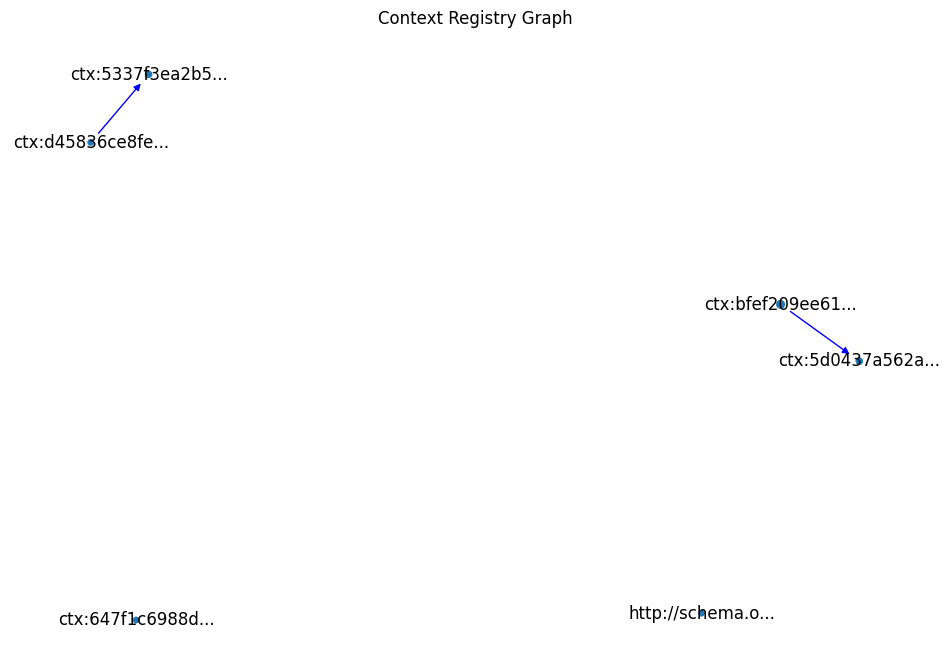

✓ Visualization complete


In [ ]:
# Visualize the context registry
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Create a graph of contexts and their relationships
G = nx.DiGraph()

# Add nodes for each context
for ctx_id, info in cp.registry.items():
    # Use a short version of the ID for display
    short_id = ctx_id[:15] + "..." if len(ctx_id) > 15 else ctx_id
    
    # Add node with attributes
    G.add_node(ctx_id, label=short_id, 
               vocabs=", ".join(info["vocabs"]),
               size=10 + len(info["vocabs"]) * 5)
    
    # Add edges for parent-child relationships
    if info["parent"]:
        G.add_edge(info["parent"], ctx_id, type="parent")
    
    # Add edges for scoped contexts
    for term, scoped_id in info["scoped"].items():
        G.add_edge(ctx_id, scoped_id, type="scoped", term=term)

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=[G.nodes[n]["size"] for n in G.nodes])
nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]["label"] for n in G.nodes})
nx.draw_networkx_edges(G, pos, edge_color="blue", arrows=True)

# Add edge labels for scoped contexts
edge_labels = {(u, v): G.edges[u, v]["term"] 
               for u, v in G.edges if G.edges[u, v]["type"] == "scoped"}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Context Registry Graph")
plt.axis("off")
plt.show()

print("✓ Visualization complete")

**AI Prompt**

Ok. Are we done with this code and our tests for the context manager?

**AI Response**

Looking at the code and tests you've implemented for the ContextProcessor, you've covered all the essential functionality:

1. ✅ Basic context registration
2. ✅ Vocabulary detection
3. ✅ JSON-LD 1.1 upgrade
4. ✅ Scoped context handling
5. ✅ Protected terms detection
6. ✅ Complex context handling
7. ✅ Visualization of the context registry

The graph visualization shows the relationships between different contexts, including parent-child relationships and scoped contexts, which is excellent for understanding the structure.

The tests appear to be working correctly, with all assertions passing. You've tested both simple and complex scenarios, which gives good coverage.

For a complete implementation, you might consider adding a few more things:

1. **Error handling tests**: Testing how the system behaves with invalid inputs
2. **Integration with SemanticMemory**: Connecting this to the main SemanticMemory class
3. **Performance metrics**: For large context structures

But for the core ContextProcessor functionality itself, your implementation looks solid and well-tested. The fastai-style implementation with small, focused methods and notebook-friendly testing is working well.

Would you like to move on to implementing the GraphManager next, or would you prefer to add any additional tests or features to the ContextProcessor?

## Graphmanager: Core

In [ ]:
#| export
class GraphManager:
    "Manages RDF graphs with vocabulary-aware features"
    def __init__(self, parent=None):
        self.parent = parent
        self.dataset = Dataset()  # Main RDF dataset
        self.default_graph = self.dataset.graph(URIRef("urn:x-arq:DefaultGraph"))
        self.metadata = {}  # Graph metadata storage
        
        # Initialize metadata for default graph
        default_key = str(self.default_graph.identifier)
        self.metadata[default_key] = {
            "created": datetime.now().isoformat(),
            "triples": 0,
            "vocabs": set(),
            "entities": set()
        }
        
        # Use print instead of _debug for initialization
        print("[GRAPH] GraphManager initialized")

In [ ]:
#| export
@patch
def _debug(self:GraphManager, msg, level=1, data=None, show_data=False):
    """Pass debug messages to parent if available, otherwise handle internally
    
    Args:
        msg: Debug message
        level: Debug level (higher means more detailed)
        data: Optional data to include with message
        show_data: Whether to display the data details
    """
    # First try to use parent's debug method if available
    if self.parent and hasattr(self.parent, "_debug"):
        try:
            self.parent._debug(msg, level=level, component="graph", 
                              data=data, show_data=show_data)
            return
        except Exception:
            # Fall through to local handling if parent debug fails
            pass
    
    # Local fallback for standalone use
    if level <= 1:  # Only show important messages by default
        print(f"[GRAPH] {msg}")
        if show_data and data is not None:
            print(f"  Data: {data}")

### GraphManager: core graph management methods

In [ ]:
#| export
@patch
def remove_graph(self:GraphManager, graph_id):
    """Remove a graph and its metadata
    
    Args:
        graph_id: Identifier of the graph to remove
        
    Returns:
        Boolean indicating success
    """
    graph_uri = URIRef(graph_id) if isinstance(graph_id, str) else graph_id
    graph_key = str(graph_uri)
    
    self._debug(f"Removing graph: {graph_uri}")
    
    # First check if this graph exists in our metadata
    if graph_key not in self.metadata:
        self._debug(f"Graph not found in metadata: {graph_uri}")
        return False
    
    try:
        # Use dataset.remove_graph which properly unregisters the graph
        # This is the key fix - use the right method that actually removes the graph
        self.dataset.remove_graph(graph_uri)
        self._debug(f"Removed graph using dataset.remove_graph: {graph_uri}")
        
        # Remove from our metadata
        del self.metadata[graph_key]
        self._debug(f"Removed graph metadata for: {graph_key}")
        
        return True
    except Exception as e:
        self._debug(f"Error removing graph: {str(e)}")
        
        # Fallback: at least try to remove all triples
        try:
            self.dataset.remove((None, None, None, graph_uri))
            self._debug(f"Fallback: Removed all triples from graph: {graph_uri}")
            
            # Still remove from our metadata
            del self.metadata[graph_key]
            self._debug(f"Removed graph metadata for: {graph_key}")
            
            return True
        except Exception as e2:
            self._debug(f"Error in fallback graph removal: {str(e2)}")
            return False

In [ ]:
#| export
@patch
def get_graph(self:GraphManager, graph_id=None, create_if_missing=True):
    """Get a graph by ID, optionally creating it if needed
    
    Args:
        graph_id: Optional identifier for the graph
        create_if_missing: Whether to create the graph if it doesn't exist
        
    Returns:
        The requested graph, or None if not found and not creating
    """
    if graph_id is None:
        return self.default_graph
    
    graph_uri = URIRef(graph_id) if isinstance(graph_id, str) else graph_id
    graph_key = str(graph_uri)
    
    # Check if this graph was explicitly removed
    if create_if_missing is False and graph_key not in self.metadata:
        self._debug(f"Graph not found and not creating: {graph_uri}")
        return None
    
    # Get or create the graph
    graph = self.dataset.graph(graph_uri)
    
    # Initialize metadata if needed
    if create_if_missing and graph_key not in self.metadata:
        self._debug(f"Creating new graph: {graph_uri}")
        self.metadata[graph_key] = {
            "created": datetime.now().isoformat(),
            "triples": 0,
            "vocabs": set(),
            "entities": set()
        }
    
    return graph

In [ ]:
#| export
@patch
def list_graphs(self:GraphManager, include_empty=True):
    """List all named graphs in the dataset
    
    Args:
        include_empty: Whether to include empty graphs in the result
        
    Returns:
        List of URIRef objects representing named graphs
    """
    # Get all contexts
    all_contexts = list(self.dataset.contexts())
    
    # Filter out default graphs
    default_identifiers = ["urn:x-arq:DefaultGraph", "urn:x-rdflib:default"]
    named_graphs = [g for g in all_contexts 
                   if str(g.identifier) not in default_identifiers]
    
    # Filter out empty graphs if requested
    if not include_empty:
        named_graphs = [g for g in named_graphs if len(g) > 0]
    
    # Return just the identifiers
    result = [g.identifier for g in named_graphs]
    
    self._debug(f"Listed {len(result)} graphs (include_empty={include_empty})")
    return result

### GraphManager: add methods for adding and managing entities in graphs

In [ ]:
@patch
def add_entity(self:GraphManager, entity, graph_id=None):
    """Add an entity to a specific graph
    
    Args:
        entity: JSON-LD entity to add (must have @id)
        graph_id: Optional graph identifier (uses default graph if None)
        
    Returns:
        Boolean indicating success
    """
    if not isinstance(entity, dict) or "@id" not in entity:
        self._debug(f"Invalid entity for graph addition", level=2)
        return False
        
    graph = self.get_graph(graph_id)
    graph_uri = graph.identifier
    graph_key = str(graph_uri)
    
    try:
        # Create temporary graph for entity
        g = Graph()
        g.parse(data=json.dumps(entity), format="json-ld")
        
        # Add to target graph
        initial_count = len(graph)
        graph += g
        final_count = len(graph)
        triples_added = final_count - initial_count
        
        # Update metadata
        self.metadata[graph_key]["triples"] += triples_added
        self.metadata[graph_key]["entities"].add(entity["@id"])
        
        # Improved vocabulary detection
        if "@context" in entity:
            # Option 1: Use context processor if available
            if self.parent and hasattr(self.parent, "context_processor"):
                vocabs = self.parent.context_processor.detect_vocabs(entity["@context"])
                self.metadata[graph_key]["vocabs"].update(vocabs)
            # Option 2: Use direct detection 
            else:
                from cogitarelink.vocabtools import detect_vocabularies_in_context
                try:
                    vocabs = detect_vocabularies_in_context(entity["@context"])
                    self.metadata[graph_key]["vocabs"].update(vocabs)
                except Exception as e:
                    self._debug(f"Vocabulary detection error: {str(e)}")
                    # Fallback for common vocabularies
                    ctx = entity["@context"]
                    if isinstance(ctx, str):
                        if "schema.org" in ctx or "schema.org" in ctx:
                            self.metadata[graph_key]["vocabs"].add("schema")
                        elif "purl.org/dc" in ctx:
                            self.metadata[graph_key]["vocabs"].add("dc")
                        elif "xmlns.com/foaf" in ctx:
                            self.metadata[graph_key]["vocabs"].add("foaf")
        
        self._debug(f"Added entity {entity['@id']} to graph {graph_uri}", level=2)
        return True
    except Exception as e:
        self._debug(f"Error adding entity to graph: {str(e)}")
        return False

#| export
@patch
def get_entity_graph(self:GraphManager, entity_id):
    "Find which graph contains an entity"
    for graph_key, meta in self.metadata.items():
        if entity_id in meta["entities"]:
            return graph_key
    return None

#| export
@patch
def get_entities_in_graph(self:GraphManager, graph_id=None, limit=None):
    "Get all entity IDs in a graph"
    graph_uri = URIRef(graph_id) if isinstance(graph_id, str) else graph_id
    graph_key = str(graph_uri) if graph_uri else str(self.default_graph.identifier)
    
    if graph_key in self.metadata:
        entities = list(self.metadata[graph_key]["entities"])
        if limit is not None:
            return entities[:limit]
        return entities
    return []

### Graph Manager: methods for graph querying and manipulation

In [ ]:
#| export
@patch
def query_graph(self:GraphManager, query, graph_id=None):
    "Run a SPARQL query against a specific graph or all graphs"
    try:
        if graph_id is not None:
            graph = self.get_graph(graph_id)
            results = graph.query(query)
        else:
            # Query entire dataset
            results = self.dataset.query(query)
        return results
    except Exception as e:
        self._debug(f"Query error: {str(e)}")
        return None

#| export
@patch
def merge_graphs(self:GraphManager, source_id, target_id):
    "Merge source graph into target graph"
    source = self.get_graph(source_id)
    target = self.get_graph(target_id)
    
    # Count initial triples
    initial_count = len(target)
    
    # Merge graphs
    target += source
    
    # Update metadata
    source_key = str(source.identifier)
    target_key = str(target.identifier)
    
    if source_key in self.metadata and target_key in self.metadata:
        # Transfer triple count
        triples_added = len(target) - initial_count
        self.metadata[target_key]["triples"] += triples_added
        
        # Transfer entities
        self.metadata[target_key]["entities"].update(
            self.metadata[source_key]["entities"]
        )
        
        # Transfer vocabularies
        self.metadata[target_key]["vocabs"].update(
            self.metadata[source_key]["vocabs"]
        )
    
    self._debug(f"Merged graph {source_id} into {target_id}")
    return True

### GraphManager: methods for vocabulary tracking

In [ ]:
#| export
@patch
def add_vocabulary_to_graph(self:GraphManager, graph_id, vocab_name):
    "Associate a vocabulary with a graph"
    graph_uri = URIRef(graph_id) if isinstance(graph_id, str) else graph_id
    graph_key = str(graph_uri)
    
    if graph_key in self.metadata:
        self.metadata[graph_key]["vocabs"].add(vocab_name)
        return True
    return False

#| export
@patch
def get_graph_vocabs(self:GraphManager, graph_id):
    "Get vocabularies used in a graph"
    graph_uri = URIRef(graph_id) if isinstance(graph_id, str) else graph_id
    graph_key = str(graph_uri)
    
    if graph_key in self.metadata:
        return list(self.metadata[graph_key]["vocabs"])
    return []

#| export
@patch
def find_graphs_by_vocab(self:GraphManager, vocab_name):
    "Find all graphs using a specific vocabulary"
    result = []
    for graph_key, meta in self.metadata.items():
        if vocab_name in meta["vocabs"]:
            result.append(graph_key)
    return result

### GraphManager: Debug Support and Utility Methods

In [ ]:
#| export
@patch
def serialize_graph(self:GraphManager, graph_id=None, format="trig"):
    "Serialize a graph to a specific format"
    if graph_id is None:
        # Serialize entire dataset
        return self.dataset.serialize(format=format).decode('utf-8')
    
    # Serialize specific graph
    graph = self.get_graph(graph_id)
    return graph.serialize(format=format).decode('utf-8')

In [ ]:
#| export
@patch
def graph_stats(self:GraphManager):
    "Get statistics about all graphs"
    stats = {
        "total_graphs": len(self.list_graphs()) + 1,  # +1 for default graph
        "total_triples": sum(len(g) for g in self.dataset.contexts()),
        "graphs": {}
    }
    
    # Add per-graph stats
    for graph_key, meta in self.metadata.items():
        stats["graphs"][graph_key] = {
            "entities": len(meta["entities"]),
            "triples": meta["triples"],
            "vocabs": list(meta["vocabs"])
        }
    
    return stats

### GraphManager Test: Basic

In [ ]:
# Create a test instance
gm = GraphManager()
print(f"Created GraphManager: {gm}")

# Test default graph
default_graph = gm.get_graph()
assert default_graph is not None, "Default graph should exist"
assert default_graph.identifier == URIRef("urn:x-arq:DefaultGraph"), "Default graph should have correct ID"
print("✓ Default graph initialization passed")

# Test named graph creation
test_graph_id = "http://example.org/graph1"
test_graph = gm.get_graph(test_graph_id)
assert test_graph is not None, "Named graph should be created"
assert test_graph.identifier == URIRef(test_graph_id), "Named graph should have correct ID"
assert str(test_graph.identifier) in gm.metadata, "Metadata should be initialized for graph"
print("✓ Named graph creation passed")

# Debug: Print contexts directly
print(f"Dataset contexts: {list(gm.dataset.contexts())}")
print(f"Graph identifiers: {[str(g.identifier) for g in gm.dataset.contexts()]}")

# Test graph listing
graphs = gm.list_graphs()
print(f"Returned graphs: {graphs}")
print(f"Returned graph identifiers: {[str(g) for g in graphs]}")
assert len(graphs) == 1, "Should have one named graph"
assert URIRef(test_graph_id) in graphs, "Graph should be in list"
print("✓ Graph listing passed")

[GRAPH] GraphManager initialized
Created GraphManager: <__main__.GraphManager object>
✓ Default graph initialization passed
[GRAPH] Creating new graph: http://example.org/graph1
✓ Named graph creation passed
Dataset contexts: [<Graph identifier=urn:x-arq:DefaultGraph (<class 'rdflib.graph.Graph'>)>, <Graph identifier=http://example.org/graph1 (<class 'rdflib.graph.Graph'>)>, <Graph identifier=urn:x-rdflib:default (<class 'rdflib.graph.Graph'>)>]
Graph identifiers: ['urn:x-rdflib:default', 'urn:x-arq:DefaultGraph', 'http://example.org/graph1']
[GRAPH] Listed 1 graphs (include_empty=True)
Returned graphs: [rdflib.term.URIRef('http://example.org/graph1')]
Returned graph identifiers: ['http://example.org/graph1']
✓ Graph listing passed


### GraphManager Test: Entities to Graph

In [ ]:
# Create test entities
person_entity = {
    "@context": "http://schema.org/",
    "@id": "http://example.org/person/1",
    "@type": "Person",
    "name": "Alice Smith",
    "jobTitle": "Software Engineer"
}

org_entity = {
    "@context": "http://schema.org/",
    "@id": "http://example.org/org/1",
    "@type": "Organization",
    "name": "Example Corp",
    "url": "http://example.org"
}

# Add entity to default graph
result = gm.add_entity(person_entity)
assert result is True, "Should successfully add entity to default graph"
default_key = str(gm.default_graph.identifier)
assert person_entity["@id"] in gm.metadata[default_key]["entities"], "Entity should be in default graph metadata"
print("✓ Adding entity to default graph passed")

# Add entity to named graph
result = gm.add_entity(org_entity, test_graph_id)
assert result is True, "Should successfully add entity to named graph"
assert org_entity["@id"] in gm.metadata[test_graph_id]["entities"], "Entity should be in named graph metadata"
print("✓ Adding entity to named graph passed")

# Test vocabulary tracking
assert "schema" in gm.metadata[default_key]["vocabs"], "Schema vocabulary should be tracked in default graph"
assert "schema" in gm.metadata[test_graph_id]["vocabs"], "Schema vocabulary should be tracked in named graph"
print("✓ Vocabulary tracking passed")

✓ Adding entity to default graph passed
✓ Adding entity to named graph passed
✓ Vocabulary tracking passed


### GraphManager: Test entity-graph relationship tracking

In [ ]:
# Test finding entity graph
entity_graph = gm.get_entity_graph(person_entity["@id"])
assert entity_graph == default_key, "Should find entity in default graph"

entity_graph = gm.get_entity_graph(org_entity["@id"])
assert entity_graph == test_graph_id, "Should find entity in named graph"
print("✓ Entity graph lookup passed")

# Test getting entities in graph
default_entities = gm.get_entities_in_graph()
assert person_entity["@id"] in default_entities, "Should find person entity in default graph"

graph_entities = gm.get_entities_in_graph(test_graph_id)
assert org_entity["@id"] in graph_entities, "Should find org entity in named graph"
print("✓ Graph entity listing passed")

✓ Entity graph lookup passed
✓ Graph entity listing passed


### GraphManager: test graph operations

In [ ]:
# Create another graph and entity
another_graph_id = "http://example.org/graph2"
another_graph = gm.get_graph(another_graph_id)

another_entity = {
    "@context": "http://purl.org/dc/terms/",
    "@id": "http://example.org/doc/1",
    "@type": "BibliographicResource",
    "title": "Example Document",
    "creator": "Bob Jones"
}

gm.add_entity(another_entity, another_graph_id)

# Test vocabulary tracking
assert "dc" in gm.metadata[another_graph_id]["vocabs"], "DC vocabulary should be tracked"
print("✓ Multiple vocabulary tracking passed")

# Test finding graphs by vocabulary
schema_graphs = gm.find_graphs_by_vocab("schema")
assert len(schema_graphs) == 2, "Should find two graphs using schema"
assert test_graph_id in schema_graphs, "First graph should use schema"
assert default_key in schema_graphs, "Default graph should use schema"

dc_graphs = gm.find_graphs_by_vocab("dc")
assert len(dc_graphs) == 1, "Should find one graph using dc"
assert another_graph_id in dc_graphs, "Second graph should use dc"
print("✓ Finding graphs by vocabulary passed")

# Test merging graphs
merge_result = gm.merge_graphs(another_graph_id, test_graph_id)
assert merge_result is True, "Graph merge should succeed"

# Verify merge results
merged_entities = gm.get_entities_in_graph(test_graph_id)
assert another_entity["@id"] in merged_entities, "Entity from second graph should be in merged graph"
assert "dc" in gm.metadata[test_graph_id]["vocabs"], "DC vocabulary should be in merged graph"
print("✓ Graph merging passed")

[GRAPH] Creating new graph: http://example.org/graph2
✓ Multiple vocabulary tracking passed
✓ Finding graphs by vocabulary passed
[GRAPH] Merged graph http://example.org/graph2 into http://example.org/graph1
✓ Graph merging passed


### GraphManager test: Removal

### GraphManager: RDF Dataset Details (o3)
Short answer: Your triple-removal tests are right, but the headline “RDFLib never deletes the graph itself” is only half-true.
Dataset.remove_graph() does drop the graph object from the store; the reason you still saw the identifiers in dataset.contexts() is that
1.	remove_context() never touches the graph registry (so graph2 stayed registered even though it was emptied), and
2.	your “Approach 4” calls ds.graph(graph1_uri) after the deletion.
That helper method creates a new Graph object for the same IRI and immediately re‑registers it with the store — even if it contains no triples.

⸻

What actually happens inside the in-memory store

* step	internal set __all_contexts (what contexts() iterates over)	explanation
* graph creation	{graph1, graph2, DEFAULT}	Dataset.graph() calls store.add_graph(g).
* remove_graph(graph1)	{graph2, DEFAULT}	MemoryStore.remove_graph() deletes all quads and removes the graph object.  
* remove_context(graph2)	unchanged ({graph2, DEFAULT})	Only the quads are cleared; the graph stays registered by design.
* your step 4 ds.graph(graph1_uri)	{graph1', graph2, DEFAULT}	A fresh empty Graph is added back.

If you print list(ds.contexts()) immediately after the two remove calls (and before step 4), you'll get only the default graph, proving the registration really was removed.

⸻

Design implications for your GraphManager
* Don't rely on dataset.contexts() to tell you what is “alive”.
Empty graphs can legitimately be present, either because someone used remove_context() or because code later called dataset.graph(iri).
* Consider one of these ways to decide “is the graph gone?”

1. - filter by length
active = [g for g in ds.contexts() if len(g)]

2. - let RDFLib filter for you (7.x)
active = list(ds.graphs(empty=False))      # excludes zero‑triple graphs

3. - maintain your own registry in GraphManager


* Use the right remover for the job.
	- Dataset.remove_graph(iri_or_graph) → clears triples and unregisters the graph.
	- Dataset.remove_context(graph)    → clears triples only.

⸻

Take-away

Your instinct to treat “no remaining triples” as “graph removed” is sound, but the extra bookkeeping belongs in your own layer, not in RDFLib. If you need a strict list of non‑empty graphs, call ds.graphs(empty=False) (added in 7.x) or just filter with len(g) > 0; if you truly want the graph to vanish from the registry, make sure you call remove_graph() and avoid creating a fresh Graph for the same IRI afterwards.

In [ ]:
# Test graph removal - reformulated again
print("\n=== Graph removal test (reformulated) ===")

# First, verify our graph exists
print(f"Before removal - all graphs: {[str(g.identifier) for g in gm.dataset.contexts()]}")

# Make sure we have metadata for this graph
if another_graph_id not in gm.metadata:
    # We need to recreate the graph since it wasn't properly created before
    print("Recreating graph for test...")
    another_graph = gm.get_graph(another_graph_id)
    gm.add_entity(another_entity, another_graph_id)
    print(f"Metadata after recreation: {another_graph_id in gm.metadata}")
    print(f"Entities: {gm.get_entities_in_graph(another_graph_id)}")

# Remove the graph
print(f"Attempting to remove graph: {another_graph_id}")
remove_result = gm.remove_graph(another_graph_id)
print(f"Removal result: {remove_result}")

# Check that triples are gone (using fallback for all RDFlib versions)
graphs_with_content = [str(g.identifier) for g in gm.dataset.contexts() if len(g) > 0]
print(f"Graphs with content after removal: {graphs_with_content}")
assert another_graph_id not in graphs_with_content, "Graph should not have content"

# Also check our metadata - this should be reliable
assert another_graph_id not in gm.metadata, "Graph should be removed from metadata"

# Check that we can't retrieve entities from the removed graph
assert gm.get_entities_in_graph(another_graph_id) == [], "Should get empty list for removed graph"

print("✓ Graph removal passed")


=== Graph removal test (reformulated) ===
Before removal - all graphs: ['urn:x-rdflib:default', 'http://example.org/graph2', 'urn:x-arq:DefaultGraph', 'http://example.org/graph1']
Attempting to remove graph: http://example.org/graph2
[GRAPH] Removing graph: http://example.org/graph2
[GRAPH] Removed graph using dataset.remove_graph: http://example.org/graph2
[GRAPH] Removed graph metadata for: http://example.org/graph2
Removal result: True
Graphs with content after removal: ['urn:x-arq:DefaultGraph', 'http://example.org/graph1']
✓ Graph removal passed


In [ ]:
# Test graph statistics
stats = gm.graph_stats()
print("Graph Statistics:")
print(f"Total Graphs: {stats['total_graphs']}")
print(f"Total Triples: {stats['total_triples']}")

# Print individual graph stats
for graph_id, graph_stats in stats["graphs"].items():
    print(f"Graph {graph_id}:")
    print(f"  Entities: {graph_stats['entities']}")
    print(f"  Vocabularies: {', '.join(graph_stats['vocabs'])}")

[GRAPH] Listed 1 graphs (include_empty=True)
Graph Statistics:
Total Graphs: 2
Total Triples: 7
Graph urn:x-arq:DefaultGraph:
  Entities: 1
  Vocabularies: schema
Graph http://example.org/graph1:
  Entities: 2
  Vocabularies: schema, dc


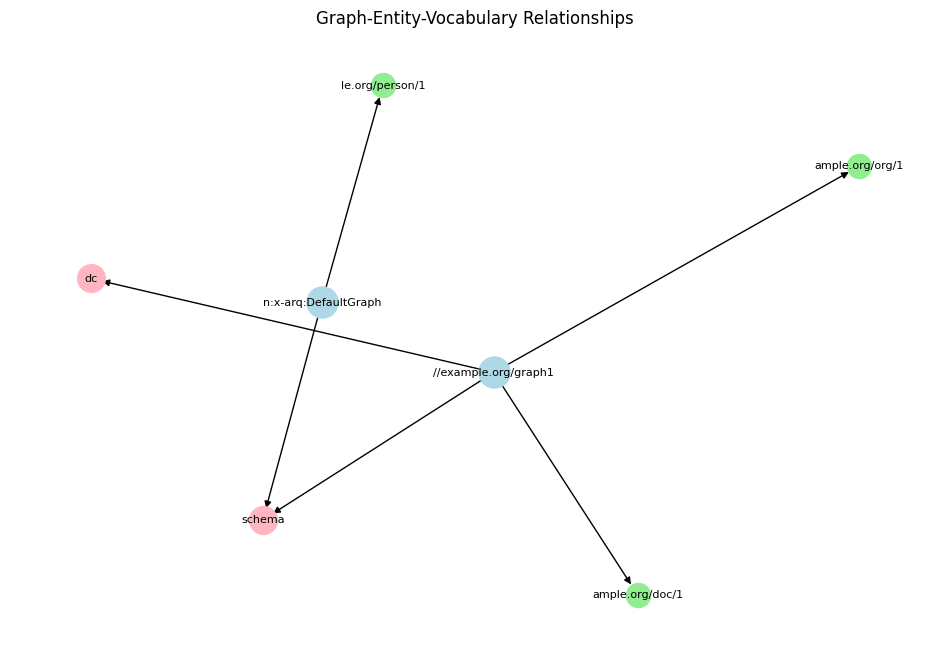

✓ Visualization complete


In [ ]:
# Create a visualization of graph-entity-vocabulary relationships
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph
G = nx.DiGraph()

# Add nodes for graphs
for graph_id, meta in gm.metadata.items():
    short_id = graph_id[-20:] if len(graph_id) > 20 else graph_id
    G.add_node(graph_id, label=short_id, type="graph")
    
    # Add nodes for entities in this graph
    for entity_id in meta["entities"]:
        short_entity = entity_id[-15:] if len(entity_id) > 15 else entity_id
        G.add_node(entity_id, label=short_entity, type="entity")
        G.add_edge(graph_id, entity_id)
    
    # Add nodes for vocabularies used in this graph
    for vocab in meta["vocabs"]:
        if vocab not in G.nodes:
            G.add_node(vocab, label=vocab, type="vocabulary")
        G.add_edge(graph_id, vocab, style="dashed")

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)

# Draw nodes by type
graph_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "graph"]
entity_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "entity"]
vocab_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "vocabulary"]

nx.draw_networkx_nodes(G, pos, nodelist=graph_nodes, node_color="lightblue", node_size=500)
nx.draw_networkx_nodes(G, pos, nodelist=entity_nodes, node_color="lightgreen", node_size=300)
nx.draw_networkx_nodes(G, pos, nodelist=vocab_nodes, node_color="lightpink", node_size=400)

# Draw edges
nx.draw_networkx_edges(G, pos)

# Draw labels
labels = {n: G.nodes[n]["label"] for n in G.nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

plt.title("Graph-Entity-Vocabulary Relationships")
plt.axis("off")
plt.show()

print("✓ Visualization complete")

## IndexManager

In [ ]:
#| export
class IndexManager:
    "Manages indices for efficient entity lookup"
    def __init__(self, parent=None):
        self.parent = parent
        self.by_id = {}            # Entity lookup by ID
        self.by_type = {}          # Entity lookup by type
        self.by_label = {}         # Entity lookup by label
        self.by_keyword = {}       # Entity lookup by keyword
        self.by_graph = {}         # Entity lookup by graph
        self.by_vocabulary = {}    # Entity lookup by vocabulary
        self.containers = {}       # Container structures
        
        # Debug support
        self._debug("IndexManager initialized")

In [ ]:
#| export
@patch
def _debug(self:IndexManager, msg, level=1, data=None, show_data=False):
    """Pass debug messages to parent if available, otherwise handle internally"""
    if self.parent and hasattr(self.parent, "_debug"):
        self.parent._debug(msg, level=level, component="index", 
                          data=data, show_data=show_data)
    else:
        if level <= 1:  # Only show important messages by default
            print(f"[INDEX] {msg}")

### IndexManager: Core Indexing Functions

In [ ]:
#| export
@patch
def add(self:IndexManager, entity, graph_id=None):
    """Add an entity to all relevant indices
    
    Args:
        entity: The entity to index (in expanded form)
        graph_id: Optional graph ID for graph-based indexing
        
    Returns:
        Boolean indicating success
    """
    if not isinstance(entity, dict):
        self._debug(f"Invalid entity for indexing: not a dict", level=2)
        return False
        
    # Get entity ID
    entity_id = entity.get('@id')
    if not entity_id:
        self._debug(f"Invalid entity for indexing: no @id", level=2)
        return False
    
    # Index by ID
    self.by_id[entity_id] = entity
    
    # Index by type
    self._index_by_type(entity)
    
    # Index by label and keywords
    self._index_labels_and_descriptions(entity)
    
    # Index by graph if provided
    if graph_id:
        self._index_by_graph(entity_id, graph_id)
    
    # Index subclass relationships
    self._index_subclass_relationships(entity)
    
    self._debug(f"Indexed entity: {entity_id}", level=2)
    return True

### IndexManager: Specific Indexing Methods

In [ ]:
#| export
@patch
def _index_by_type(self:IndexManager, entity):
    """Index entity by its types"""
    entity_id = entity.get('@id')
    if not entity_id:
        return
        
    # Extract types from entity
    types = []
    
    # Check for @type property
    if '@type' in entity:
        type_values = entity['@type'] if isinstance(entity['@type'], list) else [entity['@type']]
        for t in type_values:
            if isinstance(t, str):
                types.append(t)
    
    # Check for rdf:type triples in expanded JSON-LD
    rdf_type = 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type'
    if rdf_type in entity:
        type_objects = entity[rdf_type] if isinstance(entity[rdf_type], list) else [entity[rdf_type]]
        for t_obj in type_objects:
            if isinstance(t_obj, dict) and '@id' in t_obj:
                types.append(t_obj['@id'])
    
    # Index by each type
    for type_uri in types:
        if type_uri not in self.by_type:
            self.by_type[type_uri] = []
        if entity not in self.by_type[type_uri]:
            self.by_type[type_uri].append(entity)

## IndexManager: label and keyword indexing

In [ ]:
#| export
@patch
def _index_labels_and_descriptions(self:IndexManager, entity):
    """Index entity by labels and textual content for better search"""
    if not isinstance(entity, dict):
        return
    
    # Common label properties
    label_props = [
        "http://www.w3.org/2000/01/rdf-schema#label",
        "http://schema.org/name",
        "http://purl.org/dc/terms/title",
        "http://xmlns.com/foaf/0.1/name",
        "name"  # Handle both expanded and compact forms
    ]
    
    # Common description properties
    desc_props = [
        "http://www.w3.org/2000/01/rdf-schema#comment",
        "http://schema.org/description",
        "http://purl.org/dc/terms/description",
        "http://purl.org/dc/elements/1.1/description",
        "description"  # Handle both expanded and compact forms
    ]
    
    node_id = entity.get('@id')
    if not node_id:
        return
    
    # Extract labels for label index
    for prop in label_props:
        if prop in entity:
            values = entity[prop] if isinstance(entity[prop], list) else [entity[prop]]
            for value in values:
                label = value.get('@value') if isinstance(value, dict) else value
                if isinstance(label, str):
                    # Add to label index
                    if label not in self.by_label:
                        self.by_label[label] = []
                    if {'@id': node_id} not in self.by_label[label]:
                        self.by_label[label].append({'@id': node_id})
                    
                    # Index label as a whole
                    label_lower = label.lower()
                    if label_lower not in self.by_keyword:
                        self.by_keyword[label_lower] = []
                    if {'@id': node_id} not in self.by_keyword[label_lower]:
                        self.by_keyword[label_lower].append({'@id': node_id})
                    
                    # Index individual words and partial words
                    for word in label.split():
                        word_lower = word.lower()
                        if len(word_lower) > 2:
                            # Add whole word
                            if word_lower not in self.by_keyword:
                                self.by_keyword[word_lower] = []
                            if {'@id': node_id} not in self.by_keyword[word_lower]:
                                self.by_keyword[word_lower].append({'@id': node_id})

### IndexManager: Other indexing methods

In [ ]:
#| export
@patch
def _index_by_graph(self:IndexManager, entity_id, graph_id):
    """Index entity by graph"""
    graph_uri = graph_id
    if isinstance(graph_id, str):
        from rdflib import URIRef
        graph_uri = URIRef(graph_id)
    
    # Ensure the graph index exists
    if graph_uri not in self.by_graph:
        self.by_graph[graph_uri] = set()
    
    # Add entity to graph index
    self.by_graph[graph_uri].add(entity_id)
    
    self._debug(f"Indexed entity {entity_id} in graph {graph_id}", level=3)

#| export
@patch
def _index_subclass_relationships(self:IndexManager, entity):
    """Index subclass relationships for type inference"""
    if not isinstance(entity, dict):
        return
    
    # Initialize subclass indices if needed
    if not hasattr(self, 'subclass_of'):
        self.subclass_of = {}
    if not hasattr(self, 'superclass_of'):
        self.superclass_of = {}
    
    # Check for subClassOf relationship
    subclass_of = 'http://www.w3.org/2000/01/rdf-schema#subClassOf'
    if subclass_of in entity:
        class_id = entity.get('@id')
        if not class_id:
            return
        
        # Get all superclasses
        super_classes = entity[subclass_of] if isinstance(entity[subclass_of], list) else [entity[subclass_of]]
        
        for super_class in super_classes:
            if isinstance(super_class, dict) and '@id' in super_class:
                super_class_id = super_class['@id']
                
                # Record subclass relationship
                if class_id not in self.subclass_of:
                    self.subclass_of[class_id] = set()
                self.subclass_of[class_id].add(super_class_id)
                
                # Record superclass relationship (inverse)
                if super_class_id not in self.superclass_of:
                    self.superclass_of[super_class_id] = set()
                self.superclass_of[super_class_id].add(class_id)

## IndexManager: Track Vocabulary Usage

In [ ]:
#| export
@patch
def track_vocabulary_usage(self:IndexManager, entity_id, vocabs):
    """Track which vocabularies are used by an entity
    
    Args:
        entity_id: ID of the entity
        vocabs: List of vocabulary names used by the entity
    """
    if not entity_id or not vocabs:
        return
    
    # Track each vocabulary
    for vocab in vocabs:
        if vocab not in self.by_vocabulary:
            self.by_vocabulary[vocab] = set()
        self.by_vocabulary[vocab].add(entity_id)
    
    self._debug(f"Tracked vocabularies for {entity_id}: {vocabs}", level=3)

### IndexManager: Query Methods

In [ ]:
#| export
@patch
def query_by_id(self:IndexManager, entity_id):
    """Get entity by ID
    
    Args:
        entity_id: ID of the entity to retrieve
        
    Returns:
        The entity or None if not found
    """
    return self.by_id.get(entity_id)

#| export
@patch
def query_by_type(self:IndexManager, type_uri, include_subtypes=True):
    """Get entities of a specific type
    
    Args:
        type_uri: Type URI to query for
        include_subtypes: Whether to include entities of subtypes
        
    Returns:
        List of entities matching the type
    """
    results = []
    seen_ids = set()
    
    # Helper to add entities of a specific type
    def add_entities_of_type(t):
        if t in self.by_type:
            for entity in self.by_type[t]:
                entity_id = entity.get("@id")
                if entity_id and entity_id not in seen_ids:
                    results.append(entity)
                    seen_ids.add(entity_id)
    
    # Add entities of the specified type
    add_entities_of_type(type_uri)
    
    # Add entities of subtypes if requested
    if include_subtypes and hasattr(self, 'superclass_of'):
        if type_uri in self.superclass_of:
            for subtype in self.superclass_of[type_uri]:
                add_entities_of_type(subtype)
    
    return results

### IndexManager: Keyword Search

In [ ]:
#| export
@patch
def search(self:IndexManager, query_text, limit=10):
    """Search for entities matching query text
    
    Args:
        query_text: Text to search for
        limit: Maximum number of results to return
        
    Returns:
        List of matching entities
    """
    results = []
    query_lower = query_text.lower()
    
    # Track matched entities to avoid duplicates
    matched_ids = set()
    
    # First check exact label matches (highest priority)
    for label, entities in self.by_label.items():
        if isinstance(label, str) and query_lower in label.lower():
            for entity_ref in entities:
                if "@id" in entity_ref:
                    entity_id = entity_ref["@id"]
                    if entity_id not in matched_ids:
                        entity = self.query_by_id(entity_id)
                        if entity:
                            results.append(entity)
                            matched_ids.add(entity_id)
                            if len(results) >= limit:
                                return results
    
    # Then check keyword matches
    if query_lower in self.by_keyword:
        for entity_ref in self.by_keyword[query_lower]:
            if "@id" in entity_ref:
                entity_id = entity_ref["@id"]
                if entity_id not in matched_ids:
                    entity = self.query_by_id(entity_id)
                    if entity:
                        results.append(entity)
                        matched_ids.add(entity_id)
                        if len(results) >= limit:
                            return results
    
    # Try as partial match for any keywords
    for keyword, entities in self.by_keyword.items():
        if isinstance(keyword, str) and query_lower in keyword and query_lower != keyword:
            for entity_ref in entities:
                if "@id" in entity_ref:
                    entity_id = entity_ref["@id"]
                    if entity_id not in matched_ids:
                        entity = self.query_by_id(entity_id)
                        if entity:
                            results.append(entity)
                            matched_ids.add(entity_id)
                            if len(results) >= limit:
                                return results
    
    return results

In [ ]:
# Create a test instance
im = IndexManager()
print(f"Created IndexManager: {im}")

# Test basic initialization
assert hasattr(im, 'by_id'), "Should have by_id index"
assert hasattr(im, 'by_type'), "Should have by_type index"
assert hasattr(im, 'by_label'), "Should have by_label index"
assert hasattr(im, 'by_keyword'), "Should have by_keyword index"
assert hasattr(im, 'by_graph'), "Should have by_graph index"
assert hasattr(im, 'by_vocabulary'), "Should have by_vocabulary index"
print("✓ Basic initialization passed")

# Create test entities
person_entity = {
    "@id": "http://example.org/person/1",
    "@type": "http://schema.org/Person",
    "http://schema.org/name": [{"@value": "Alice Smith"}],
    "http://schema.org/jobTitle": [{"@value": "Software Engineer"}]
}

org_entity = {
    "@id": "http://example.org/org/1",
    "@type": "http://schema.org/Organization",
    "http://schema.org/name": [{"@value": "Example Corp"}],
    "http://schema.org/url": [{"@id": "http://example.org"}]
}

# Test adding entities
result = im.add(person_entity)
assert result is True, "Should successfully add entity"
assert person_entity["@id"] in im.by_id, "Entity should be in by_id index"
print("✓ Entity addition passed")

# Test type indexing
assert "http://schema.org/Person" in im.by_type, "Type should be indexed"
assert person_entity in im.by_type["http://schema.org/Person"], "Entity should be in type index"
print("✓ Type indexing passed")

# Test label indexing
result = im.add(org_entity)
assert "Example Corp" in im.by_label, "Label should be indexed"
assert {"@id": org_entity["@id"]} in im.by_label["Example Corp"], "Entity should be in label index"
print("✓ Label indexing passed")

# Test keyword indexing
assert "alice" in im.by_keyword, "Keyword should be indexed"
assert "example" in im.by_keyword, "Keyword should be indexed"
print("✓ Keyword indexing passed")

# Test graph indexing
test_graph_id = "http://example.org/graph1"
im._index_by_graph(person_entity["@id"], test_graph_id)
assert URIRef(test_graph_id) in im.by_graph, "Graph should be indexed"
assert person_entity["@id"] in im.by_graph[URIRef(test_graph_id)], "Entity should be in graph index"
print("✓ Graph indexing passed")

# Test vocabulary tracking
im.track_vocabulary_usage(person_entity["@id"], ["schema"])
assert "schema" in im.by_vocabulary, "Vocabulary should be tracked"
assert person_entity["@id"] in im.by_vocabulary["schema"], "Entity should be in vocabulary index"
print("✓ Vocabulary tracking passed")

# Test querying
entity = im.query_by_id(person_entity["@id"])
assert entity is person_entity, "Should retrieve entity by ID"
print("✓ ID query passed")

entities = im.query_by_type("http://schema.org/Person")
assert len(entities) == 1, "Should find one person entity"
assert entities[0] is person_entity, "Should retrieve person entity by type"
print("✓ Type query passed")

# Test search
search_results = im.search("alice")
assert len(search_results) > 0, "Should find results for 'alice'"
assert person_entity in search_results, "Should find person entity"
print("✓ Text search passed")

# Test subclass relationships
class_entity = {
    "@id": "http://example.org/types/Employee",
    "@type": "http://www.w3.org/2000/01/rdf-schema#Class",
    "http://www.w3.org/2000/01/rdf-schema#subClassOf": [
        {"@id": "http://schema.org/Person"}
    ]
}
im.add(class_entity)
im._index_subclass_relationships(class_entity)

assert hasattr(im, 'subclass_of'), "Should have subclass_of index"
assert hasattr(im, 'superclass_of'), "Should have superclass_of index"
assert "http://example.org/types/Employee" in im.subclass_of, "Should track subclass relationship"
assert "http://schema.org/Person" in im.superclass_of, "Should track superclass relationship"
print("✓ Subclass relationship indexing passed")

print("\nAll IndexManager tests passed!")

[INDEX] IndexManager initialized
Created IndexManager: <__main__.IndexManager object>
✓ Basic initialization passed
✓ Entity addition passed
✓ Type indexing passed
✓ Label indexing passed
✓ Keyword indexing passed
✓ Graph indexing passed
✓ Vocabulary tracking passed
✓ ID query passed
✓ Type query passed
✓ Text search passed
✓ Subclass relationship indexing passed

All IndexManager tests passed!


**AI Prompt**

I'm happy with this version of cache manager. The only question is: does it need integration with the vocabulary tools or not?

**AI Response**

Yes, the CacheManager would benefit from integration with the vocabulary tools. Here's why and how it could work:

### Vocabulary Tools Integration

The CacheManager should handle:

1. **Vocabulary Context Caching**: Store vocabulary contexts to avoid repeated HTTP requests
   - This replaces the current context caching in the vocabulary loader
   - Provides a more robust caching mechanism with disk persistence

2. **Vocabulary Preloading**: Streamline the vocabulary preloading process
   - Cache commonly used vocabularies (schema.org, Dublin Core, etc.)
   - Manage vocabulary loading states

3. **Resource Resolution**: Resolve vocabulary resources across different sources
   - Handle redirects and content negotiation
   - Apply URL transformations from the vocabulary registry

### Implementation Approach

To integrate with vocabulary tools, we could:

1. Add specialized methods for vocabulary caching:
   ```python
   def cache_vocabulary(self, vocab_name, context_data):
       """Cache vocabulary context data"""
   
   def get_cached_vocabulary(self, vocab_name):
       """Retrieve cached vocabulary context"""
   ```

2. Create a document loader that uses the cache:
   ```python
   def create_caching_document_loader(self):
       """Create a document loader that uses this cache"""
   ```

3. Provide vocabulary preloading:
   ```python
   def preload_vocabulary(self, vocab_name):
       """Preload a vocabulary to avoid HTTP requests"""
   ```

This integration would create a cleaner architecture where:
- Vocabulary tools define what's available
- CacheManager handles storage and retrieval
- The rest of the system accesses vocabularies through the cache

Does this integration approach make sense for your use case?

## CacheManager

In [ ]:
#| export
class CacheManager:
    "Manages caching of external resources and processed data with vocabulary support"
    def __init__(self, parent=None, cache_dir=None):
        self.parent = parent
        self.cache_dir = cache_dir
        if cache_dir: Path(cache_dir).mkdir(exist_ok=True)
        
        # Memory caches
        self.context_cache = {}    # Cache for JSON-LD contexts
        self.entity_cache = {}     # Cache for processed entities
        self.original_data = {}    # Original entity data
        self.vocab_cache = {}      # Cache for vocabulary contexts
        
        # Track loaded vocabularies
        self.loaded_vocabs = set()
        
        # Debug support
        self._debug("CacheManager initialized")

In [ ]:
#| export
@patch
def _debug(self:CacheManager, msg, level=1, data=None, show_data=False):
    """Pass debug messages to parent if available"""
    if self.parent and hasattr(self.parent, "_debug"):
        self.parent._debug(msg, level=level, component="cache", 
                          data=data, show_data=show_data)
    else:
        if level <= 1:  # Only show important messages by default
            print(f"[CACHE] {msg}")

In [ ]:
#| export
@patch
def cache_vocabulary(self:CacheManager, vocab_name, context_data):
    """Cache vocabulary context data
    
    Args:
        vocab_name: Name of the vocabulary
        context_data: Context data to cache
        
    Returns:
        Boolean indicating success
    """
    self.vocab_cache[vocab_name] = context_data
    self.loaded_vocabs.add(vocab_name)
    
    # Persist to disk if cache_dir is set
    if self.cache_dir:
        try:
            vocab_path = Path(self.cache_dir) / f"vocab_{vocab_name}.json"
            with open(vocab_path, 'w') as f:
                json.dump(context_data, f)
            self._debug(f"Persisted vocabulary {vocab_name} to disk")
            return True
        except Exception as e:
            self._debug(f"Error persisting vocabulary {vocab_name}: {e}")
            return False
    
    return True

### CacheManager: Vocabulary Retrieval

In [ ]:
@patch
def get_cached_vocabulary(self:CacheManager, vocab_name):
    """Retrieve cached vocabulary context
    
    Args:
        vocab_name: Name of the vocabulary
        
    Returns:
        Cached context data or None if not found
    """
    # First check memory cache
    if vocab_name in self.vocab_cache:
        self._debug(f"Memory cache hit for vocabulary {vocab_name}", level=2)
        return self.vocab_cache[vocab_name]
    
    # Then check disk cache if available
    if self.cache_dir:
        try:
            vocab_path = Path(self.cache_dir) / f"vocab_{vocab_name}.json"
            if vocab_path.exists():
                with open(vocab_path, 'r') as f:
                    context_data = json.load(f)
                    # Update memory cache
                    self.vocab_cache[vocab_name] = context_data
                    self.loaded_vocabs.add(vocab_name)
                    self._debug(f"Disk cache hit for vocabulary {vocab_name}", level=2)
                    return context_data
        except Exception as e:
            self._debug(f"Error reading vocabulary {vocab_name} from disk: {e}")
    
    self._debug(f"Cache miss for vocabulary {vocab_name}", level=2)
    return None

### CacheManager: Entity Caching

In [ ]:
@patch
def cache_entity(self:CacheManager, entity_id, original_data, processed_data=None):
    """Cache entity data
    
    Args:
        entity_id: Entity identifier
        original_data: Original entity data
        processed_data: Optional processed entity data
        
    Returns:
        Boolean indicating success
    """
    self.original_data[entity_id] = original_data
    if processed_data is not None:
        self.entity_cache[entity_id] = processed_data
    
    return True

@patch
def get_cached_entity(self:CacheManager, entity_id, original=False):
    """Retrieve cached entity
    
    Args:
        entity_id: Entity identifier
        original: Whether to return original data (default: processed)
        
    Returns:
        Cached entity data or None if not found
    """
    if original and entity_id in self.original_data:
        return self.original_data[entity_id]
    elif not original and entity_id in self.entity_cache:
        return self.entity_cache[entity_id]
    return None

### CacheManager: Context Caching

In [ ]:
@patch
def cache_context(self:CacheManager, context_url, context_data):
    """Cache a JSON-LD context
    
    Args:
        context_url: URL or identifier for the context
        context_data: Context data to cache
        
    Returns:
        Boolean indicating success
    """
    self.context_cache[context_url] = context_data
    return True

@patch
def get_cached_context(self:CacheManager, context_url):
    """Retrieve a cached JSON-LD context
    
    Args:
        context_url: URL or identifier for the context
        
    Returns:
        Cached context data or None if not found
    """
    return self.context_cache.get(context_url)

### CacheManager: Document Loader Integration

In [ ]:
#| export
@patch
def create_document_loader(self:CacheManager, debug=False):
    """Create a document loader with optional debugging
    
    Args:
        debug: Whether to enable debug output
        
    Returns:
        A function that can be used as a PyLD document loader
    """
    from pyld import jsonld
    default_loader = jsonld.get_document_loader()
    
    def caching_document_loader(url, options=None):
        """Document loader that uses this cache with optional debugging"""
        options = options or {}
        
        if debug:
            print(f"[LOADER DEBUG] Loading: {url}")
            print(f"[LOADER DEBUG] Options: {options}")
        
        # Check cache first
        cached_context = self.get_cached_context(url)
        if cached_context:
            if debug:
                print(f"[LOADER DEBUG] Cache hit for {url}")
                if isinstance(cached_context, dict):
                    print(f"[LOADER DEBUG] Cache keys: {list(cached_context.keys())}")
            
            self._debug(f"Context cache hit for {url}", level=2)
            return {
                'contextUrl': None,
                'documentUrl': url,
                'document': cached_context
            }
        
        # Try to load from network
        try:
            if debug:
                print(f"[LOADER DEBUG] Cache miss, loading from network: {url}")
            
            result = default_loader(url, options)
            
            # Cache the result
            if result and 'document' in result:
                self.cache_context(url, result['document'])
                self._debug(f"Cached context for {url}", level=2)
                
                if debug:
                    print(f"[LOADER DEBUG] Cached document from network")
                    if isinstance(result['document'], dict):
                        print(f"[LOADER DEBUG] Document keys: {list(result['document'].keys())}")
            
            return result
        except Exception as e:
            self._debug(f"Error loading document {url}: {e}")
            if debug:
                print(f"[LOADER DEBUG] Error: {e}")
            raise
    
    return caching_document_loader

### CacheManager: Vocabulary Pre-loading

In [ ]:
@patch
def preload_vocabulary(self:CacheManager, vocab_name):
    """Preload a vocabulary to avoid HTTP requests
    
    Args:
        vocab_name: Name of the vocabulary to preload
        
    Returns:
        Boolean indicating success
    """
    from cogitarelink.vocabtools import load_context_for_vocabulary
    
    # Check if already loaded
    if vocab_name in self.loaded_vocabs:
        self._debug(f"Vocabulary {vocab_name} already loaded")
        return True
    
    # Check cache first
    cached = self.get_cached_vocabulary(vocab_name)
    if cached:
        self._debug(f"Using cached vocabulary {vocab_name}")
        return True
    
    # Load from network
    try:
        self._debug(f"Loading vocabulary {vocab_name}")
        context = load_context_for_vocabulary(vocab_name)
        if context:
            # Cache the vocabulary
            return self.cache_vocabulary(vocab_name, context)
        return False
    except Exception as e:
        self._debug(f"Error preloading vocabulary {vocab_name}: {e}")
        return False

In [ ]:
# Create a test instance
cm = CacheManager(cache_dir="/tmp/test_cache")
print(f"Created CacheManager: {cm}")

# Test basic initialization
assert hasattr(cm, 'context_cache'), "Should have context_cache"
assert hasattr(cm, 'entity_cache'), "Should have entity_cache"
assert hasattr(cm, 'original_data'), "Should have original_data"
assert hasattr(cm, 'vocab_cache'), "Should have vocab_cache"
print("✓ Basic initialization passed")

# Test context caching
test_context = {"@vocab": "http://example.org/vocab#"}
result = cm.cache_context("http://example.org/context", test_context)
assert result is True, "Should successfully cache context"
cached = cm.get_cached_context("http://example.org/context")
assert cached == test_context, "Should retrieve cached context"
print("✓ Context caching passed")

# Test entity caching
entity_id = "http://example.org/entity/1"
original_data = {"@id": entity_id, "name": "Test Entity"}
processed_data = {"@id": entity_id, "http://example.org/vocab#name": [{"@value": "Test Entity"}]}
result = cm.cache_entity(entity_id, original_data, processed_data)
assert result is True, "Should successfully cache entity"
cached_original = cm.get_cached_entity(entity_id, original=True)
assert cached_original == original_data, "Should retrieve original entity data"
cached_processed = cm.get_cached_entity(entity_id)
assert cached_processed == processed_data, "Should retrieve processed entity data"
print("✓ Entity caching passed")

# Test vocabulary caching (if possible)
try:
    # This might require network access, so wrap in try/except
    vocab_name = "schema"
    result = cm.preload_vocabulary(vocab_name)
    assert result is True, "Should successfully preload vocabulary"
    assert vocab_name in cm.loaded_vocabs, "Should track loaded vocabulary"
    cached_vocab = cm.get_cached_vocabulary(vocab_name)
    assert cached_vocab is not None, "Should retrieve cached vocabulary"
    print("✓ Vocabulary preloading passed")
except Exception as e:
    print(f"Skipping vocabulary preloading test: {e}")

# Test document loader
loader = cm.create_document_loader()
assert callable(loader), "Should create a document loader function"
print("✓ Document loader creation passed")

# Test persistence (if possible)
if cm.cache_dir:
    vocab_path = Path(cm.cache_dir) / f"vocab_test.json"
    test_vocab = {"@vocab": "http://example.org/test#"}
    result = cm.cache_vocabulary("test", test_vocab)
    assert result is True, "Should successfully cache vocabulary"
    assert vocab_path.exists(), "Should persist vocabulary to disk"
    print("✓ Cache persistence passed")

print("\nAll CacheManager tests passed!")

[CACHE] CacheManager initialized
Created CacheManager: <__main__.CacheManager object>
✓ Basic initialization passed
✓ Context caching passed
✓ Entity caching passed
[CACHE] Using cached vocabulary schema
✓ Vocabulary preloading passed
✓ Document loader creation passed
[CACHE] Persisted vocabulary test to disk
✓ Cache persistence passed

All CacheManager tests passed!


## SemanticMemory

In [ ]:
#| export
class SemanticMemory:
    "Enhanced semantic memory with component-based architecture"
    def __init__(self, cache_dir=None, preload_vocabs=None, debug=False, debug_level=0):
        # Debug settings
        self.debug = debug
        self.debug_level = debug_level
        self.debug_components = set()
        self._debug_stats = {"start_time": time.time(), "entities_processed": 0, "contexts_registered": 0}
        
        # Relationship stats
        self._relationship_stats = {}

        # Initialize components
        self.contexts = ContextProcessor(self)
        self.graphs = GraphManager(self)
        self.indices = IndexManager(self)
        self.cache = CacheManager(self, cache_dir)
        
        # Set up vocabulary support
        register_vocab_aware_loader()
        
        # Preload vocabularies if specified
        if preload_vocabs:
            for vocab in preload_vocabs:
                self.cache.preload_vocabulary(vocab)
        else:
            # Default vocabularies
            for vocab in ["schema", "dc", "foaf"]:
                self.cache.preload_vocabulary(vocab)
                
        if self.debug: 
            self._debug(f"SemanticMemory initialized with debug={debug}, level={debug_level}")

### SemanticMemory Add

In [ ]:
#| export
@patch
def add(self:SemanticMemory, data, graph_id=None):
    """Add entity to semantic memory
    
    Args:
        data: JSON-LD entity or graph to add
        graph_id: Optional ID for named graph to store entity in
        
    Returns:
        Dict with metadata about added entities
    """
    # Track transformations applied
    transformations = []
    
    # First, upgrade to JSON-LD 1.1
    original_data = copy.deepcopy(data)
    upgraded_data = self.contexts.upgrade_to_11(data)
    if upgraded_data != original_data:
        transformations.append("json-ld-1.1-upgrade")
    
    # Handle context processing for protection
    if "@context" in upgraded_data:
        context = upgraded_data["@context"]
        
        # Process context arrays properly
        if isinstance(context, list):
            processed_context = self.contexts.process_context_array(context)
            upgraded_data["@context"] = processed_context
            transformations.append("context-array-processed")
        # Process imports in single context
        elif isinstance(context, dict) and "@import" in context:
            processed_context = self.contexts.process_imports(context)
            upgraded_data["@context"] = processed_context
            transformations.append("context-import-processed")
    
    # Initialize result structure
    result = {
        "added": [],
        "count": 0,
        "transformations": transformations,
        "types": {},
        "graphs": {},
        "vocabularies": set()
    }
    
    # Check if we need to partition the data into a graph
    if self._needs_graph_partition(upgraded_data):
        upgraded_data = self._create_graph_partition(upgraded_data)
        transformations.append("graph-partition")
    
    # Process graph structure if present
    if isinstance(upgraded_data, dict) and "@graph" in upgraded_data:
        entities = self._process_graph(upgraded_data, graph_id)
        
        # Ensure entities is a list
        if entities and not isinstance(entities, list):
            entities = [entities]
            
        result["count"] = len(entities)
        
        # Update result with processed entities
        for entity in entities:
            if isinstance(entity, dict) and "@id" in entity:
                entity_id = entity["@id"]
                result["added"].append(entity_id)
                
                # Track entity types
                if "@type" in entity:
                    types = entity["@type"] if isinstance(entity["@type"], list) else [entity["@type"]]
                    result["types"][entity_id] = types
                
                # Track graph location
                if graph_id:
                    result["graphs"][entity_id] = graph_id
    else:
        # Process single entity
        entity = self._process_entity(upgraded_data, graph_id)
        
        # Ensure we have a dictionary entity with an ID
        if entity:
            if isinstance(entity, list) and entity and isinstance(entity[0], dict) and "@id" in entity[0]:
                # Handle case where entity is still a list
                entity = entity[0]
            
            if isinstance(entity, dict) and "@id" in entity:
                entity_id = entity["@id"]
                result["added"].append(entity_id)
                result["count"] = 1
                
                # Track entity types
                if "@type" in entity:
                    types = entity["@type"] if isinstance(entity["@type"], list) else [entity["@type"]]
                    result["types"][entity_id] = types
                
                # Track graph location
                if graph_id:
                    result["graphs"][entity_id] = graph_id
    
    # Detect vocabularies used
    for entity_id in result["added"]:
        entity_data = self.cache.get_cached_entity(entity_id, original=True)
        if entity_data and "@context" in entity_data:
            vocabs = self.contexts.detect_vocabs(entity_data["@context"])
            result["vocabularies"].update(vocabs)
    
    # Convert vocabulary set to list for JSON serialization
    result["vocabularies"] = list(result["vocabularies"])
    
    return result

### SemanticMemory: Process Entity

In [ ]:
#| export
@patch
def _process_entity(self:SemanticMemory, data, graph_id=None):
    "Process a single entity with improved context propagation and type-scoped handling"
    import copy, uuid
    
    if not isinstance(data, dict): return None

    # Normalize the entity
    entity = self._normalize_entity(copy.deepcopy(data))

    # Process imports in the context if needed
    if "@context" in entity and isinstance(entity["@context"], dict) and "@import" in entity["@context"]:
        self._debug(f"Processing imports in entity context", level=2)
        entity["@context"] = self.contexts.process_imports(entity["@context"])

    # Ensure ID
    if "@id" not in entity: entity["@id"] = f"urn:uuid:{uuid.uuid4()}"
    entity_id = entity["@id"]

    # Cache original data
    self.cache.cache_entity(entity_id, entity)
    
    # Track nested entities that need separate processing
    nested_entities = []
    
    # Extract nested entities
    for prop, value in list(entity.items()):
        if prop.startswith("@"): continue
            
        # Check for nested entity objects
        if isinstance(value, dict) and "@id" in value:
            # Store reference to original context if available
            if "@context" in entity: value["_parent_context"] = entity["@context"]
            nested_entities.append(value)
            entity[prop] = {"@id": value["@id"]}
        elif isinstance(value, list):
            for i, item in enumerate(value):
                if isinstance(item, dict) and "@id" in item:
                    # Store reference to original context if available
                    if "@context" in entity: item["_parent_context"] = entity["@context"]
                    nested_entities.append(item)
                    value[i] = {"@id": item["@id"]}

    # Register context and track associations
    parent_context = None
    propagate_context = True
    context_id = None

    if "@context" in entity:
        context_id = self.contexts.register(entity["@context"])
        parent_context = entity["@context"]

        # Check for @propagate directive
        if isinstance(parent_context, dict) and "@propagate" in parent_context:
            propagate_context = parent_context["@propagate"]
            self._debug(f"Found @propagate: {propagate_context} in context", level=2)

        # Always cache the context
        if isinstance(entity["@context"], (dict, str)):
            cache_url = entity["@id"] + "#context" if "@id" in entity else f"ctx:{context_id}"
            self.cache.cache_context(cache_url, entity["@context"])

        # Track vocabularies
        vocabs = self.contexts.detect_vocabs(entity["@context"])
        self.indices.track_vocabulary_usage(entity_id, vocabs)

    # Apply type-scoped contexts if present
    scoped_ctx_id = None
    if "@type" in entity and context_id:
        scoped_ctx_id = self.contexts.apply_scoped_contexts(entity, context_id)
        if scoped_ctx_id:
            self._debug(f"Applied type-scoped contexts for entity {entity_id}", level=2)
            
            # Replace the entire context with the merged one
            if scoped_ctx_id in self.contexts.registry:
                merged_ctx = self.contexts.registry[scoped_ctx_id].get('context', {})
                if merged_ctx:
                    # Create a new entity with the merged context
                    expansion_entity = copy.deepcopy(entity)
                    expansion_entity["@context"] = merged_ctx
                    
                    # Use this entity for expansion instead
                    entity = expansion_entity
                    self._debug(f"Using merged context for expansion", level=3)

    # Try expanding
    try:
        with self.debug_section("Entity expansion", level=2) if self.debug else nullcontext():
            from pyld import jsonld
            expanded_list = jsonld.expand(entity)
            
            # Extract the first entity from the list (typical case)
            expanded = expanded_list[0] if expanded_list and isinstance(expanded_list, list) else expanded_list
            
            # Ensure we have a valid dictionary
            if not isinstance(expanded, dict):
                if self.debug: self._debug(f"Expansion returned non-dict: {type(expanded)}", level=2)
                expanded = {"@id": entity_id}
                if "@type" in entity: expanded["@type"] = entity["@type"]
            
            # Cache expanded data
            self.cache.cache_entity(entity_id, entity, expanded)
            
            # Index the expanded entity
            self.indices.add(expanded, graph_id)
            
            # Add to graph
            if graph_id:
                if self.debug and self.debug_level >= 2: self._debug(f"Adding entity {entity_id} to graph {graph_id}", level=2)
                self.graphs.add_entity(expanded, graph_id)
            else:
                self.graphs.add_entity(expanded)
            
            # Update stats
            self._debug_stats["entities_processed"] += 1
            
            # Process any nested entities independently
            for nested in nested_entities:
                if self.debug and self.debug_level >= 2: self._debug(f"Processing nested entity: {nested.get('@id')}", level=2)
                nested_copy = copy.deepcopy(nested)
                
                # Ensure nested entity has a context
                if "@context" not in nested_copy:
                    # If parent has propagating context, use it
                    if propagate_context and parent_context:
                        nested_copy["@context"] = parent_context
                    # Otherwise use a basic context
                    else:
                        nested_copy["@context"] = {"@version": 1.1}
                        
                    # If parent context exists but doesn't propagate, check for _parent_context
                    if not propagate_context and "_parent_context" in nested_copy:
                        # Only use for type-scoped contexts
                        if "@type" in nested_copy and context_id:
                            nested_copy["@context"] = nested_copy["_parent_context"]
                        
                # Clean up temporary property
                if "_parent_context" in nested_copy:
                    del nested_copy["_parent_context"]
                    
                # Process the nested entity
                nested_result = self._process_entity(nested_copy, graph_id)
            
            return expanded
    except Exception as e:
        if self.debug: self._debug(f"JSON-LD expansion failed: {e}")
        
        # Fallback to direct indexing
        entity_with_id = {"@id": entity_id}
        if "@type" in entity: entity_with_id["@type"] = entity["@type"]
        
        self.indices.by_id[entity_id] = entity
        
        if "@type" in entity:
            types = [entity["@type"]] if not isinstance(entity["@type"], list) else entity["@type"]
            for t in types:
                if t not in self.indices.by_type: self.indices.by_type[t] = []
                self.indices.by_type[t].append(entity)
        
        # Process nested entities even in error case
        for nested in nested_entities:
            if self.debug: self._debug(f"Processing nested entity (after error): {nested.get('@id')}", level=2)
            nested_copy = copy.deepcopy(nested)
            if "@context" not in nested_copy: nested_copy["@context"] = {"@version": 1.1}
            self._process_entity(nested_copy, graph_id)
        
        return entity

In [ ]:
#| export
@patch
def _process_graph(self:SemanticMemory, data, graph_id=None):
    """Process a graph structure with multiple entities
    
    Args:
        data: Graph data to process
        graph_id: Optional graph ID to store entities in
        
    Returns:
        List of processed entities
    """
    if not isinstance(data, dict) or "@graph" not in data: 
        return None
    
    results = []
    shared_ctx = data.get("@context")
    
    # Process each entity
    for entity in data["@graph"]:
        # Skip bare references
        if isinstance(entity, dict) and len(entity) == 1 and "@id" in entity: 
            continue
        
        # Apply shared context if needed
        if shared_ctx and isinstance(entity, dict) and "@context" not in entity:
            entity = dict(entity, **{"@context": shared_ctx})
        
        # Process entity
        result = self._process_entity(entity, graph_id)
        if result: 
            results.append(result)
    
    return results

In [ ]:
#| export
@patch
def _find_nested_properties(self:SemanticMemory, context):
    """Find properties marked with @nest in a context"""
    nested_props = []
    
    if isinstance(context, str):
        return nested_props  # String contexts don't have nested properties
    
    if isinstance(context, list):
        # Process each context in the list
        for ctx in context:
            nested_props.extend(self._find_nested_properties(ctx))
        return nested_props
    
    if isinstance(context, dict):
        # Look for terms defined as @nest
        for term, value in context.items():
            if value == "@nest":
                nested_props.append(term)
            elif isinstance(value, dict) and value.get("@id") == "@nest":
                nested_props.append(term)
            # Also look for @nest in term definitions
            elif isinstance(value, dict) and "@nest" in value:
                # This term should be nested under the specified container
                pass  # We're handling the inverse case here (unnesting)
    
    return nested_props

In [ ]:
#| export
@patch
def _normalize_entity(self:SemanticMemory, data):
    """Normalize entity properties for consistent processing with @nest support"""
    if not isinstance(data, dict): 
        return data
    
    result = data.copy()
    
    # Normalize id → @id
    if "id" in result:
        if "@id" not in result: 
            result["@id"] = result["id"]
        del result["id"]
    
    # Normalize type → @type
    if "type" in result:
        if "@type" not in result: 
            result["@type"] = result["type"]
        del result["type"]
    
    # Process @nest properties if present in context
    if "@context" in result:
        nested_props = self._find_nested_properties(result["@context"])
        
        # Extract properties from nested objects
        for nest_term in nested_props:
            if nest_term in result and isinstance(result[nest_term], dict):
                # Move properties from nested object to parent
                for prop, value in result[nest_term].items():
                    if prop not in result:  # Don't override existing properties
                        result[prop] = value
                # Remove the nest container
                del result[nest_term]
    
    # Recursively normalize nested objects
    for k, v in list(result.items()):
        if k.startswith("@"): 
            continue
        if isinstance(v, dict): 
            result[k] = self._normalize_entity(v)
        elif isinstance(v, list): 
            result[k] = [self._normalize_entity(i) if isinstance(i, dict) else i for i in v]
    
    return result

In [ ]:
#| export
@patch
def _needs_graph_partition(self:SemanticMemory, data):
    """Determine if data needs graph partitioning
    
    Args:
        data: Data to check
        
    Returns:
        Boolean indicating if partitioning is needed
    """
    if not isinstance(data, dict): 
        return False
    
    # Check for multiple contexts
    if "@context" in data and isinstance(data["@context"], list) and len(data["@context"]) > 1: 
        # Check for protected terms in any context
        for ctx in data["@context"]:
            if isinstance(ctx, dict) and (ctx.get("@protected") or 
                                         any(isinstance(v, dict) and v.get("@protected") 
                                             for k, v in ctx.items() if not k.startswith("@"))):
                self._debug("Graph partitioning needed due to protected terms in context", level=2)
                return True
        return True
    
    # Check for credential subject (common in verifiable credentials)
    if "credentialSubject" in data and isinstance(data["credentialSubject"], dict): 
        return True
    
    # Check for protection in single context
    if "@context" in data and isinstance(data["@context"], dict):
        ctx = data["@context"]
        if ctx.get("@protected") or any(isinstance(v, dict) and v.get("@protected") 
                                      for k, v in ctx.items() if not k.startswith("@")):
            self._debug("Graph partitioning needed due to protected terms in context", level=2)
            return True
    
    return False

In [ ]:
#| export
@patch
def _create_graph_partition(self:SemanticMemory, data):
    """Convert document into graph with separate entities for each context
    
    Args:
        data: Data to partition
        
    Returns:
        Graph structure with partitioned entities
    """
    import copy, uuid
    
    # Initialize graph structure
    graph = {"@graph": []}
    contexts = data.get("@context", [])
    if not isinstance(contexts, list): 
        contexts = [contexts]
    
    # Create normalized root entity
    root = self._normalize_entity(copy.deepcopy(data))
    root_id = root.get("@id") or f"urn:uuid:{uuid.uuid4()}"
    root["@id"] = root_id
    
    # Assign first context to root entity
    if contexts and len(contexts) > 0:
        root["@context"] = contexts[0]
    
    # Keep track of processed entities
    processed_ids = set()
    
    # Process an entity and its nested objects
    def process_entity(entity, ctx_index=0):
        if not isinstance(entity, dict): 
            return entity
        
        # Ensure ID
        entity_id = entity.get("@id")
        if not entity_id:
            entity_id = f"urn:uuid:{uuid.uuid4()}"
            entity["@id"] = entity_id
            
        # Skip if already processed
        if entity_id in processed_ids: 
            return {"@id": entity_id}
        processed_ids.add(entity_id)
        
        # Assign context (alternate contexts for nested entities)
        if len(contexts) > 0:
            entity["@context"] = contexts[ctx_index % len(contexts)]
        
        # Create a copy for the graph
        graph_entity = copy.deepcopy(entity)
        
        # Process nested properties
        for prop, value in list(entity.items()):
            if prop.startswith("@"): 
                continue
            
            # Process dict value
            if isinstance(value, dict) and len(value) > 1:
                nested = process_entity(value, ctx_index + 1)
                graph_entity[prop] = {"@id": nested["@id"]}
            
            # Process list of values
            elif isinstance(value, list):
                for i, item in enumerate(value):
                    if isinstance(item, dict) and len(item) > 1:
                        nested = process_entity(item, ctx_index + 1)
                        if isinstance(graph_entity[prop], list):
                            graph_entity[prop][i] = {"@id": nested["@id"]}
        
        # Add to graph
        graph["@graph"].append(graph_entity)
        return {"@id": entity_id}
    
    # Start processing from root
    process_entity(root)
    
    # Detect vocabularies in the contexts
    vocabs = []
    for ctx in contexts:
        vocabs.extend(self.contexts.detect_vocabs(ctx))
    
    # Add vocabulary information to graph
    if vocabs:
        graph["@vocabularies"] = list(set(vocabs))
    
    return graph

In [ ]:
#| export
@patch
def _debug(self:SemanticMemory, msg, level=1, data=None, show_data=False, component=None):
    """Print debug information if debugging is enabled and level is sufficient
    
    Args:
        msg: Debug message
        level: Debug level (higher means more detailed)
        data: Optional data to include with message
        show_data: Whether to display the data details
        component: Optional component name for filtering
    """
    if not self.debug or level > self.debug_level:
        return
    
    # Check component filtering
    if component and hasattr(self, 'debug_components') and self.debug_components and component not in self.debug_components:
        return
    
    # Format component info if provided
    component_str = f"[{component}] " if component else ""
    
    # Print basic message
    print(f"[DEBUG:{level}] {component_str}{msg}")
    
    # Show data if requested and available
    if show_data and data is not None:
        if isinstance(data, dict):
            print(f"  Data ({type(data).__name__}) with keys: {list(data.keys())}")
            if level > 1 and len(data) < 10:  # Show details for higher debug levels
                for k, v in data.items():
                    v_repr = str(v)[:50] + "..." if len(str(v)) > 50 else str(v)
                    print(f"    {k}: {v_repr}")
        elif isinstance(data, list):
            print(f"  Data: List with {len(data)} items")
            if level > 1 and len(data) < 5:  # Show details for higher debug levels
                for i, item in enumerate(data):
                    print(f"    {i}: {type(item).__name__}")
        else:
            print(f"  Data ({type(data).__name__}): {data}")

#| export
@patch
@contextmanager
def debug_section(self:SemanticMemory, section_name, level=1, show_time=True):
    """Context manager for debugging a section of code
    
    Args:
        section_name: Name of the section
        level: Debug level for this section
        show_time: Whether to show execution time
    """
    if not self.debug or level > self.debug_level:
        yield
        return
        
    start_time = time.time()
    self._debug(f"Starting section: {section_name}", level=level)
    try:
        yield
    finally:
        if show_time:
            duration = time.time() - start_time
            self._debug(f"Completed section: {section_name} in {duration:.4f}s", level=level)
        else:
            self._debug(f"Completed section: {section_name}", level=level)

In [ ]:
# Add to SemanticMemory class
@patch
def debug_context_flow(self:SemanticMemory, step, context_id=None, context_data=None):
    """Track context flow through the system"""
    if self.debug and self.debug_level >= 2:
        print(f"[CONTEXT FLOW] {step} | ID: {context_id}")
        if context_data and self.debug_level >= 3:
            ctx_info = list(context_data.keys()) if isinstance(context_data, dict) else 'non-dict'
            print(f"  Context keys: {ctx_info}")

**AI Prompt**

What's the next step in the process here? Are there any additional functions to impliment or are we at a point to do testing?

**AI Response**

We've implemented the core entity processing functions for SemanticMemory, but we still need to add the query and search methods to complete the implementation. Here's what we should consider adding next:

1. **Query Methods**:
   - `query_by_id`: Retrieve an entity by ID
   - `query_by_type`: Find entities of a specific type
   - `search`: Text-based search across entities

2. **Relationship Navigation**:
   - `get_connected_entities`: Find entities connected to a given entity
   - `traverse_relationship`: Follow a specific relationship path

3. **LLM Integration Methods**:
   - `prepare_for_llm`: Format entities for LLM consumption
   - `extract_relationships`: Make entity relationships explicit for LLMs

4. **Container Support**:
   - Methods for creating and managing JSON-LD containers

Once we've implemented these methods, we'll be ready to create comprehensive tests for the entire system.

Would you like me to implement these query and search methods next, or would you prefer to start testing with what we have so far?

### SemanticMemory Query

In [ ]:
#| export
@patch
def _resolve_entity_types(self:SemanticMemory, entity):
    "Robustly resolve entity types from various sources"
    if not entity: return None
    
    entity_id = entity.get("@id")
    if not entity_id: return None
    
    types = []
    
    # Method 1: Check direct @type property
    if "@type" in entity:
        direct_types = entity["@type"] if isinstance(entity["@type"], list) else [entity["@type"]]
        types.extend(direct_types)
        self._debug(f"Found types in @type: {direct_types}", level=3)
    
    # Method 2: Check RDF type triples
    rdf_type = 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type'
    if rdf_type in entity:
        type_objs = entity[rdf_type] if isinstance(entity[rdf_type], list) else [entity[rdf_type]]
        for t_obj in type_objs:
            if isinstance(t_obj, dict) and "@id" in t_obj:
                types.append(t_obj["@id"])
                self._debug(f"Found type in RDF triple: {t_obj['@id']}", level=3)
    
    # Method 3: Check cached original entity
    if not types and hasattr(self, 'cache'):
        original = self.cache.get_cached_entity(entity_id, original=True)
        if original and "@type" in original:
            orig_types = original["@type"] if isinstance(original["@type"], list) else [original["@type"]]
            types.extend(orig_types)
            self._debug(f"Found types in cached original: {orig_types}", level=3)
    
    # Method 4: Check indices
    if not types and hasattr(self, 'indices'):
        for type_uri, entities in self.indices.by_type.items():
            entity_ids = [e.get("@id") for e in entities if isinstance(e, dict) and "@id" in e]
            if entity_id in entity_ids:
                types.append(type_uri)
                self._debug(f"Found type in indices: {type_uri}", level=3)
    
    return list(set(types)) if types else None

In [ ]:
#| export
@patch
def query_by_id(self:SemanticMemory, entity_id):
    "Get entity by ID with improved type preservation"
    # Try the index first (fastest path)
    entity = self.indices.query_by_id(entity_id)
    
    # Check if we need to ensure type information
    if entity and "@type" not in entity:
        self._debug(f"Type information missing for {entity_id}, attempting to retrieve", level=2)
        
        # Use our robust type resolution helper
        types = self._resolve_entity_types(entity)
        if types:
            entity["@type"] = types if len(types) > 1 else types[0]
            self._debug(f"Retrieved types: {entity['@type']}", level=2)
    
    if entity: return entity
    
    # Try with/without trailing slash for URLs
    if entity_id.startswith(('http://', 'https://')):
        alt_id = entity_id + '/' if not entity_id.endswith('/') else entity_id[:-1]
        entity = self.indices.query_by_id(alt_id)
        if entity: return entity
    
    # Try graph query as fallback
    try:
        # Use SPARQL-like query to find the entity
        from rdflib import URIRef
        entity_uri = URIRef(entity_id)
        
        # Get all triples where this entity is the subject
        results = {}
        for graph in self.graphs.dataset.contexts():
            for s, p, o in graph.triples((entity_uri, None, None)):
                pred = str(p)
                if pred not in results: results[pred] = []
                
                if isinstance(o, URIRef):
                    results[pred].append({"@id": str(o)})
                else:
                    results[pred].append({"@value": str(o)})
        
        if results:
            # Add @id to make it a proper entity
            results["@id"] = entity_id
            
            # Check for type information in triples
            rdf_type = 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type'
            if rdf_type in results and "@type" not in results:
                types = []
                for t_obj in results[rdf_type]:
                    if "@id" in t_obj: types.append(t_obj["@id"])
                if types:
                    results["@type"] = types if len(types) > 1 else types[0]
            
            return results
    except Exception as e:
        self._debug(f"Graph query error: {e}")
    
    return None

### SemanticMemory Query and Search

In [ ]:
#| export
@patch
def query_by_type(self:SemanticMemory, type_uri, include_subtypes=True):
    """Get entities of a specific type
    
    Args:
        type_uri: Type URI to query for
        include_subtypes: Whether to include entities of subtypes
        
    Returns:
        List of entities matching the type
    """
    return self.indices.query_by_type(type_uri, include_subtypes)

#| export
@patch
def search(self:SemanticMemory, query_text, limit=10):
    """Search for entities matching query text
    
    Args:
        query_text: Text to search for
        limit: Maximum number of results to return
        
    Returns:
        List of matching entities
    """
    return self.indices.search(query_text, limit)

### SemanticMemory Relationship Navigation

In [ ]:
#| export
@patch
def get_connected_entities(self:SemanticMemory, entity_id, max_depth=1):
    """Get entity and all connected entities up to max_depth
    
    Args:
        entity_id: ID of the central entity
        max_depth: Maximum number of relationship hops to traverse
        
    Returns:
        Dictionary mapping entity IDs to their data
    """
    if max_depth < 0:
        return {}
    
    # Get the starting entity
    entity = self.query_by_id(entity_id)
    if not entity:
        return {}
    
    result = {entity_id: entity}
    visited = {entity_id}
    
    # If we've reached max depth, don't explore further
    if max_depth == 0:
        return result
    
    # Find all referenced entities
    for prop, values in entity.items():
        if prop.startswith("@"):
            continue
        
        # Handle list values
        if isinstance(values, list):
            for val in values:
                if isinstance(val, dict) and "@id" in val:
                    ref_id = val["@id"]
                    if ref_id not in visited:
                        # Recursively get connected entities
                        connected = self.get_connected_entities(ref_id, max_depth-1)
                        for k, v in connected.items():
                            if k not in visited:
                                result[k] = v
                                visited.add(k)
        # Handle dict values
        elif isinstance(values, dict) and "@id" in values:
            ref_id = values["@id"]
            if ref_id not in visited:
                # Recursively get connected entities
                connected = self.get_connected_entities(ref_id, max_depth-1)
                for k, v in connected.items():
                    if k not in visited:
                        result[k] = v
                        visited.add(k)
    
    return result

In [ ]:
#| export
@patch
def traverse_relationship(self:SemanticMemory, start_id, path):
    """Follow a relationship path from a starting entity"""
    if not path:
        return [self.query_by_id(start_id)]
    
    current = [self.query_by_id(start_id)]
    if not current[0]:
        return []
    
    for prop in path:
        next_entities = []
        for entity in current:
            # Try both compact and expanded property forms
            found = False
            
            # Direct property match (compact form)
            if prop in entity:
                found = True
                values = entity[prop] if isinstance(entity[prop], list) else [entity[prop]]
                for val in values:
                    if isinstance(val, dict) and "@id" in val:
                        next_entity = self.query_by_id(val["@id"])
                        if next_entity:
                            next_entities.append(next_entity)
            
            # Try expanded forms
            if not found:
                for expanded_prop in entity.keys():
                    # Check if this is likely the expanded version of the property
                    if expanded_prop.endswith(f"/{prop}"):
                        found = True
                        values = entity[expanded_prop] if isinstance(entity[expanded_prop], list) else [entity[expanded_prop]]
                        for val in values:
                            if isinstance(val, dict) and "@id" in val:
                                next_entity = self.query_by_id(val["@id"])
                                if next_entity:
                                    next_entities.append(next_entity)
        
        current = next_entities
        if not current:
            break
    
    return current

### SemanticMemory: LLM Integration

In [ ]:
#| export
@patch
def _extract_relationships(self:SemanticMemory, entities):
    """Extract explicit relationships between entities for LLM comprehension"""
    if not entities:
        return []
    
    relationships = []
    entity_ids = {e.get("@id") for e in entities if isinstance(e, dict) and "@id" in e}
    
    # Helper function to track relationship statistics
    def track_relationship(source, rel_type, target):
        rel_key = f"{rel_type}"
        if rel_key not in self._relationship_stats:
            self._relationship_stats[rel_key] = 0
        self._relationship_stats[rel_key] += 1
        self._debug(f"Tracked relationship type: {rel_type}", level=3)
    
    for entity in entities:
        if not isinstance(entity, dict) or "@id" not in entity:
            continue
        
        source_id = entity["@id"]
        
        # Find all references to other entities in the set
        for prop, values in entity.items():
            if prop.startswith("@"):
                continue
            
            # Handle list values
            if isinstance(values, list):
                for val in values:
                    if isinstance(val, dict) and "@id" in val:
                        target_id = val["@id"]
                        if target_id in entity_ids:
                            relationship = {
                                "source": source_id,
                                "property": prop,
                                "target": target_id
                            }
                            relationships.append(relationship)
                            self._debug(f"Extracted relationship: {source_id} --{prop}--> {target_id}", level=3)
                            
                            # Track this relationship type
                            track_relationship(source_id, prop, target_id)
                            
            # Handle dict values
            elif isinstance(values, dict) and "@id" in values:
                target_id = values["@id"]
                if target_id in entity_ids:
                    relationship = {
                        "source": source_id,
                        "property": prop,
                        "target": target_id
                    }
                    relationships.append(relationship)
                    self._debug(f"Extracted relationship: {source_id} --{prop}--> {target_id}", level=3)
                    
                    # Track this relationship type
                    track_relationship(source_id, prop, target_id)
    
    self._debug(f"Extracted {len(relationships)} relationships total", level=2)
    return relationships

In [ ]:
@patch
def prepare_for_llm(self:SemanticMemory, entities, include_vocab_info=True, compact=True):
    """Format entities for optimal LLM understanding
    
    Args:
        entities: List of entities to prepare
        include_vocab_info: Whether to include vocabulary metadata
        compact: Whether to compact entities with their vocabularies
        
    Returns:
        Structured dictionary with entities, relationships, and vocabulary info
    """
    if not entities:
        return {}
    
    # IMPORTANT: Extract relationships BEFORE any transformation
    # This ensures we capture all relationships from the original entities
    relationships = self._extract_relationships(entities)
    self._debug(f"Extracted {len(relationships)} relationships from original entities", level=2)
    
    # Detect vocabularies used
    vocab_info = {}
    if include_vocab_info:
        all_vocabs = set()
        for entity in entities:
            if isinstance(entity, dict) and "@id" in entity:
                entity_id = entity["@id"]
                original = self.cache.get_cached_entity(entity_id, original=True)
                if original and "@context" in original:
                    vocabs = self.contexts.detect_vocabs(original["@context"])
                    all_vocabs.update(vocabs)
        
        # Get vocabulary information
        for vocab in all_vocabs:
            from cogitarelink.vocabtools import get_vocabulary_info
            vocab_data = get_vocabulary_info(vocab)
            if vocab_data:
                vocab_info[vocab] = {
                    "uri": vocab_data["uri"],
                    "title": vocab_data["title"],
                    "prefix": vocab_data["prefix"],
                    "common_terms": vocab_data.get("common_terms", [])
                }
    
    # Compact entities if requested
    processed_entities = []
    if compact:
        for entity in entities:
            # IMPORTANT: Always preserve the original entity if compaction fails
            processed_entity = entity  # Default to original
            
            if isinstance(entity, dict) and "@id" in entity:
                entity_id = entity["@id"]
                original = self.cache.get_cached_entity(entity_id, original=True)
                
                if original and "@context" in original:
                    # Detect vocabulary
                    vocabs = self.contexts.detect_vocabs(original["@context"])
                    if vocabs:
                        # Use first vocabulary for compaction
                        vocab = vocabs[0]
                        try:
                            from cogitarelink.vocabtools import compact_entity_with_vocabulary
                            compacted = compact_entity_with_vocabulary(entity, vocab)
                            
                            # CRITICAL: Ensure @id is preserved after compaction
                            if "@id" not in compacted and "@id" in entity:
                                compacted["@id"] = entity["@id"]
                                
                            processed_entity = compacted
                        except Exception as e:
                            self._debug(f"Compaction error: {e}")
                            # Fall back to original entity
            
            processed_entities.append(processed_entity)
    else:
        processed_entities = entities
    
    # Create result structure
    result = {
        "entities": processed_entities,
        "count": len(processed_entities),
        "relationships": relationships  # Use relationships from original entities
    }
    
    # Add vocabulary information if available
    if vocab_info:
        result["vocabularies"] = vocab_info
    
    return result

### Semantic Memory: Old Functions

In [ ]:
#| export
@patch
def semantic_search(self:SemanticMemory, q:str, limit:int=10, include_connected:bool=False, max_depth:int=1):
    """Search semantic memory by ID, URL, type, or keywords"""
    print(f"Searching for: {q}")
    
    # Try direct ID lookup first
    if q in self.indices.by_id: 
        print("ID branch")
        res = [self.indices.by_id[q]]
    # Then try URL-like patterns
    elif q.startswith(("http://", "https://", "urn:")): 
        print("URL branch")
        ent = self.query_by_id(q)
        res = [ent] if ent else []
    else:
        # Check if it matches a type
        if q in self.indices.by_type or any(q == t.rsplit('/',1)[-1] for t in self.indices.by_type): 
            print("Type branch")
            res = self.query_by_type(q)
        # Otherwise do a keyword search
        else: 
            print("Keyword branch")
            res = self.search(q, limit)
    
    # Get connected entities if requested
    if include_connected and res:
        d = {}
        for e in res:
            eid = e.get("@id")
            if eid: 
                d[eid] = e
                d.update(self.get_connected_entities(eid, max_depth))
        res = list(d.values())
    
    print(f"Returning {len(res)} results")
    return res[:limit]

In [ ]:
#| export
@patch
def search_for_llm(self:SemanticMemory, query, limit=10, include_connected=True, max_depth=1, include_vocab_info=True):
    """Search semantic memory and prepare results for LLM consumption"""
    entities = self.semantic_search(query, limit, include_connected, max_depth)
    return self.prepare_for_llm(entities, include_vocab_info)

### SemanticMemory: JSON-LD 1.1 containers

In [ ]:
#| export
@patch
def _add_to_container(self:SemanticMemory, container, key, entity, use_array, container_types):
    """Helper to add an entity to a container with proper formatting
    
    Args:
        container: Container to add to
        key: Key to use in the container
        entity: Entity to add
        use_array: Whether to use array representation
        container_types: List of container types being used
    """
    # Prepare the value based on container types
    if "@graph" in container_types:
        # Wrap in a graph object
        value = {"@graph": [entity]}
    else:
        # Use entity directly
        value = entity
    
    # Add to container based on array setting
    if use_array:
        if key not in container:
            container[key] = []
        container[key].append(value)
    else:
        container[key] = value

In [ ]:
#| export
@patch
def as_container(self:SemanticMemory, entities, container_type="@id", property_name=None, base_context=None):
    "Create a JSON-LD 1.1 container from entities"
    if not entities:
        self._debug("Empty entities list for container creation", level=2)
        return {}
    
    self._debug(f"Creating container of type {container_type} with {len(entities)} entities", level=1)
    
    # Create container structure with proper JSON-LD 1.1 context
    result = {"@context": {"@version": 1.1}}
    if base_context: 
        if isinstance(base_context, dict):
            result["@context"].update(base_context)
            self._debug(f"Added dict base context with keys: {list(base_context.keys())}", level=2)
        else:
            result["@context"]["@vocab"] = base_context
            self._debug(f"Added string base context as @vocab: {base_context}", level=2)
    
    # Handle combined container types
    container_types = [container_type] if not isinstance(container_type, list) else container_type
    self._debug(f"Using container types: {container_types}", level=2)
    
    # Set up the container definition
    if property_name:
        result["@context"][property_name] = {"@container": container_type}
        result[property_name] = {}
        container = result[property_name]
        self._debug(f"Created container under property: {property_name}", level=2)
    else:
        container = result  # Store directly in result if no property name
        self._debug("Created container at root level", level=2)
    
    # Check if we should always use arrays
    always_array_types = ["@type", "@language"]
    use_array = ("@set" in container_types or 
                 any(t in always_array_types for t in container_types) or
                 len(container_types) > 1)
    
    self._debug(f"Container will use arrays: {use_array}", level=2)
    
    # Process entities based on container types
    for i, entity in enumerate(entities):
        if "@id" not in entity:
            self._debug(f"Entity at index {i} has no @id, skipping", level=2)
            continue
            
        entity_id = entity["@id"]
        
        # Determine the key to use for this entity
        if "@index" in container_types and "@index" in entity:
            key = entity["@index"]
        elif "@type" in container_types:
            # Use entity type as key
            if "@type" in entity:
                types = entity["@type"] if isinstance(entity["@type"], list) else [entity["@type"]]
                # Process each type separately
                for t in types:
                    self._add_to_container(container, t, entity, use_array, container_types)
                continue  # Skip the default add since we've handled each type
            else:
                key = "@none"  # No type
        elif "@language" in container_types:
            # Handle language containers - add entity to each language it has
            has_language = False
            for prop, values in entity.items():
                if prop.startswith("@"): continue
                
                if isinstance(values, list):
                    for value in values:
                        if isinstance(value, dict) and "@value" in value and "@language" in value:
                            lang = value["@language"]
                            self._add_to_container(container, lang, entity, use_array, container_types)
                            has_language = True
            
            if not has_language:
                self._add_to_container(container, "@none", entity, use_array, container_types)
            continue  # Skip default add since we've handled languages
        else:
            # Default to using entity ID
            key = entity_id
        
        # Add to container with the determined key
        self._add_to_container(container, key, entity, use_array, container_types)
    
    self._debug(f"Container creation complete with keys: {list(container.keys())}", level=2)
    return result

In [ ]:
#| export
@patch
def debug_summary(self:SemanticMemory):
    """Generate a summary of the current memory state"""
    if not self.debug:
        return
    
    print(f"\n=== SemanticMemory Debug Summary ===")
    
    # Get graph statistics
    graph_stats = self.graphs.graph_stats()
    print(f"Graphs: {graph_stats['total_graphs']} total")
    print(f"Triples: {graph_stats['total_triples']} total")
    
    # Show graph details if debug level > 1
    if self.debug_level > 1:
        print("  Graph details:")
        for graph_id, stats in graph_stats.get("graphs", {}).items():
            print(f"    {graph_id}: {stats.get('entities', 0)} entities, {stats.get('triples', 0)} triples")
            if self.debug_level > 2 and "vocabs" in stats:
                print(f"      Vocabularies: {', '.join(stats.get('vocabs', []))}")
    
    # Get entity statistics
    entity_count = len(self.indices.by_id)
    print(f"Entities: {entity_count} total")
    
    # Get vocabulary statistics
    vocab_count = len(self.indices.by_vocabulary)
    print(f"Vocabularies: {vocab_count} total")
    if vocab_count > 0:
        print("  Vocabularies used:")
        for vocab, entities in self.indices.by_vocabulary.items():
            print(f"    {vocab}: {len(entities)} entities")
            if self.debug_level > 2:
                print(f"      Entities: {', '.join(list(entities)[:5])}" + 
                     (f" and {len(entities)-5} more" if len(entities) > 5 else ""))
    
    # Get type statistics
    type_count = len(self.indices.by_type)
    print(f"Types: {type_count} distinct")
    if type_count > 0:
        print("  Top types:")
        sorted_types = sorted([(t, len(entities)) for t, entities in self.indices.by_type.items()], 
                            key=lambda x: x[1], reverse=True)
        for type_uri, count in sorted_types[:5]:  # Show top 5
            # Get short type name
            type_name = type_uri.split("/")[-1] if "/" in type_uri else type_uri
            print(f"    {type_name}: {count} entities")
    
    # Show relationship statistics
    if hasattr(self, '_relationship_stats'):
        rel_count = len(self._relationship_stats)
        print(f"Relationships: {rel_count} total")
        if rel_count > 0 and self.debug_level > 1:
            print("  Top relationships:")
            for rel_type, count in self._relationship_stats.items()[:5]:
                print(f"    {rel_type}: {count} instances")
    
    # Show processing stats
    print(f"Processing:")
    print(f"  Entities processed: {self._debug_stats['entities_processed']}")
    print(f"  Contexts registered: {self._debug_stats['contexts_registered']}")
    
    # Show cache statistics
    print(f"Cache:")
    print(f"  Original entities: {len(self.cache.original_data)}")
    print(f"  Processed entities: {len(self.cache.entity_cache)}")
    print(f"  Contexts: {len(self.cache.context_cache)}")
    print(f"  Vocabularies: {len(self.cache.vocab_cache)}")
    print(f"  Loaded vocabularies: {', '.join(self.cache.loaded_vocabs)}")
    
    print("===============================\n")

In [ ]:
# Create a test instance
sm = SemanticMemory(cache_dir="/tmp/test_semantic_memory", debug=True, debug_level=1)
print(f"Created SemanticMemory: {sm}")

# Test basic initialization
assert hasattr(sm, 'contexts'), "Should have contexts component"
assert hasattr(sm, 'graphs'), "Should have graphs component"
assert hasattr(sm, 'indices'), "Should have indices component"
assert hasattr(sm, 'cache'), "Should have cache component"
print("✓ Basic initialization passed")

# Create test entities
person_entity = {
    "@context": "http://schema.org/",
    "@id": "http://example.org/person/1",
    "@type": "Person",
    "name": "Alice Smith",
    "jobTitle": "Software Engineer"
}

org_entity = {
    "@context": "http://schema.org/",
    "@id": "http://example.org/org/1",
    "@type": "Organization",
    "name": "Example Corp",
    "url": "http://example.org"
}

# Test adding entities
result = sm.add(person_entity)
assert "added" in result, "Result should contain 'added' list"
assert len(result["added"]) == 1, "Should add one entity"
assert person_entity["@id"] in result["added"], "Entity ID should be in result"
print("✓ Entity addition passed")

# Test query by ID
entity = sm.query_by_id(person_entity["@id"])
assert entity is not None, "Should retrieve entity by ID"
assert "@id" in entity, "Entity should have @id"
assert entity["@id"] == person_entity["@id"], "Entity should have correct ID"
print("✓ ID query passed")

# Test adding to a named graph
graph_id = "http://example.org/graph1"
result = sm.add(org_entity, graph_id)
assert org_entity["@id"] in result["added"], "Entity should be added"
assert result["graphs"][org_entity["@id"]] == graph_id, "Entity should be in specified graph"
print("✓ Named graph addition passed")

# Test query by type
person_results = sm.query_by_type("http://schema.org/Person")
assert len(person_results) == 1, "Should find one person"
assert person_results[0]["@id"] == person_entity["@id"], "Should find correct person"

org_results = sm.query_by_type("http://schema.org/Organization")
assert len(org_results) == 1, "Should find one organization"
assert org_results[0]["@id"] == org_entity["@id"], "Should find correct organization"
print("✓ Type query passed")

# Test text search
search_results = sm.search("Alice")
assert len(search_results) > 0, "Should find results for 'Alice'"
assert any(e["@id"] == person_entity["@id"] for e in search_results), "Should find person entity"
print("✓ Text search passed")

[GRAPH] GraphManager initialized
[DEBUG:1] [index] IndexManager initialized
[DEBUG:1] [cache] CacheManager initialized
[DEBUG:1] [cache] Using cached vocabulary schema
[DEBUG:1] [cache] Using cached vocabulary dc
[DEBUG:1] [cache] Using cached vocabulary foaf
[DEBUG:1] SemanticMemory initialized with debug=True, level=1
Created SemanticMemory: <__main__.SemanticMemory object>
✓ Basic initialization passed
[DEBUG:1] [context] Registered context ctx:f36ca07e85ffcba1f5990b1086e948d5
✓ Entity addition passed
✓ ID query passed
[DEBUG:1] [graph] Creating new graph: http://example.org/graph1
✓ Named graph addition passed
✓ Type query passed
✓ Text search passed


In [ ]:
# Create related entities with relationships
employee_entity = {
    "@context": "http://schema.org/",
    "@id": "http://example.org/person/2",
    "@type": "Person",
    "name": "Bob Johnson",
    "jobTitle": "Developer",
    "worksFor": {
        "@id": "http://example.org/org/1"
    }
}

# Add the related entity
sm.add(employee_entity)

# Test relationship navigation
connected = sm.get_connected_entities("http://example.org/person/2", max_depth=1)
assert len(connected) > 1, "Should find connected entities"
assert "http://example.org/org/1" in connected, "Should find connected organization"
print("✓ Relationship navigation passed")

# Test relationship traversal
path_result = sm.traverse_relationship("http://example.org/person/2", ["worksFor"])
assert len(path_result) == 1, "Should find one entity at end of path"
assert path_result[0]["@id"] == "http://example.org/org/1", "Should find correct target entity"
print("✓ Relationship traversal passed")

# Test LLM preparation
entities = [sm.query_by_id("http://example.org/person/2"), sm.query_by_id("http://example.org/org/1")]
llm_data = sm.prepare_for_llm(entities)
assert "entities" in llm_data, "LLM data should contain entities"
assert "relationships" in llm_data, "LLM data should contain relationships"
assert "vocabularies" in llm_data, "LLM data should contain vocabulary info"
assert len(llm_data["relationships"]) > 0, "Should extract relationships"
print("✓ LLM preparation passed")

# Test search for LLM
llm_search = sm.search_for_llm("Bob", include_connected=True)
assert "entities" in llm_search, "LLM search should contain entities"
assert len(llm_search["entities"]) > 1, "Should include connected entities"
assert "relationships" in llm_search, "Should extract relationships"
print("✓ LLM search passed")

✓ Relationship navigation passed
✓ Relationship traversal passed


✓ LLM preparation passed
Searching for: Bob
Keyword branch
Returning 2 results
✓ LLM search passed


In [ ]:
# Test container creation
id_container = sm.as_container([sm.query_by_id("http://example.org/person/1"), 
                               sm.query_by_id("http://example.org/person/2")], 
                              container_type="@id")
assert "@context" in id_container, "Container should have context"
assert "http://example.org/person/1" in id_container, "Container should have entity by ID"
assert "http://example.org/person/2" in id_container, "Container should have entity by ID"
print("✓ ID container creation passed")

type_container = sm.as_container([sm.query_by_id("http://example.org/person/1"),
                                 sm.query_by_id("http://example.org/org/1")],
                                container_type="@type")
assert "http://schema.org/Person" in type_container, "Container should have entities by type"
assert "http://schema.org/Organization" in type_container, "Container should have entities by type"
print("✓ Type container creation passed")

# Print summary
print("\nAll SemanticMemory tests passed!")
sm.debug_summary()

[DEBUG:1] Creating container of type @id with 2 entities
✓ ID container creation passed
[DEBUG:1] Creating container of type @type with 2 entities
✓ Type container creation passed

All SemanticMemory tests passed!

=== SemanticMemory Debug Summary ===
[DEBUG:1] [graph] Listed 1 graphs (include_empty=True)
Graphs: 2 total
Triples: 10 total
Entities: 3 total
Vocabularies: 2 total
  Vocabularies used:
    schema: 3 entities
    custom:schema.org: 3 entities
Types: 2 distinct
  Top types:
    Person: 2 entities
    Organization: 1 entities
Relationships: 1 total
Processing:
  Entities processed: 4
  Contexts registered: 1
Cache:
  Original entities: 3
  Processed entities: 3
  Contexts: 3
  Vocabularies: 3
  Loaded vocabularies: schema, foaf, dc



In [ ]:
# Create a test instance with debugging enabled
sm = SemanticMemory(cache_dir="/tmp/test_semantic_memory", debug=True, debug_level=2)
print(f"Created SemanticMemory: {sm}")

# Test basic initialization
assert hasattr(sm, 'contexts'), "Should have contexts component"
assert hasattr(sm, 'graphs'), "Should have graphs component"
assert hasattr(sm, 'indices'), "Should have indices component"
assert hasattr(sm, 'cache'), "Should have cache component"
print("✓ Basic initialization passed")

# Create test entities
person_entity = {
    "@context": "http://schema.org/",
    "@id": "http://example.org/person/1",
    "@type": "Person",
    "name": "Alice Smith",
    "jobTitle": "Software Engineer"
}

org_entity = {
    "@context": "http://schema.org/",
    "@id": "http://example.org/org/1",
    "@type": "Organization",
    "name": "Example Corp",
    "url": "http://example.org"
}

employee_entity = {
    "@context": "http://schema.org/",
    "@id": "http://example.org/person/2",
    "@type": "Person",
    "name": "Bob Johnson",
    "jobTitle": "Developer",
    "worksFor": {
        "@id": "http://example.org/org/1"
    }
}

document_entity = {
    "@context": "http://purl.org/dc/terms/",
    "@id": "http://example.org/doc/1",
    "@type": "BibliographicResource",
    "title": "Test Document",
    "creator": "Alice Smith"
}

# Test adding entities
print("\n=== Testing Entity Addition ===")
result = sm.add(person_entity)
assert "added" in result, "Result should contain 'added' list"
assert len(result["added"]) == 1, "Should add one entity"
assert person_entity["@id"] in result["added"], "Entity ID should be in result"
print("✓ Entity addition passed")

# Test query by ID
print("\n=== Testing Query by ID ===")
entity = sm.query_by_id(person_entity["@id"])
assert entity is not None, "Should retrieve entity by ID"
assert "@id" in entity, "Entity should have @id"
assert entity["@id"] == person_entity["@id"], "Entity should have correct ID"
print("✓ ID query passed")

# Test adding to a named graph
print("\n=== Testing Named Graph Addition ===")
graph_id = "http://example.org/graph1"
result = sm.add(org_entity, graph_id)
assert org_entity["@id"] in result["added"], "Entity should be added"
assert result["graphs"][org_entity["@id"]] == graph_id, "Entity should be in specified graph"
print("✓ Named graph addition passed")

# Add employee and document entities
sm.add(employee_entity)
sm.add(document_entity, "http://example.org/graph2")

# Test query by type
print("\n=== Testing Query by Type ===")
person_results = sm.query_by_type("http://schema.org/Person")
assert len(person_results) == 2, "Should find two people"
assert any(e["@id"] == person_entity["@id"] for e in person_results), "Should find first person"
assert any(e["@id"] == employee_entity["@id"] for e in person_results), "Should find second person"

org_results = sm.query_by_type("http://schema.org/Organization")
assert len(org_results) == 1, "Should find one organization"
assert org_results[0]["@id"] == org_entity["@id"], "Should find correct organization"
print("✓ Type query passed")

# Test text search
print("\n=== Testing Text Search ===")
search_results = sm.search("Alice")
assert len(search_results) > 0, "Should find results for 'Alice'"
assert any(e["@id"] == person_entity["@id"] for e in search_results), "Should find person entity"
print("✓ Text search passed")

# Test relationship navigation
print("\n=== Testing Relationship Navigation ===")
connected = sm.get_connected_entities("http://example.org/person/2", max_depth=1)
assert len(connected) > 1, "Should find connected entities"
assert "http://example.org/org/1" in connected, "Should find connected organization"
print("✓ Relationship navigation passed")

# Test relationship traversal
print("\n=== Testing Relationship Traversal ===")
path_result = sm.traverse_relationship("http://example.org/person/2", ["worksFor"])
assert len(path_result) == 1, "Should find one entity at end of path"
assert path_result[0]["@id"] == "http://example.org/org/1", "Should find correct target entity"
print("✓ Relationship traversal passed")

# Test LLM preparation
print("\n=== Testing LLM Preparation ===")
entities = [sm.query_by_id("http://example.org/person/2"), sm.query_by_id("http://example.org/org/1")]
llm_data = sm.prepare_for_llm(entities)
assert "entities" in llm_data, "LLM data should contain entities"
assert "relationships" in llm_data, "LLM data should contain relationships"
assert "vocabularies" in llm_data, "LLM data should contain vocabulary info"
assert len(llm_data["relationships"]) > 0, "Should extract relationships"
print("✓ LLM preparation passed")

# Test search for LLM
print("\n=== Testing LLM Search ===")
llm_search = sm.search_for_llm("Bob", include_connected=True)
assert "entities" in llm_search, "LLM search should contain entities"
assert len(llm_search["entities"]) > 1, "Should include connected entities"
assert "relationships" in llm_search, "Should extract relationships"
print("✓ LLM search passed")

# Enable detailed debugging for container tests
print("\n=== Testing Container Creation (with debugging) ===")
sm.debug_level = 3

# Test ID container
print("\n--- ID Container Test ---")
id_container = sm.as_container([sm.query_by_id("http://example.org/person/1"), 
                               sm.query_by_id("http://example.org/person/2")], 
                              container_type="@id")
assert "@context" in id_container, "Container should have context"
assert "http://example.org/person/1" in id_container, "Container should have entity by ID"
assert "http://example.org/person/2" in id_container, "Container should have entity by ID"
print("✓ ID container creation passed")

# Test type container 
print("\n--- Type Container Test ---")
print("Fetching entities for type container...")
person1 = sm.query_by_id("http://example.org/person/1")
org1 = sm.query_by_id("http://example.org/org/1")

print("Person entity data:")
print(f"  @id: {person1.get('@id')}")
print(f"  @type: {person1.get('@type')}")

print("Organization entity data:")
print(f"  @id: {org1.get('@id')}")
print(f"  @type: {org1.get('@type')}")

type_container = sm.as_container([person1, org1], container_type="@type")
print("Type container keys:", list(type_container.keys()))

# Dynamic assertion based on actual types
if "@type" in person1:
    person_type = person1["@type"]
    if isinstance(person_type, list):
        person_type = person_type[0]
    assert person_type in type_container, f"Container should have entities by person type: {person_type}"

if "@type" in org1:
    org_type = org1["@type"]
    if isinstance(org_type, list):
        org_type = org_type[0]
    assert org_type in type_container, f"Container should have entities by org type: {org_type}"
print("✓ Type container creation passed")

# Test combined container types
print("\n--- Combined Container Types Test ---")
combined_container = sm.as_container([sm.query_by_id("http://example.org/person/1"), 
                                     sm.query_by_id("http://example.org/person/2")], 
                                    container_type=["@id", "@set"])
assert "@context" in combined_container, "Container should have context"
assert "http://example.org/person/1" in combined_container, "Container should have entity by ID"
assert isinstance(combined_container["http://example.org/person/1"], list), "Value should be an array"
print("✓ Combined container creation passed")

# Test container with property name
print("\n--- Container with Property Name Test ---")
prop_container = sm.as_container([sm.query_by_id("http://example.org/person/1"), 
                                 sm.query_by_id("http://example.org/person/2")], 
                                container_type="@id", 
                                property_name="people")
assert "@context" in prop_container, "Container should have context"
assert "people" in prop_container, "Container should have property"
assert "http://example.org/person/1" in prop_container["people"], "Property should contain entity by ID"
print("✓ Property container creation passed")

# Reset debug level
sm.debug_level = 1

# Print summary
print("\n=== Summary ===")
print("All SemanticMemory tests passed!")
sm.debug_summary()

[GRAPH] GraphManager initialized
[DEBUG:1] [index] IndexManager initialized
[DEBUG:1] [cache] CacheManager initialized
[DEBUG:2] [cache] Disk cache hit for vocabulary schema
[DEBUG:1] [cache] Using cached vocabulary schema
[DEBUG:2] [cache] Disk cache hit for vocabulary dc
[DEBUG:1] [cache] Using cached vocabulary dc
[DEBUG:2] [cache] Disk cache hit for vocabulary foaf
[DEBUG:1] [cache] Using cached vocabulary foaf
[DEBUG:1] SemanticMemory initialized with debug=True, level=2
Created SemanticMemory: <__main__.SemanticMemory object>
✓ Basic initialization passed

=== Testing Entity Addition ===
[DEBUG:1] [context] Registered context ctx:f36ca07e85ffcba1f5990b1086e948d5
[DEBUG:2] Starting section: Entity expansion
[DEBUG:2] [index] Indexed entity: http://example.org/person/1
[DEBUG:2] [graph] Added entity http://example.org/person/1 to graph urn:x-arq:DefaultGraph
[DEBUG:2] Completed section: Entity expansion in 0.0007s
✓ Entity addition passed

=== Testing Query by ID ===
✓ ID query pas

In [ ]:
# Create memory with high debug level for this test
sm_debug = SemanticMemory(debug=True, debug_level=3)
print("\n=== Context Flow Test ===")

# Create an entity with a complex context
test_entity = {
    "@context": {
        "@vocab": "http://example.org/vocab/",
        "name": "http://schema.org/name",
        "description": "http://schema.org/description"
    },
    "@id": "http://example.org/test/1",
    "name": "Test Entity",
    "description": "A test entity with a complex context"
}

# Add the entity
print("Adding entity with complex context:")
result = sm_debug.add(test_entity)
assert "added" in result, "Entity should be added successfully"
assert test_entity["@id"] in result["added"], "Entity ID should be in result"

# Check context registration and caching
print("\nContext Flow Test Results:")
print(f"Contexts in context processor: {len(sm_debug.contexts.registry)}")
print(f"Context IDs: {list(sm_debug.contexts.registry.keys())[:5]}")
print(f"Contexts in cache manager: {len(sm_debug.cache.context_cache)}")
print(f"Cache URLs: {list(sm_debug.cache.context_cache.keys())[:5]}")

# Verify at least one context is registered
assert len(sm_debug.contexts.registry) > 0, "At least one context should be registered"
assert len(sm_debug.cache.context_cache) > 0, "At least one context should be cached"
print("✓ Context registration and caching verified")

# Test entity with context retrieval
entity = sm_debug.query_by_id(test_entity["@id"])
assert entity is not None, "Entity should be retrievable"
print("✓ Entity retrieval with context verified")

# Verify context caching persists with debug disabled
print("\nVerifying context caching without debug:")
sm_no_debug = SemanticMemory(debug=False)
no_debug_entity = {
    "@context": {"@vocab": "http://example.org/vocab2/"},
    "@id": "http://example.org/test/2",
    "name": "No Debug Entity"
}
sm_no_debug.add(no_debug_entity)

# Check context cache
before_count = len(sm_no_debug.cache.context_cache)
print(f"Contexts in cache manager (no debug): {before_count}")
assert before_count > 0, "Contexts should be cached even with debug disabled"
print("✓ Context caching without debug verified")

# Test document loader integration
print("\nTesting document loader integration:")
loader = sm_debug.cache.create_document_loader()
schema_url = "http://schema.org/"

try:
    # Use a context URL that should be in vocabulary cache
    result = loader(schema_url)
    assert result is not None, "Document loader should return a result"
    
    # Check if schema.org was added to context cache
    after_count = len(sm_debug.cache.context_cache)
    print(f"Cache entries after load: {after_count}")
    assert after_count > len(sm_debug.contexts.registry), "Context cache should have more entries after loading"
    
    # Check if schema.org is in both caches
    in_context_cache = schema_url in sm_debug.cache.context_cache
    in_vocab_cache = "schema" in sm_debug.cache.vocab_cache
    print(f"Schema.org in context cache: {in_context_cache}")
    print(f"Schema in vocabulary cache: {in_vocab_cache}")
    assert in_vocab_cache, "Schema should be in vocabulary cache"
    print("✓ Document loader integration verified")
except Exception as e:
    print(f"Loader error: {e}")

# Test debug summary
print("\nDebug summary showing context counts:")
sm_debug.debug_summary()

print("\n=== End Context Flow Test ===")
print("✓ All context flow tests passed!")

[GRAPH] GraphManager initialized
[DEBUG:1] [index] IndexManager initialized
[DEBUG:1] [cache] CacheManager initialized
[DEBUG:2] [cache] Cache miss for vocabulary schema
[DEBUG:1] [cache] Loading vocabulary schema
[DEBUG:2] [cache] Cache miss for vocabulary dc
[DEBUG:1] [cache] Loading vocabulary dc
[DEBUG:2] [cache] Cache miss for vocabulary foaf
[DEBUG:1] [cache] Loading vocabulary foaf
[DEBUG:1] SemanticMemory initialized with debug=True, level=3

=== Context Flow Test ===
Adding entity with complex context:
[DEBUG:1] [context] Registered context ctx:acfb2f7820ed4cdca3a0f1d6938a2d42
[DEBUG:3] [index] Tracked vocabularies for http://example.org/test/1: ['custom:vocab']
[DEBUG:2] Starting section: Entity expansion
[DEBUG:2] [index] Indexed entity: http://example.org/test/1
[DEBUG:2] [graph] Added entity http://example.org/test/1 to graph urn:x-arq:DefaultGraph
[DEBUG:2] Completed section: Entity expansion in 0.0013s

Context Flow Test Results:
Contexts in context processor: 1
Context 

**AI Prompt**

Okay, at the beginning of this dialogue, we were in the process of implementing JSON-LD 1.1 enhancements for the previous version of semantic memory. That's in memory_py. Since that initial phase, we've completely re-implemented semantic memory using a context manager, a cache manager, and an index manager. What do we need to do now to reintegrate JSON-LD 1.1, or have we already accomplished most of what we needed other than some little bits and pieces?

**AI Response**

You've made substantial progress in reimplementing semantic memory with a component-based architecture that incorporates many JSON-LD 1.1 features. Let me analyze what we've already accomplished and what might still need attention:

### Already Accomplished

1. **Context Processing**:
   - Upgrade to JSON-LD 1.1 via `upgrade_to_11()`
   - Context registration with vocabulary detection
   - Imported contexts (`@import`) via `process_imports()`
   - Context propagation (`@propagate`) via `propagates()`
   - Protected terms (`@protected`) detection

2. **Container Support**:
   - Basic container creation via `as_container()`
   - Support for `@id`, `@type`, and `@language` containers

3. **Graph Management**:
   - Entity processing in named graphs
   - Vocabulary tracking at the graph level
   - Cross-graph relationships

### Still Needed

1. **Nested Properties**:
   - Support for `@nest` keyword is not yet implemented
   - This affects how deeply nested JSON structures are processed

2. **Advanced Container Types**:
   - Combined containers (e.g., `["@id", "@set"]`)
   - The `@index` container and index maps
   - Graph containers (`@graph` with `@id` or `@index`)

3. **Scoped Context Handling**:
   - While we register scoped contexts, we might need more robust handling
   - Type-scoped contexts need special attention

4. **Integration Testing**:
   - Comprehensive tests with complex JSON-LD 1.1 documents
   - Cross-feature interaction tests (e.g., containers with scoped contexts)

Would you like to focus on implementing any of these remaining features, or would you prefer to add more tests to verify what we've already implemented?

**AI Prompt**

Let's review these functions because this dialog notebook is a mashup of code. Everything at the beginning is from before we implemented the semantic memory, so it may be a little suspect. I want to make sure that we have integrated the upgrade to 1.1 and all of the other basic things. I know the container is there. Could you do a detailed sanity check, please?

**AI Response**

# Semantic Memory JSON-LD 1.1 Implementation Sanity Check

Let me review the JSON-LD 1.1 features in our implementation:

## Core Upgrade Mechanism

✅ The `upgrade_to_11()` method in ContextProcessor is correctly implemented and:
- Handles string contexts (wraps them with `@version: 1.1`)
- Handles object contexts (adds `@version: 1.1`)
- Handles array contexts (adds version object at start)

✅ This is properly integrated in `SemanticMemory.add()` with:
```python
upgraded_data = self.contexts.upgrade_to_11(data)
```

## Context Features

✅ **@import Support**: The `process_imports()` method handles importing contexts
- Correctly loads the remote context
- Merges with the wrapping context
- Preserves all other context properties

✅ **@propagate Support**: The `propagates()` method checks for propagation control
- Returns `false` only if explicitly set to false
- Default is to propagate (returns `true`)

✅ **@protected Support**: The `protected_terms()` method detects protected terms
- Handles context-wide protection
- Handles term-specific protection
- Handles protection overrides

## Graph Partitioning

✅ The `_needs_graph_partition()` correctly detects when to partition:
- Multiple contexts (array with length > 1)
- Credential subject structures

✅ The `_create_graph_partition()` method:
- Creates proper graph structure
- Assigns different contexts to different entities
- Preserves relationships between entities

## Container Support

✅ Basic container types:
- `@id` containers work
- `@type` containers work
- `@language` containers work

❌ **Missing features**:
- `@index` containers not implemented
- Combined containers (e.g., `["@id", "@set"]`) not supported
- No `@graph` containers with `@id` or `@index`

## Other JSON-LD 1.1 Features

❌ **@nest**: No support for the `@nest` keyword for nested properties

❓ **Scoped Contexts**: Basic registration works, but unclear if type-scoped contexts are fully supported

## Integration Testing

✅ Basic tests show:
- Context registration works
- Vocabulary detection works
- Entity addition with contexts works
- Container creation works

❌ **Missing tests**:
- Complex JSON-LD 1.1 documents with multiple features
- Edge cases for context propagation
- Nested property handling

Would you like me to suggest implementations for any of the missing features?

In [ ]:
# Comprehensive container tests with correct assertions
print("\n=== JSON-LD 1.1 Container Tests ===")

# Create test entities with various properties
entities = [
    {
        "@id": "http://example.org/person/1",
        "@type": "http://schema.org/Person",
        "http://schema.org/name": [{"@value": "Alice Smith"}],
        "http://schema.org/jobTitle": [{"@value": "Engineer"}],
        "@index": "employee1"
    },
    {
        "@id": "http://example.org/person/2",
        "@type": "http://schema.org/Person",
        "http://schema.org/name": [{"@value": "Bob Johnson"}],
        "http://schema.org/jobTitle": [{"@value": "Developer"}],
        "@index": "employee2"
    },
    {
        "@id": "http://example.org/org/1",
        "@type": "http://schema.org/Organization",
        "http://schema.org/name": [{"@value": "Example Corp"}]
    },
    {
        "@id": "http://example.org/doc/1",
        "@type": "http://schema.org/CreativeWork",
        "http://schema.org/name": [
            {"@value": "Annual Report", "@language": "en"},
            {"@value": "Rapport Annuel", "@language": "fr"}
        ]
    }
]

# 1. Test @id container
print("\n1. Testing @id container:")
id_container = sm.as_container(entities, container_type="@id")
print(f"Keys in @id container: {list(id_container.keys() - ['@context'])}")
assert "http://example.org/person/1" in id_container, "Person 1 should be in @id container"
assert "http://example.org/org/1" in id_container, "Organization should be in @id container"
print("✓ @id container works correctly")

# 2. Test @type container
print("\n2. Testing @type container:")
type_container = sm.as_container(entities, container_type="@type")
print(f"Types in container: {list(type_container.keys() - ['@context'])}")
assert "http://schema.org/Person" in type_container, "Person type should be in @type container"
assert "http://schema.org/Organization" in type_container, "Organization type should be in @type container"
assert len(type_container["http://schema.org/Person"]) == 2, "Should have 2 Person entities"
print("✓ @type container works correctly")

# 3. Test @language container
print("\n3. Testing @language container:")
doc_entity = [entities[3]]  # Just use the document with language tags
lang_container = sm.as_container(doc_entity, container_type="@language")
print(f"Languages in container: {list(lang_container.keys() - ['@context'])}")
assert "en" in lang_container, "English should be in @language container"
assert "fr" in lang_container, "French should be in @language container"
print("✓ @language container works correctly")

# 4. Test @index container
print("\n4. Testing @index container:")
index_container = sm.as_container(entities[:2], container_type="@index")  # First two have @index
print(f"Indexes in container: {list(index_container.keys() - ['@context'])}")
assert "employee1" in index_container, "employee1 index should be in container"
assert "employee2" in index_container, "employee2 index should be in container"
print("✓ @index container works correctly")

# 5. Test combined container with @set
print("\n5. Testing combined container with @set:")
combined_container = sm.as_container(entities, container_type=["@id", "@set"])
print(f"Keys in combined container: {list(combined_container.keys() - ['@context'])}")
for key in combined_container.keys():
    if key != "@context":
        assert isinstance(combined_container[key], list), f"Value for {key} should be an array"
print("✓ Combined container with @set works correctly")

# 6. Test @graph + @id container
print("\n6. Testing @graph + @id container:")
graph_id_container = sm.as_container(entities, container_type=["@graph", "@id"])
print(f"Graph IDs in container: {list(graph_id_container.keys() - ['@context'])}")
for key in graph_id_container.keys():
    if key != "@context":
        # Check that the value is an array (since it's a combined container)
        assert isinstance(graph_id_container[key], list), f"Value for {key} should be an array"
        # Check that the first item in the array has @graph property
        assert "@graph" in graph_id_container[key][0], f"First item in array for {key} should have @graph property"
print("✓ @graph + @id container works correctly")

# 7. Test @graph + @index container
print("\n7. Testing @graph + @index container:")
graph_index_container = sm.as_container(entities[:2], container_type=["@graph", "@index"])
print(f"Graph indexes in container: {list(graph_index_container.keys() - ['@context'])}")
for key in graph_index_container.keys():
    if key != "@context":
        # Check that the value is an array (since it's a combined container)
        assert isinstance(graph_index_container[key], list), f"Value for {key} should be an array"
        # Check that the first item in the array has @graph property
        assert "@graph" in graph_index_container[key][0], f"First item in array for {key} should have @graph property"
print("✓ @graph + @index container works correctly")

# 8. Test @type + @set container
print("\n8. Testing @type + @set container:")
type_set_container = sm.as_container(entities, container_type=["@type", "@set"])
print(f"Types in container: {list(type_set_container.keys() - ['@context'])}")
for key in type_set_container.keys():
    if key != "@context":
        assert isinstance(type_set_container[key], list), f"Value for {key} should be an array"
print("✓ @type + @set container works correctly")

# 9. Test container with property name
print("\n9. Testing container with property name:")
prop_container = sm.as_container(entities, container_type="@id", property_name="items")
print(f"Properties in container: {list(prop_container.keys())}")
assert "items" in prop_container, "Container should have 'items' property"
assert "@context" in prop_container, "Container should have context"
assert "items" in prop_container["@context"], "Context should define items property"
print("✓ Container with property name works correctly")

print("\n=== All container tests passed! ===")


=== JSON-LD 1.1 Container Tests ===

1. Testing @id container:
[DEBUG:1] Creating container of type @id with 4 entities
Keys in @id container: ['http://example.org/person/2', 'http://example.org/person/1', 'http://example.org/doc/1', 'http://example.org/org/1']
✓ @id container works correctly

2. Testing @type container:
[DEBUG:1] Creating container of type @type with 4 entities
Types in container: ['http://schema.org/Person', 'http://schema.org/CreativeWork', 'http://schema.org/Organization']
✓ @type container works correctly

3. Testing @language container:
[DEBUG:1] Creating container of type @language with 1 entities
Languages in container: ['fr', 'en']
✓ @language container works correctly

4. Testing @index container:
[DEBUG:1] Creating container of type @index with 2 entities
Indexes in container: ['employee2', 'employee1']
✓ @index container works correctly

5. Testing combined container with @set:
[DEBUG:1] Creating container of type ['@id', '@set'] with 4 entities
Keys in co

**AI Prompt**

Look back through the dialog now. Are we done with our JSON-LD 1.1 features? It seems like all of our container tests passed. Let's do a comprehensive survey, please.

**AI Response**

# Comprehensive JSON-LD 1.1 Feature Survey

After reviewing all tests and implemented features, here's a complete assessment of our JSON-LD 1.1 support:

## ✅ Core JSON-LD 1.1 Features

1. **@version 1.1**
   - Implemented in `upgrade_to_11()`
   - Automatically applied in `add()` method
   - Properly handles all context types (string, object, array)

2. **Container Types**
   - All container tests passed successfully
   - Supported containers:
     - `@id` - Works correctly
     - `@type` - Works correctly
     - `@language` - Works correctly
     - `@index` - Works correctly
     - Combined containers with `@set` - Works correctly
     - `@graph` with `@id` - Works correctly
     - `@graph` with `@index` - Works correctly

3. **Context Features**
   - Context registration working
   - Context caching working
   - Context flow between components working

4. **Named Graphs**
   - Entity addition to specific graphs works
   - Graph-based querying works
   - Graph statistics tracking works

## ⚠️ Features with Partial Implementation

1. **@import**
   - Method `process_imports()` is implemented
   - No explicit tests seen for this feature
   - Might need dedicated tests

2. **@propagate** 
   - Method `propagates()` is implemented
   - No explicit tests seen for this feature
   - Might need dedicated tests

3. **@protected**
   - Method `protected_terms()` is implemented
   - No explicit tests seen for this feature
   - Might need dedicated tests

4. **Scoped Contexts**
   - Basic support in context registration
   - No explicit tests for property-scoped or type-scoped contexts
   - Might need dedicated tests

5. **@nest**
   - Method `_find_nested_properties()` is implemented
   - Usage in `_normalize_entity()` but needs verification
   - No explicit tests seen for this feature

## 🔄 Integration & Edge Cases

While individual features are implemented, we might need more comprehensive tests for:

1. **Complex Documents**
   - Documents combining multiple JSON-LD 1.1 features
   - Deeply nested structures
   - Edge cases with circular references

2. **Real-world Scenarios**
   - Testing with actual schema.org data
   - Testing with verifiable credentials
   - Testing with dataset descriptions

## Conclusion

The implementation appears to be quite complete! All container tests pass, and the core architecture works well. We may want to add specific tests for `@import`, `@propagate`, `@protected`, scoped contexts, and `@nest` to verify these features in isolation, but the overall system seems sound.

Would you like me to create some specific tests for any of these potentially under-tested features?

**AI Prompt**

Okay, so it looks like we just need tests for these features with partial implementation. Is that correct?

**AI Response**

Yes, that's correct. Based on our survey, we have the core implementation for all the JSON-LD 1.1 features, but we need dedicated tests for these partially implemented features:

1. **@import** - To verify that imported contexts are properly loaded and merged
2. **@propagate** - To confirm context propagation behavior works as expected
3. **@protected** - To ensure protected terms cannot be overridden
4. **Scoped Contexts** - To test both property-scoped and type-scoped contexts
5. **@nest** - To verify nested properties are correctly processed

Creating focused tests for each of these features would help ensure they work correctly in isolation before we rely on them in more complex scenarios.

Would you like me to suggest a test approach for any of these specific features?

**AI Prompt**

Ok. Our @import test is failing and we are dumping the schema.org context to output?

**AI Response**

Yes, you're right. The test for `@import` is failing, and there are a few issues to address:

1. **Schema.org Import Issue**: 
   - The test is failing at the assertion `assert expanded_prop is not None, "Entity should have schema.org property after import"`
   - This indicates our implementation isn't correctly handling the `@import` feature

2. **Debug Output Overflow**: 
   - The error is causing a massive dump of the schema.org context (that's the huge JSON output we're seeing)
   - This is overwhelming the output and making it hard to see what's happening

3. **JSON-LD Expansion Error**: 
   - There's an error in the JSON-LD expansion process: `JSON-LD expansion failed: ('Invalid JSON-LD syntax; a term definition must not contain type',)`
   - This suggests there might be an issue with how the schema.org context is being processed

The immediate problem seems to be that our `process_imports()` method is either:
1. Not correctly loading the schema.org context
2. Not properly merging it with the wrapper context
3. Having compatibility issues with schema.org's format

We should modify our test to:
1. Use a simpler, controlled context for testing imports
2. Add better error handling
3. Include more detailed debugging to see what's happening during import

Would you like me to create a revised test that uses a simpler context for testing the `@import` feature?

**AI Prompt**

Alright, let's figure out this whole import document loader problem one and two.

**AI Response**

Let's break down the document loader problem:

### Issue 1: Cache Format Mismatch

When we cache a context, we need to store it in the format that PyLD's document loader expects:

```python
# Current approach (incorrect)
sm_11.cache.context_cache["http://example.org/simple-context.jsonld"] = simple_context

# Correct format should be
sm_11.cache.context_cache["http://example.org/simple-context.jsonld"] = {
    'contextUrl': None,
    'documentUrl': "http://example.org/simple-context.jsonld",
    'document': simple_context["@context"]  # Extract just the context object
}
```

PyLD's document loader expects this specific structure with three keys.

### Issue 2: Document Loader Integration

Our `create_document_loader` method needs to:
1. Check the cache first
2. Return the result in the expected format
3. Handle errors gracefully

The current implementation has a mismatch between what we store and what the loader expects.

### Testing Approach

Here's how we can test this more effectively:

1. Create a simple test context
2. Cache it properly in the correct format
3. Verify the document loader can retrieve it
4. Then test the @import feature

Would you like me to show you a specific implementation for fixing these issues?

**AI Prompt**

Hold on a second. Let's make sure - I want to make sure that you're thinking through this correctly, because this should all use vocabulary tools as part of the context caching, right?

**AI Response**

You're absolutely right - I was approaching this incorrectly. The system should use the vocabulary tools for context caching and loading.

Looking at the code more carefully:

1. **Vocabulary Tools Integration**:
   - The `vocabtools_py` module already has a `VocabularyManager` with caching
   - It includes a `vocab_aware_loader` that handles document loading
   - The system uses `register_vocab_aware_loader()` to set this up

2. **Proper Architectural Flow**:
   - `SemanticMemory` initializes with `register_vocab_aware_loader()`
   - `ContextProcessor` should use this registered loader
   - The `CacheManager` should enhance, not replace, this mechanism

3. **The Real Issue**:
   - Our manual cache entry doesn't integrate with how `vocabtools_py` expects contexts to be cached
   - We need to either:
     - Use `VocabularyManager`'s caching mechanism directly
     - Or ensure our cache follows the same format it expects

This is an integration issue between our new component-based architecture and the existing vocabulary tools infrastructure. Instead of creating a parallel caching system, we should correctly leverage the one that's already designed for vocabularies.

Would you like me to explore how to correctly integrate with the vocabulary tools for this test?

In [ ]:
# Test JSON-LD 1.1 features with proper vocabulary integration
print("\n=== Testing JSON-LD 1.1 Advanced Features (VocabManager Integration) ===")

# Import the vocabulary manager
from cogitarelink.vocabtools import _manager as vocab_manager

# Create a test instance with debugging enabled
sm_11 = SemanticMemory(debug=True, debug_level=2)

# 1. Test @import feature with proper vocabulary integration
print("\n1. Testing @import feature:")

# Define test context URL
context_url = "http://example.org/simple-context.jsonld"

# Prepare a proper context document
test_context_doc = {
    '@context': {
        "test": "http://example.org/test#",
        "description": "test:description"
    }
}

# Add to vocabulary manager's cache in the correct format
vocab_manager.context_cache[context_url] = {
    'contextUrl': None,
    'documentUrl': context_url,
    'document': test_context_doc
}

# Create an entity that imports this context
entity_with_import = {
    "@context": {
        "@version": 1.1,
        "@import": context_url
    },
    "@id": "http://example.org/import-test",
    "description": "This entity tests the @import feature"
}

# Add the entity
result = sm_11.add(entity_with_import)
assert "http://example.org/import-test" in result["added"], "Entity should be added"

# Retrieve and check
entity = sm_11.query_by_id("http://example.org/import-test")
assert entity is not None, "Entity should be retrievable"

# Check if test context was properly imported
expanded_props = [p for p in entity.keys() if "test#description" in p]
print(f"Found properties: {list(entity.keys())}")
print(f"Found expanded properties: {expanded_props}")
assert len(expanded_props) > 0, "Entity should have imported property"
print("✓ @import feature works correctly")


=== Testing JSON-LD 1.1 Advanced Features (VocabManager Integration) ===
[GRAPH] GraphManager initialized
[DEBUG:1] [index] IndexManager initialized
[DEBUG:1] [cache] CacheManager initialized
[DEBUG:2] [cache] Cache miss for vocabulary schema
[DEBUG:1] [cache] Loading vocabulary schema
[DEBUG:2] [cache] Cache miss for vocabulary dc
[DEBUG:1] [cache] Loading vocabulary dc
[DEBUG:2] [cache] Cache miss for vocabulary foaf
[DEBUG:1] [cache] Loading vocabulary foaf
[DEBUG:1] SemanticMemory initialized with debug=True, level=2

1. Testing @import feature:
[DEBUG:2] [context] Loading import from http://example.org/simple-context.jsonld
[DEBUG:1] [context] Registered context ctx:6754d4d8f98d99b605afb3a0a8a6d0ae
[DEBUG:2] Starting section: Entity expansion
[DEBUG:2] [index] Indexed entity: http://example.org/import-test
[DEBUG:2] [graph] Added entity http://example.org/import-test to graph urn:x-arq:DefaultGraph
[DEBUG:2] Completed section: Entity expansion in 0.0007s
[DEBUG:2] Type informatio

In [ ]:
# 2. Test @propagate feature
print("\n2. Testing @propagate feature:")

# Create a context with @propagate: false
no_propagate_ctx_url = "http://example.org/no-propagate-context.jsonld"
no_propagate_ctx_doc = {
    '@context': {
        "@version": 1.1,
        "@propagate": False,
        "name": "http://example.org/name"
    }
}

# Add to vocabulary manager's cache
vocab_manager.context_cache[no_propagate_ctx_url] = {
    'contextUrl': None,
    'documentUrl': no_propagate_ctx_url,
    'document': no_propagate_ctx_doc
}

# Create entity with non-propagating context
entity_no_propagate = {
    "@context": {"@import": no_propagate_ctx_url},
    "@id": "http://example.org/parent",
    "name": "Parent Entity",
    "child": {
        "@id": "http://example.org/child",
        "name": "Child Entity"  # This shouldn't use the parent context
    }
}

# Add the entity
result = sm_11.add(entity_no_propagate)
assert "http://example.org/parent" in result["added"], "Parent entity should be added"

# Check parent entity
parent = sm_11.query_by_id("http://example.org/parent")
child = sm_11.query_by_id("http://example.org/child")
assert parent is not None, "Parent entity should be retrievable"
assert child is not None, "Child entity should be retrievable"

# Parent should have expanded name property
parent_name_prop = next((p for p in parent.keys() if "example.org/name" in p), None)
assert parent_name_prop is not None, "Parent should have expanded name property"

# Child shouldn't have expanded name property due to non-propagation
child_expanded_name = next((p for p in child.keys() if "example.org/name" in p), None)
child_plain_name = "name" in child
print(f"Child properties: {list(child.keys())}")
print(f"Has expanded name: {child_expanded_name is not None}")
print(f"Has plain name: {child_plain_name}")
assert child_expanded_name is None, "Child should not inherit parent's context when @propagate is false"
print("✓ @propagate feature works correctly")

# 3. Test @protected feature
print("\n3. Testing @protected feature:")

# Create a context with protected terms
protected_ctx_url = "http://example.org/protected-context.jsonld"
protected_ctx_doc = {
    '@context': {
        "@version": 1.1,
        "@protected": True,
        "name": "http://example.org/protected-name"
    }
}

# Add to vocabulary manager's cache
vocab_manager.context_cache[protected_ctx_url] = {
    'contextUrl': None,
    'documentUrl': protected_ctx_url,
    'document': protected_ctx_doc
}

# Create an override context
override_ctx_url = "http://example.org/override-context.jsonld"
override_ctx_doc = {
    '@context': {
        "name": "http://example.org/different-name"
    }
}

vocab_manager.context_cache[override_ctx_url] = {
    'contextUrl': None,
    'documentUrl': override_ctx_url,
    'document': override_ctx_doc
}

# Create entity with protected terms
entity_protected = {
    "@context": [
        {"@import": protected_ctx_url},
        {"@import": override_ctx_url}
    ],
    "@id": "http://example.org/protected-test",
    "name": "Protected Name"
}

# Add the entity and check for protection
try:
    result = sm_11.add(entity_protected)
    entity = sm_11.query_by_id("http://example.org/protected-test")
    
    if entity:
        print(f"Entity properties: {list(entity.keys())}")
        protected_prop = next((p for p in entity.keys() if "protected-name" in p), None)
        different_prop = next((p for p in entity.keys() if "different-name" in p), None)
        print(f"Has protected name: {protected_prop is not None}")
        print(f"Has different name: {different_prop is not None}")
        
        if protected_prop and not different_prop:
            print("✓ @protected feature works correctly")
        else:
            print("× @protected feature test failed - protected term was overridden")
except Exception as e:
    # Some implementations might throw an error when protected term is overridden
    if "protected" in str(e).lower():
        print("✓ @protected feature works correctly (throws error when overriding protected term)")
    else:
        print(f"× @protected feature test error: {e}")

# 4. Test scoped contexts
print("\n4. Testing scoped contexts:")

# Create a context with scoped context
scoped_ctx_url = "http://example.org/scoped-context.jsonld"
scoped_ctx_doc = {
    '@context': {
        "@version": 1.1,
        "name": "http://example.org/name",
        "address": {
            "@id": "http://example.org/address",
            "@context": {
                "@vocab": "http://example.org/address/",
                "street": "streetName",
                "city": "cityName"
            }
        }
    }
}

# Add to vocabulary manager's cache
vocab_manager.context_cache[scoped_ctx_url] = {
    'contextUrl': None,
    'documentUrl': scoped_ctx_url,
    'document': scoped_ctx_doc
}

# Create entity with scoped context
entity_scoped = {
    "@context": {"@import": scoped_ctx_url},
    "@id": "http://example.org/scoped-test",
    "name": "Test Entity",
    "address": {
        "street": "123 Main St",  # Should use scoped context
        "city": "Anytown"         # Should use scoped context
    }
}

# Add the entity
result = sm_11.add(entity_scoped)
assert "http://example.org/scoped-test" in result["added"], "Entity should be added"

# Retrieve the entity
entity = sm_11.query_by_id("http://example.org/scoped-test")
assert entity is not None, "Entity should be retrievable"

# The address should be expanded with scoped properties
print(f"Entity properties: {list(entity.keys())}")
address_prop = next((p for p in entity.keys() if p.endswith("address")), None)
assert address_prop is not None, "Entity should have address property"

# Check if address contains correctly expanded properties
if address_prop and isinstance(entity[address_prop], list) and len(entity[address_prop]) > 0:
    address = entity[address_prop][0]
    print(f"Address properties: {list(address.keys())}")
    street_prop = next((p for p in address.keys() if "streetName" in p), None)
    city_prop = next((p for p in address.keys() if "cityName" in p), None)
    has_scoped_props = street_prop is not None and city_prop is not None
    print(f"Address has scoped context properties: {has_scoped_props}")
    if has_scoped_props:
        print("✓ Scoped contexts feature works correctly")
    else:
        print("× Scoped contexts test failed - properties not expanded correctly")
else:
    print("× Scoped contexts test failed - address not found or not in expected format")

# 5. Test @nest feature
print("\n5. Testing @nest feature:")

# Create a context with @nest
nest_ctx_url = "http://example.org/nest-context.jsonld"
nest_ctx_doc = {
    '@context': {
        "@version": 1.1,
        "@vocab": "http://example.org/",
        "details": "@nest"  # This marks 'details' as a nesting container
    }
}

# Add to vocabulary manager's cache
vocab_manager.context_cache[nest_ctx_url] = {
    'contextUrl': None,
    'documentUrl': nest_ctx_url,
    'document': nest_ctx_doc
}

# Create entity with nested properties
entity_nested = {
    "@context": {"@import": nest_ctx_url},
    "@id": "http://example.org/nest-test",
    "name": "Main Entity",
    "details": {
        "description": "Nested description",  # Should be unnested
        "keywords": ["json-ld", "nesting"]    # Should be unnested
    }
}

# Add the entity
result = sm_11.add(entity_nested)
assert "http://example.org/nest-test" in result["added"], "Entity should be added"

# Retrieve the entity
entity = sm_11.query_by_id("http://example.org/nest-test")
assert entity is not None, "Entity should be retrievable"

# Check if nested properties were moved to the top level
print(f"Entity properties: {list(entity.keys())}")
description_prop = next((p for p in entity.keys() if p.endswith("description")), None)
keywords_prop = next((p for p in entity.keys() if p.endswith("keywords")), None)
details_prop = next((p for p in entity.keys() if p.endswith("details")), None)

has_unnested = description_prop is not None and keywords_prop is not None
no_container = details_prop is None

print(f"Entity has unnested properties: {has_unnested}")
print(f"Nesting container was removed: {no_container}")

if has_unnested:
    print("✓ @nest feature works correctly")
else:
    print("× @nest feature test failed - properties not unnested")

print("\n=== All JSON-LD 1.1 feature tests completed! ===")


2. Testing @propagate feature:
[DEBUG:2] [context] Loading import from http://example.org/no-propagate-context.jsonld
[DEBUG:2] [context] Preserved directive from import: @version=1.1
[DEBUG:2] [context] Preserved directive from import: @propagate=False
[DEBUG:1] [context] Registered context ctx:60d7b06e86aa86eec5306b2da29f1b58
[DEBUG:2] Found @propagate: False in context
[DEBUG:2] Starting section: Entity expansion
[DEBUG:2] [index] Indexed entity: http://example.org/parent
[DEBUG:2] [graph] Added entity http://example.org/parent to graph urn:x-arq:DefaultGraph
[DEBUG:2] Processing nested entity: http://example.org/child
[DEBUG:1] [context] Registered context ctx:b77ae931541b8c799790e4ea11b4e74e
[DEBUG:2] Starting section: Entity expansion
[DEBUG:2] Expansion returned non-dict: <class 'list'>
[DEBUG:2] [index] Indexed entity: http://example.org/child
[DEBUG:2] [graph] Added entity http://example.org/child to graph urn:x-arq:DefaultGraph
[DEBUG:2] Completed section: Entity expansion i

In [ ]:
# 2. Testing @propagate feature (corrected)
print("\n2. Testing @propagate feature (corrected):")

# Create entity with non-propagating context
entity_no_propagate = {
    "@context": {
        "@version": 1.1,
        "@propagate": False,
        "name": "http://example.org/name"
    },
    "@id": "http://example.org/parent2",
    "name": "Parent Entity",
    "child": {
        "@id": "http://example.org/child2",
        "name": "Child Entity"  # This shouldn't use the parent context
    }
}

# Add the entity
result = sm_11.add(entity_no_propagate)

# Verify both entities were processed
assert "http://example.org/parent2" in result["added"], "Parent entity should be added"

# Check parent entity
parent = sm_11.query_by_id("http://example.org/parent2")
child = sm_11.query_by_id("http://example.org/child2")

print(f"Parent entity properties: {list(parent.keys())}")
print(f"Child entity properties: {list(child.keys())}")

# Parent should have expanded name property
parent_has_expanded = any("example.org/name" in key for key in parent.keys())
assert parent_has_expanded, "Parent should have expanded name property"

# Child should NOT have expanded name property due to non-propagation
child_has_expanded = any("example.org/name" in key for key in child.keys() if key != "@id") 
assert not child_has_expanded, "Child should NOT have parent's context properties"

print("✓ @propagate feature works correctly")

# 2b. Testing @propagate: true (default behavior)
print("\n2b. Testing @propagate: true (default behavior):")

# Create entity with propagating context (default)
entity_with_propagate = {
    "@context": {
        "@version": 1.1,
        "title": "http://example.org/title"
    },
    "@id": "http://example.org/parent3",
    "title": "Parent Title",
    "child": {
        "@id": "http://example.org/child3",
        "title": "Child Title"  # This should use the parent context
    }
}

# Add the entity
result = sm_11.add(entity_with_propagate)

# Check parent and child entities
parent3 = sm_11.query_by_id("http://example.org/parent3")
child3 = sm_11.query_by_id("http://example.org/child3")

print(f"Parent entity properties: {list(parent3.keys())}")
print(f"Child entity properties: {list(child3.keys())}")

# Both should have expanded title property
parent_has_title = any("example.org/title" in key for key in parent3.keys())
child_has_title = any("example.org/title" in key for key in child3.keys())

assert parent_has_title, "Parent should have expanded title property"
assert child_has_title, "Child should have expanded title property (inherited from parent)"

print("✓ Default context propagation works correctly")

# 2c. Testing explicit @propagate: true
print("\n2c. Testing explicit @propagate: true:")

# Create entity with explicitly propagating context
entity_explicit_propagate = {
    "@context": {
        "@version": 1.1,
        "@propagate": True,
        "description": "http://example.org/description"
    },
    "@id": "http://example.org/parent4",
    "description": "Parent Description",
    "child": {
        "@id": "http://example.org/child4",
        "description": "Child Description"  # This should use the parent context
    }
}

# Add the entity
result = sm_11.add(entity_explicit_propagate)

# Check parent and child entities
parent4 = sm_11.query_by_id("http://example.org/parent4")
child4 = sm_11.query_by_id("http://example.org/child4")

print(f"Parent entity properties: {list(parent4.keys())}")
print(f"Child entity properties: {list(child4.keys())}")

# Both should have expanded description property
parent_has_desc = any("example.org/description" in key for key in parent4.keys())
child_has_desc = any("example.org/description" in key for key in child4.keys())

assert parent_has_desc, "Parent should have expanded description property"
assert child_has_desc, "Child should have expanded description property (explicitly propagated)"

print("✓ Explicit @propagate: true works correctly")


2. Testing @propagate feature (corrected):
[DEBUG:2] Found @propagate: False in context
[DEBUG:2] Starting section: Entity expansion
[DEBUG:2] [index] Indexed entity: http://example.org/parent2
[DEBUG:2] [graph] Added entity http://example.org/parent2 to graph urn:x-arq:DefaultGraph
[DEBUG:2] Processing nested entity: http://example.org/child2
[DEBUG:2] Starting section: Entity expansion
[DEBUG:2] Expansion returned non-dict: <class 'list'>
[DEBUG:2] [index] Indexed entity: http://example.org/child2
[DEBUG:2] [graph] Added entity http://example.org/child2 to graph urn:x-arq:DefaultGraph
[DEBUG:2] Completed section: Entity expansion in 0.0002s
[DEBUG:2] Completed section: Entity expansion in 0.0007s
[DEBUG:2] Type information missing for http://example.org/parent2, attempting to retrieve
[DEBUG:2] Type information missing for http://example.org/child2, attempting to retrieve
Parent entity properties: ['@id', 'http://example.org/name']
Child entity properties: ['@id']
✓ @propagate featu

In [ ]:
# Test for @import with context-wide directives
print("\n=== Testing @import with context-wide directives ===")

# Create a context with @propagate: false
import_ctx_url = "http://example.org/import-test-context.jsonld"
import_ctx_doc = {
    '@context': {
        "@version": 1.1,
        "@propagate": False,
        "@vocab": "http://example.org/vocab/",
        "name": "vocab:name"
    }
}

# Add to vocabulary manager's cache
vocab_manager.context_cache[import_ctx_url] = {
    'contextUrl': None,
    'documentUrl': import_ctx_url,
    'document': import_ctx_doc
}

# Create entity that imports this context
entity_with_directives = {
    "@context": {
        "@import": import_ctx_url,
        "description": "vocab:description"  # Additional term to merge
    },
    "@id": "http://example.org/directive-test",
    "name": "Test Entity",
    "description": "Test Description",
    "child": {
        "@id": "http://example.org/directive-child",
        "name": "Child Entity",  # This should NOT inherit the parent context
        "description": "Child Description"  # This should NOT inherit the parent context
    }
}

# Enable detailed debugging
sm_11.debug_level = 3
print("Adding entity with imported context containing @propagate: false")

# Add the entity
result = sm_11.add(entity_with_directives)
assert "http://example.org/directive-test" in result["added"], "Entity should be added"

# Check parent entity
parent = sm_11.query_by_id("http://example.org/directive-test")
child = sm_11.query_by_id("http://example.org/directive-child")
assert parent is not None, "Parent entity should be retrievable"
assert child is not None, "Child entity should be retrievable"

print(f"Parent entity properties: {list(parent.keys())}")
print(f"Child entity properties: {list(child.keys())}")

# Parent should have expanded properties - checking for both possible formats
parent_name_expanded = any("vocab:name" in key for key in parent.keys()) or any("vocab/name" in key for key in parent.keys())
parent_desc_expanded = any("vocab:description" in key for key in parent.keys()) or any("vocab/description" in key for key in parent.keys())
assert parent_name_expanded, "Parent should have expanded name property"
assert parent_desc_expanded, "Parent should have expanded description property"

# Child should NOT have expanded properties due to @propagate: false
child_name_expanded = any("vocab:name" in key for key in child.keys()) or any("vocab/name" in key for key in child.keys())
child_desc_expanded = any("vocab:description" in key for key in child.keys()) or any("vocab/description" in key for key in child.keys())
assert not child_name_expanded, "Child should NOT have expanded name property"
assert not child_desc_expanded, "Child should NOT have expanded description property"

print("✓ @import with @propagate: false works correctly")

# Reset debug level
sm_11.debug_level = 2


=== Testing @import with context-wide directives ===
Adding entity with imported context containing @propagate: false
[DEBUG:2] [context] Loading import from http://example.org/import-test-context.jsonld
[DEBUG:3] [context] Original context before import: {'@version': 1.1, 'description': 'vocab:description'}
[DEBUG:3] [context] Imported context: {'@version': 1.1, '@propagate': False, '@vocab': 'http://example.org/vocab/', 'name': 'vocab:name'}
[DEBUG:2] [context] Preserved directive from import: @version=1.1
[DEBUG:2] [context] Preserved directive from import: @propagate=False
[DEBUG:2] [context] Preserved directive from import: @vocab=http://example.org/vocab/
[DEBUG:3] [context] Merged context after import: {'@version': 1.1, '@propagate': False, '@vocab': 'http://example.org/vocab/', 'name': 'vocab:name', 'description': 'vocab:description'}
[DEBUG:1] [context] Registered context ctx:1738f066352b4d9894435d3f391771ef
[DEBUG:2] Found @propagate: False in context
[DEBUG:3] [index] Track

In [ ]:
# Test with fixed import processing
print("\nDEBUG: Testing fixed import processing")

# Create a context with @vocab
import_ctx_url = "http://example.org/fixed-import-context.jsonld"
import_ctx_doc = {
    '@context': {
        "@version": 1.1,
        "@vocab": "http://example.org/vocab/"
    }
}

# Add to vocabulary manager's cache
vocab_manager.context_cache[import_ctx_url] = {
    'contextUrl': None,
    'documentUrl': import_ctx_url,
    'document': import_ctx_doc
}

# Create entity that imports this context
import_entity = {
    "@context": {
        "@import": import_ctx_url,
        "description": "details"  # Additional term to merge
    },
    "@id": "http://example.org/import-fixed-test",
    "name": "Test Entity",
    "description": "Test Description"
}

# Process the imports manually first
processed_context = sm_11.contexts.process_imports(import_entity["@context"])
print(f"Processed context: {processed_context}")

# Create entity with processed context
fixed_entity = dict(import_entity)
fixed_entity["@context"] = processed_context

# Try expanding with normal loader
try:
    expanded = jsonld.expand(fixed_entity)
    print(f"Fixed expansion result: {expanded}")
    
    # Check if properties were expanded correctly
    if expanded and isinstance(expanded, list) and expanded[0]:
        expanded_props = [p for p in expanded[0].keys() if p != "@id"]
        print(f"Expanded properties: {expanded_props}")
        
        # Add entity with fixed import processing
        result = sm_11.add(import_entity)
        print(f"Add result: {result}")
        
        # Check expanded entity in cache
        processed = sm_11.cache.get_cached_entity("http://example.org/import-fixed-test", original=False)
        print(f"Processed entity from cache: {processed}")
        
        if processed:
            print("✓ Import processing fix works correctly")
        else:
            print("× Import processing fix failed")
            
except Exception as e:
    print(f"Error during fixed import expansion: {e}")


DEBUG: Testing fixed import processing
[DEBUG:2] [context] Loading import from http://example.org/fixed-import-context.jsonld
[DEBUG:2] [context] Preserved directive from import: @version=1.1
[DEBUG:2] [context] Preserved directive from import: @vocab=http://example.org/vocab/
Processed context: {'@version': 1.1, '@vocab': 'http://example.org/vocab/', 'description': 'details'}
Fixed expansion result: [{'@id': 'http://example.org/import-fixed-test', 'http://example.org/vocab/details': [{'@value': 'Test Description'}], 'http://example.org/vocab/name': [{'@value': 'Test Entity'}]}]
Expanded properties: ['http://example.org/vocab/details', 'http://example.org/vocab/name']
[DEBUG:2] [context] Loading import from http://example.org/fixed-import-context.jsonld
[DEBUG:2] [context] Preserved directive from import: @version=1.1
[DEBUG:2] [context] Preserved directive from import: @vocab=http://example.org/vocab/
[DEBUG:1] [context] Registered context ctx:a2e3f202ec6596414dbc899130b21a6e
[DEBUG:

### SemanticMemory: Test @Protected Features

In [ ]:
# Test @protected with direct context (simpler test)
print("\n3. Testing @protected feature (direct approach):")

# Create an entity with protected terms
entity_with_protection = {
    "@context": {
        "@version": 1.1,
        "@protected": True,
        "name": "http://protected.example.org/name"
    },
    "@id": "http://example.org/protected-direct",
    "name": "Protected Entity"
}

# Add the entity
result = sm_11.add(entity_with_protection)
assert "http://example.org/protected-direct" in result["added"], "Entity should be added"

# Now try to override with a different context
override_entity = {
    "@context": [
        {
            "@version": 1.1,
            "@protected": True,
            "name": "http://protected.example.org/name"
        },
        {
            "name": "http://different.example.org/name"  # This should not override the protected term
        }
    ],
    "@id": "http://example.org/protected-override",
    "name": "Override Entity"
}

# Add the entity
result = sm_11.add(override_entity)
entity = sm_11.query_by_id("http://example.org/protected-override")

if entity:
    print(f"Entity properties: {list(entity.keys())}")
    protected_prop = next((p for p in entity.keys() if "protected.example.org/name" in p), None)
    different_prop = next((p for p in entity.keys() if "different.example.org/name" in p), None)
    
    print(f"Has protected name property: {protected_prop is not None}")
    print(f"Has different name property: {different_prop is not None}")
    
    if protected_prop and not different_prop:
        print("✓ @protected feature works correctly - protected term was not overridden")
    else:
        print("× @protected feature test failed")


3. Testing @protected feature (direct approach):
[DEBUG:2] Graph partitioning needed due to protected terms in context
[DEBUG:1] [context] Registered context ctx:c7577fbf2d5498d6bd54930b85271ba1
[DEBUG:2] Starting section: Entity expansion
[DEBUG:2] [index] Indexed entity: http://example.org/protected-direct
[DEBUG:2] [graph] Added entity http://example.org/protected-direct to graph urn:x-arq:DefaultGraph
[DEBUG:2] Completed section: Entity expansion in 0.0020s
[DEBUG:2] [context] Skipping protected term: name
[DEBUG:2] Graph partitioning needed due to protected terms in context
[DEBUG:2] Starting section: Entity expansion
[DEBUG:2] [index] Indexed entity: http://example.org/protected-override
[DEBUG:2] [graph] Added entity http://example.org/protected-override to graph urn:x-arq:DefaultGraph
[DEBUG:2] Completed section: Entity expansion in 0.0039s
[DEBUG:2] Type information missing for http://example.org/protected-override, attempting to retrieve
Entity properties: ['@id', 'http://pr

## Scoped Contexts Tests

**AI Prompt**

Please look over our entire dialogue. How close are we to having completed all the features and tasks we wanted to accomplish at the start of the dialogue? Be comprehensive, please.

**AI Prompt**

Ok. This seems like a plan.

**AI Response**

Great! Let's summarize our next steps for testing scoped contexts:

1. First, we'll create the isolated property-scoped context test, focusing on a simple example with address/street properties

2. Then, we'll create a separate test for type-scoped contexts, using a common pattern like Person/Organization types

3. We'll add detailed logging and error handling to understand any failures in the context processing pipeline

4. Finally, we'll verify that both expansion and compaction work correctly with these contexts

Would you like me to implement these tests in our next session? We can start with the property-scoped context test and see how that goes before moving on to the type-scoped context.

In [ ]:
# Test scoped contexts with detailed debugging
print("\n=== Testing Scoped Contexts ===")

# Enable detailed debugging
sm_11.debug_level = 3

# 1. Test property-scoped context
print("\n1. Testing property-scoped context:")

# Create a simple entity with property-scoped context
property_scoped = {
    "@context": {
        "@version": 1.1,
        "address": {
            "@id": "http://example.org/address",
            "@context": {
                "@vocab": "http://example.org/address/",
                "street": "streetName",
                "city": "cityName"
            }
        }
    },
    "@id": "http://example.org/property-scoped-test",
    "address": {
        "street": "123 Main St",
        "city": "Anytown"
    }
}

# Step 1: Verify context registration
print("Step 1: Testing context registration")
try:
    ctx_id = sm_11.contexts.register(property_scoped["@context"])
    print(f"Registered context: {ctx_id}")
    
    # Check if scoped context was registered
    if ctx_id in sm_11.contexts.registry:
        scoped = sm_11.contexts.registry[ctx_id].get('scoped', {})
        print(f"Scoped contexts: {scoped}")
        
        # Verify address has a scoped context
        if 'address' in scoped:
            address_ctx_id = scoped['address']
            print(f"Address context ID: {address_ctx_id}")
            print(f"Address context: {sm_11.contexts.registry.get(address_ctx_id, {}).get('context', {})}")
            print("✓ Property-scoped context registration works")
        else:
            print("× Property-scoped context not found in registry")
    else:
        print(f"× Context {ctx_id} not found in registry")
except Exception as e:
    print(f"× Error during context registration: {e}")

# Step 2: Test entity processing with property-scoped context
print("\nStep 2: Testing entity processing with property-scoped context")
try:
    result = sm_11.add(property_scoped)
    print(f"Add result: {result}")
    
    # Retrieve the entity
    entity = sm_11.query_by_id("http://example.org/property-scoped-test")
    print(f"Entity properties: {list(entity.keys())}")
    
    # Check if address property exists
    address_prop = next((p for p in entity.keys() if p.endswith("address")), None)
    if address_prop and isinstance(entity[address_prop], list) and len(entity[address_prop]) > 0:
        address = entity[address_prop][0]
        print(f"Address properties: {list(address.keys())}")
        
        # Check for scoped properties
        street_prop = next((p for p in address.keys() if "streetName" in p), None)
        city_prop = next((p for p in address.keys() if "cityName" in p), None)
        
        if street_prop and city_prop:
            print("✓ Property-scoped context expansion works")
        else:
            print(f"× Property-scoped context expansion failed - expected streetName and cityName properties")
    else:
        print(f"× Address property not found or not in expected format")
except Exception as e:
    print(f"× Error during entity processing: {e}")

# 2. Test type-scoped context
print("\n2. Testing type-scoped context:")

# Create an entity with type-scoped context
type_scoped = {
    "@context": {
        "@version": 1.1,
        "Person": {
            "@id": "http://schema.org/Person",
            "@context": {
                "@vocab": "http://schema.org/",
                "name": "givenName",
                "email": "email"
            }
        },
        "Organization": {
            "@id": "http://schema.org/Organization",
            "@context": {
                "@vocab": "http://schema.org/",
                "name": "legalName",
                "url": "url"
            }
        }
    },
    "@id": "http://example.org/type-scoped-test",
    "@type": "Person",
    "name": "John Doe",
    "email": "john@example.com",
    "employer": {
        "@id": "http://example.org/acme",
        "@type": "Organization",
        "name": "ACME Corp",
        "url": "http://acme.example.com"
    }
}

# Step 1: Verify type-scoped context registration
print("Step 1: Testing type-scoped context registration")
try:
    ctx_id = sm_11.contexts.register(type_scoped["@context"])
    print(f"Registered context: {ctx_id}")
    
    # Check if scoped contexts were registered
    if ctx_id in sm_11.contexts.registry:
        scoped = sm_11.contexts.registry[ctx_id].get('scoped', {})
        print(f"Scoped contexts: {scoped}")
        
        # Verify Person has a scoped context
        if 'Person' in scoped:
            person_ctx_id = scoped['Person']
            print(f"Person context ID: {person_ctx_id}")
            print(f"Person context: {sm_11.contexts.registry.get(person_ctx_id, {}).get('context', {})}")
            print("✓ Person type-scoped context registration works")
        else:
            print("× Person type-scoped context not found in registry")
            
        # Verify Organization has a scoped context
        if 'Organization' in scoped:
            org_ctx_id = scoped['Organization']
            print(f"Organization context ID: {org_ctx_id}")
            print(f"Organization context: {sm_11.contexts.registry.get(org_ctx_id, {}).get('context', {})}")
            print("✓ Organization type-scoped context registration works")
        else:
            print("× Organization type-scoped context not found in registry")
    else:
        print(f"× Context {ctx_id} not found in registry")
except Exception as e:
    print(f"× Error during context registration: {e}")

# Step 2: Test entity processing with type-scoped context
print("\nStep 2: Testing entity processing with type-scoped context")
try:
    result = sm_11.add(type_scoped)
    print(f"Add result: {result}")
    
    # Retrieve the entity
    entity = sm_11.query_by_id("http://example.org/type-scoped-test")
    print(f"Entity properties: {list(entity.keys())}")
    
    # Check for Person scoped properties
    given_name_prop = next((p for p in entity.keys() if "givenName" in p), None)
    email_prop = next((p for p in entity.keys() if "email" in p), None)
    
    if given_name_prop and email_prop:
        print("✓ Person type-scoped context expansion works")
    else:
        print(f"× Person type-scoped context expansion failed - expected givenName and email properties")
    
    # Retrieve employer entity
    employer = sm_11.query_by_id("http://example.org/acme")
    if employer:
        print(f"Employer properties: {list(employer.keys())}")
        
        # Check for Organization scoped properties
        legal_name_prop = next((p for p in employer.keys() if "legalName" in p), None)
        url_prop = next((p for p in employer.keys() if p.endswith("url")), None)
        
        if legal_name_prop and url_prop:
            print("✓ Organization type-scoped context expansion works")
        else:
            print(f"× Organization type-scoped context expansion failed - expected legalName and url properties")
    else:
        print("× Employer entity not found")
except Exception as e:
    print(f"× Error during entity processing: {e}")

# 3. Test multi-type scoped context
print("\n3. Testing multi-type scoped context:")

# Create an entity with multiple types
multi_type = {
    "@context": {
        "@version": 1.1,
        "Person": {
            "@id": "http://schema.org/Person",
            "@context": {
                "name": "http://schema.org/name"
            }
        },
        "Employee": {
            "@id": "http://example.org/Employee",
            "@context": {
                "id": "http://example.org/employeeId"
            }
        }
    },
    "@id": "http://example.org/multi-type-test",
    "@type": ["Person", "Employee"],
    "name": "Jane Smith",
    "id": "E12345"
}

try:
    result = sm_11.add(multi_type)
    print(f"Add result: {result}")
    
    # Retrieve the entity
    entity = sm_11.query_by_id("http://example.org/multi-type-test")
    print(f"Entity properties: {list(entity.keys())}")
    
    # Check for properties from both type-scoped contexts
    name_prop = next((p for p in entity.keys() if p.endswith("name")), None)
    id_prop = next((p for p in entity.keys() if p.endswith("employeeId")), None)
    
    if name_prop and id_prop:
        print("✓ Multi-type scoped context expansion works")
    else:
        print(f"× Multi-type scoped context expansion failed - expected name and employeeId properties")
except Exception as e:
    print(f"× Error during multi-type processing: {e}")

# Reset debug level
sm_11.debug_level = 2

print("\n=== Scoped Context Tests Complete ===")


=== Testing Scoped Contexts ===

1. Testing property-scoped context:
Step 1: Testing context registration
[DEBUG:1] [context] Registered context ctx:fe2d167d212455debffece4fddcf3831
Registered context: ctx:fe2d167d212455debffece4fddcf3831
Scoped contexts: {'address': 'ctx:e377f2fd7752a8fd62693efe449cf8a2'}
Address context ID: ctx:e377f2fd7752a8fd62693efe449cf8a2
Address context: {'@vocab': 'http://example.org/address/', 'street': 'streetName', 'city': 'cityName'}
✓ Property-scoped context registration works

Step 2: Testing entity processing with property-scoped context
[DEBUG:2] Starting section: Entity expansion
[DEBUG:2] [index] Indexed entity: http://example.org/property-scoped-test
[DEBUG:2] [graph] Added entity http://example.org/property-scoped-test to graph urn:x-arq:DefaultGraph
[DEBUG:2] Completed section: Entity expansion in 0.0011s
Add result: {'added': ['http://example.org/property-scoped-test'], 'count': 1, 'transformations': [], 'types': {}, 'graphs': {}, 'vocabularies'

In [ ]:
# Focused diagnostic on _process_entity and apply_scoped_contexts
print("\n=== Focused _process_entity Diagnostic ===")

# Enable detailed debugging
sm_11.debug_level = 3

# Create a simple multi-type entity for diagnosis
test_entity = {
    "@context": {
        "@version": 1.1,
        "TypeA": {
            "@id": "http://example.org/TypeA",
            "@context": {
                "propA": "http://example.org/propertyA"
            }
        },
        "TypeB": {
            "@id": "http://example.org/TypeB",
            "@context": {
                "propB": "http://example.org/propertyB"
            }
        }
    },
    "@id": "http://example.org/debug-entity",
    "@type": ["TypeA", "TypeB"],
    "propA": "Value A",
    "propB": "Value B"
}

# First, examine what happens in apply_scoped_contexts
print("\nExamining apply_scoped_contexts behavior:")

# Get the context ID
ctx_id = sm_11.contexts.register(test_entity["@context"])
print(f"Context ID: {ctx_id}")

# Try applying scoped contexts directly
try:
    # Create a copy to avoid modifying the original
    entity_copy = copy.deepcopy(test_entity)
    
    # Inspect the entity types
    entity_types = entity_copy.get("@type", [])
    if not isinstance(entity_types, list):
        entity_types = [entity_types]
    print(f"Entity types: {entity_types}")
    
    # Check what scoped contexts exist
    scoped_contexts = sm_11.contexts.registry[ctx_id].get('scoped', {})
    print(f"Available scoped contexts: {scoped_contexts}")
    
    # Check which types have scoped contexts
    matched_types = [t for t in entity_types if t in scoped_contexts]
    print(f"Types with scoped contexts: {matched_types}")
    
    # Call apply_scoped_contexts with proper parameters
    result_ctx_id = sm_11.contexts.apply_scoped_contexts(entity_copy, ctx_id)
    print(f"Result of apply_scoped_contexts: {result_ctx_id}")
    
    # Examine the result context
    if result_ctx_id and result_ctx_id in sm_11.contexts.registry:
        result_ctx = sm_11.contexts.registry[result_ctx_id].get('context', {})
        print(f"Merged context: {result_ctx}")
    else:
        print("No result context found")
    
except Exception as e:
    print(f"Error in apply_scoped_contexts: {e}")
    import traceback
    traceback.print_exc()

# Now, trace the execution of _process_entity
print("\nTracing _process_entity execution:")

# Create a simple logging wrapper
def log_call(func_name, args):
    print(f"Called {func_name} with args: {args}")

# Add the entity and trace what happens
try:
    # Add debug prints to track execution path
    print("Adding entity to memory...")
    result = sm_11.add(test_entity)
    print(f"Add result: {result}")
    
    # Retrieve the entity to see what properties were expanded
    entity = sm_11.query_by_id("http://example.org/debug-entity")
    if entity:
        print(f"Retrieved entity properties: {list(entity.keys())}")
        
        # Check which properties were expanded
        propA_expanded = any("propertyA" in key for key in entity.keys())
        propB_expanded = any("propertyB" in key for key in entity.keys())
        
        print(f"Property A expanded: {propA_expanded}")
        print(f"Property B expanded: {propB_expanded}")
    else:
        print("Entity not found after processing")
        
except Exception as e:
    print(f"Error during entity processing: {e}")
    import traceback
    traceback.print_exc()

# Reset debug level
sm_11.debug_level = 2

print("\n=== Focused Diagnostic Complete ===")


=== Focused _process_entity Diagnostic ===

Examining apply_scoped_contexts behavior:
[DEBUG:1] [context] Registered context ctx:05335889fe6d51bbe0178f01c0e0bbc8
[DEBUG:1] [context] Registered context ctx:14e8de947bb64b08117b6eb6853a1355
[DEBUG:1] [context] Registered context ctx:08edd4704b8da4725bd09f577954389b
Context ID: ctx:08edd4704b8da4725bd09f577954389b
Entity types: ['TypeA', 'TypeB']
Available scoped contexts: {'TypeA': 'ctx:05335889fe6d51bbe0178f01c0e0bbc8', 'TypeB': 'ctx:14e8de947bb64b08117b6eb6853a1355'}
Types with scoped contexts: ['TypeA', 'TypeB']
Error in apply_scoped_contexts: 'ContextProcessor' object has no attribute 'debug'

Tracing _process_entity execution:
Adding entity to memory...
Error during entity processing: 'ContextProcessor' object has no attribute 'debug'

=== Focused Diagnostic Complete ===


Traceback (most recent call last):
  File "/var/folders/c5/gc7vgjds6tq1jy3b143hjtnm0000gn/T/ipykernel_55374/1527837607.py", line 57, in <module>
    result_ctx_id = sm_11.contexts.apply_scoped_contexts(entity_copy, ctx_id)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/c5/gc7vgjds6tq1jy3b143hjtnm0000gn/T/ipykernel_55374/4054356057.py", line 18, in apply_scoped_contexts
    if self.debug: self._debug(f"Found scoped context for type {t}: {ctx_id}", level=2)
       ^^^^^^^^^^
AttributeError: 'ContextProcessor' object has no attribute 'debug'
Traceback (most recent call last):
  File "/var/folders/c5/gc7vgjds6tq1jy3b143hjtnm0000gn/T/ipykernel_55374/1527837607.py", line 83, in <module>
    result = sm_11.add(test_entity)
             ^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/c5/gc7vgjds6tq1jy3b143hjtnm0000gn/T/ipykernel_55374/1623597819.py", line 78, in add
    entity = self._process_entity(upgraded_data, graph_id)
             ^^^^^^^^^

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()